# A股 Level2 Market Microstructure Study
## Research Motivation

集合竞价不仅决定开盘价，也反映了开盘前市场参与者的信息、流动性和报价行为。本项目基于 A 股 Level2 数据，研究深交所股票在集合竞价阶段的价格发现过程。

## Research Questions

1. 集合竞价期间，价格是如何逐步形成开盘价的？
2. 不同股票之间的集合竞价行为是否存在差异？
3. 同一组股票在不同月份的集合竞价特征是否稳定？
4. 哪些微观结构特征可能对后续预测开盘价有帮助？

## Dataset

本项目主要使用 DolphinDB 中的 Level2 数据表，包括：

- `qtick`：盘口快照与价格/成交量信息
- `qorder`：逐笔委托数据
- `qknock`：逐笔成交数据

当前分析重点基于 `qtick`，并使用 `qorder` 辅助理解委托方向与买卖行为。

# 1. Understanding Level2 Data

## 1.1 Three Level2 Tables

本项目涉及三类 Level2 数据表：

| Table | Meaning | Role in This Project |
|---|---|---|
| qtick | 行情快照，包括盘口价格、成交量、累计成交额等 | 构建价格路径、波动率、成交量集中度等特征 |
| qorder | 逐笔委托，包括买卖方向、委托类型、提交/撤单行为 | 理解买卖压力与委托行为 |
| qknock | 逐笔成交 | 后续可用于更精确地研究成交结构 |

深交所开盘集合竞价主要发生在 09:15–09:25，并在 09:25 形成开盘价。09:25–09:30 期间市场进入开盘前过渡阶段。本文主要关注 09:15–09:30 这一窗口内的价格发现过程。

### Import Packages and DolphinDB Connection

In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

In [4]:
from src.ddb_client import connect_ddb

s = connect_ddb()

df = s.run("""
select *
from loadTable("dfs://quota","qtick")
where code = "000009.SZ"
and date >= 2026.03.11
and date <= 2026.04.10
""")


### Datetime Cleaning

In [5]:
raw = df.copy()

raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw["time"] = pd.to_datetime(raw["time"], errors="coerce")

raw = raw.dropna(subset=["date", "time"])

# 用 date + time-of-day 重新合成真正的 datetime，避免 x 轴变成 1970
raw["datetime"] = raw.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

raw = raw.sort_values(["date", "datetime"]).reset_index(drop=True)

### Data Description

We use Level2 snapshot data (qtick), which contains:
- Best bid/ask prices (bp0/ap0)
- Trade price (new_price)
- Order book depth (bv0-av9)

We restrict analysis to the opening auction period (9:15–9:30).

In [6]:
# standardize time column to datetime and sort the dataframe by time
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# 9:15-9:30
df = df[
    (df["time"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (df["time"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

In [7]:
# clean invalid trades
df = df[df["new_price"] > 0].copy()

df = df.drop_duplicates(subset=["time", "new_price"])

### Market Variables

We construct three key variables:

- Mid Price: market expectation
- Trade Price: execution price
- Spread: liquidity tightness

In [8]:
df["mid_price"] = (df["bp0"] + df["ap0"]) / 2
df["trade_price"] = df["new_price"]
df["spread"] = df["ap0"] - df["bp0"]

In [9]:
# microprice (IMPORTANT UPGRADE)
df["microprice"] = (
    df["bp0"] * df["av0"] + df["ap0"] * df["bv0"]
) / (df["bv0"] + df["av0"] + 1e-9)

# depth
df["bid_vol"] = df[[f"bv{i}" for i in range(10)]].sum(axis=1)
df["ask_vol"] = df[[f"av{i}" for i in range(10)]].sum(axis=1)

# imbalance (KEY VARIABLE)
df["imbalance"] = (df["bid_vol"] - df["ask_vol"]) / (df["bid_vol"] + df["ask_vol"] + 1e-9)

## 1.2 Timeline Chart 交易时间轴图

Hypothesis:
> During the opening auction, market prices converge from noisy quotes to a single clearing price at 9:25.

We test whether trade prices converge to mid-price and stabilize around auction time.

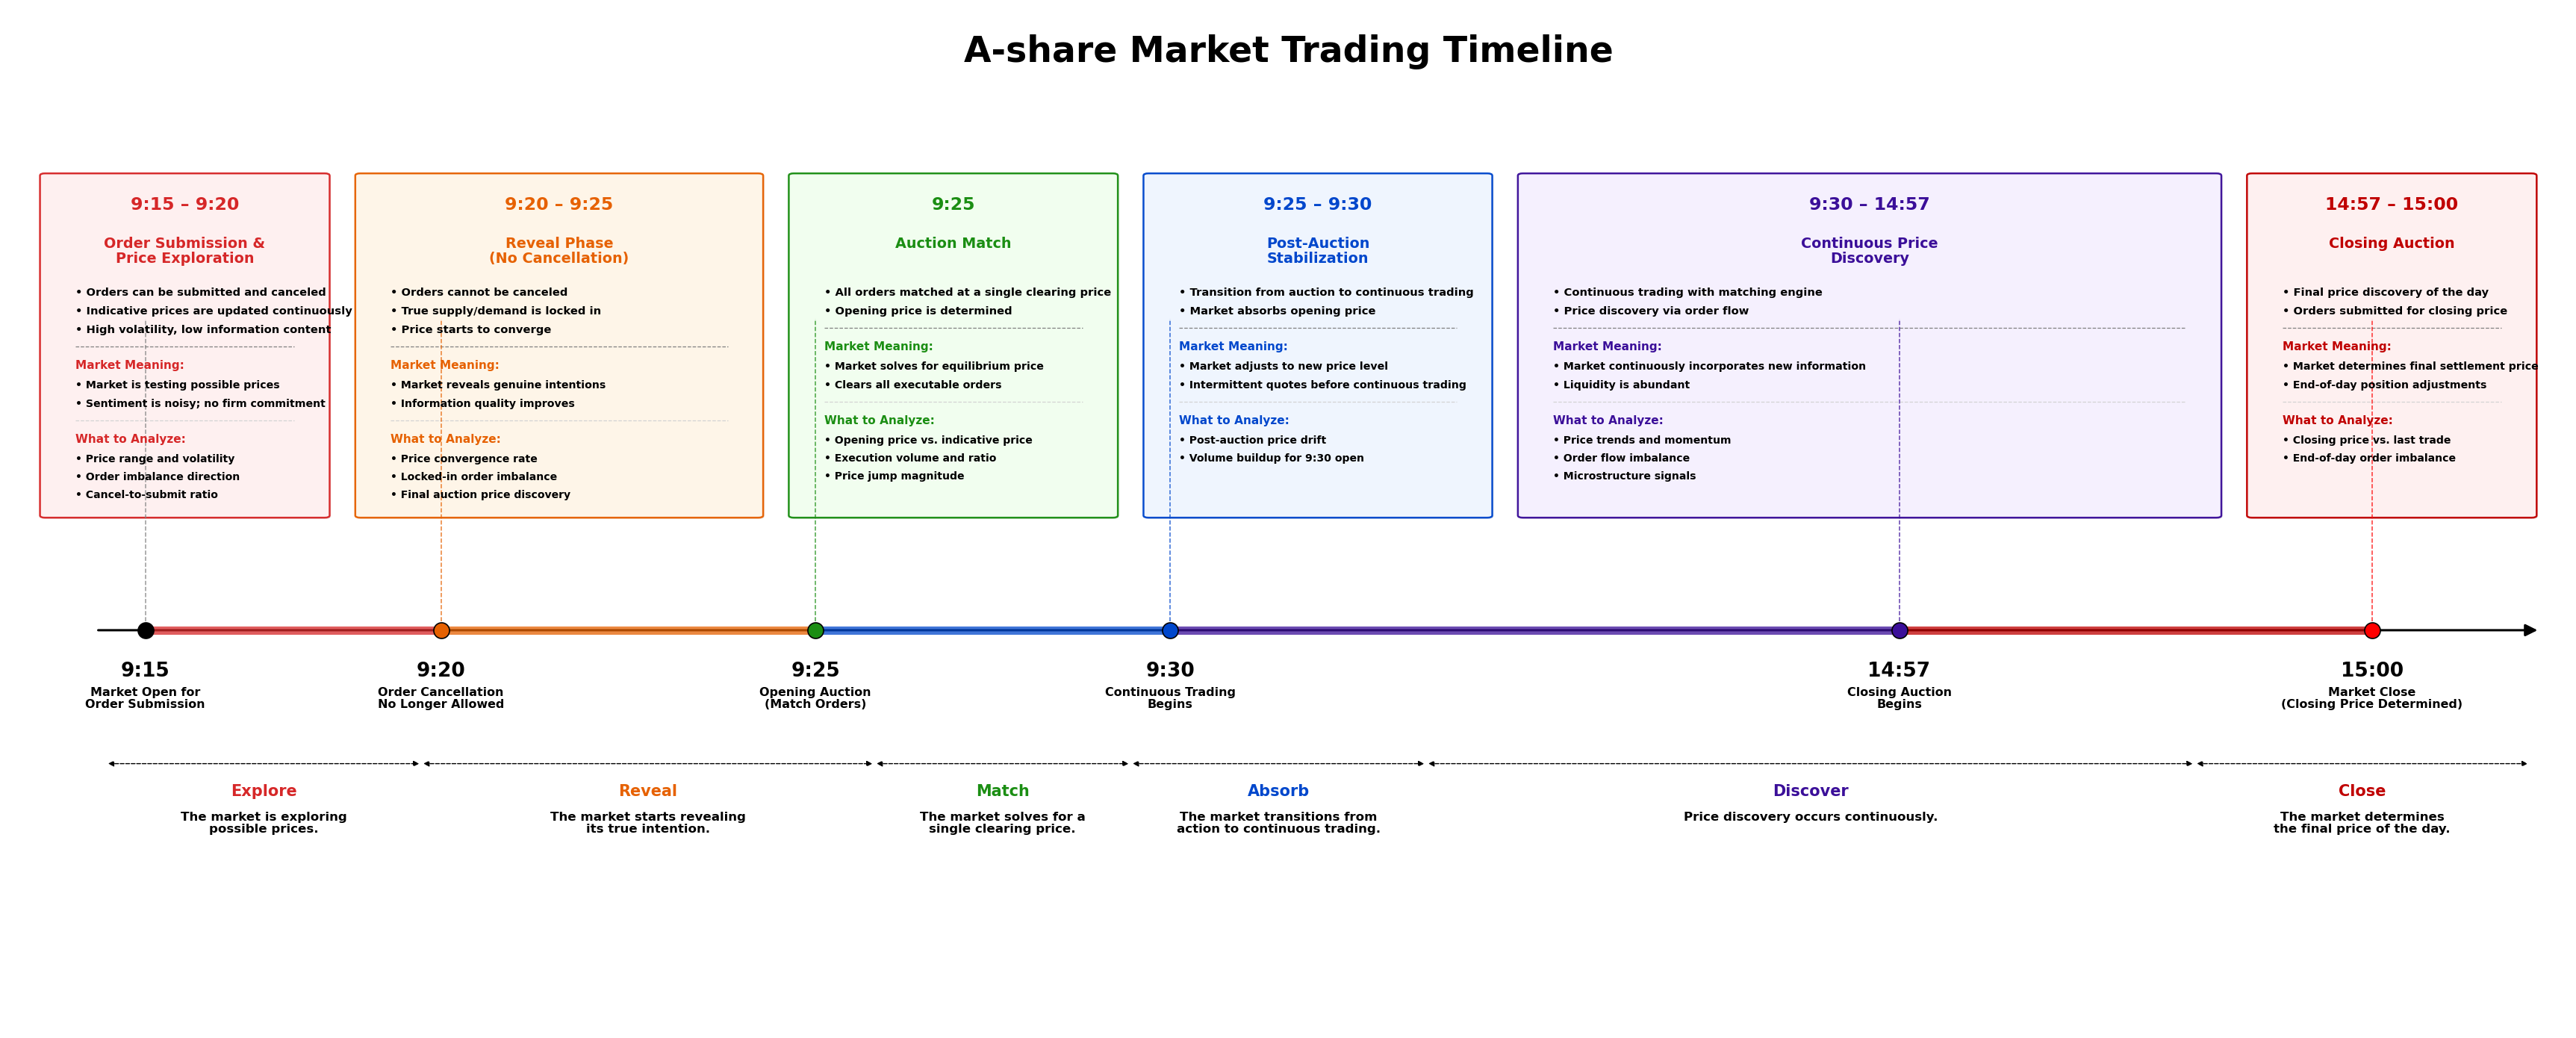

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

# ================== Y轴范围扩大 ==================
fig, ax = plt.subplots(figsize=(35, 14))
ax.set_xlim(0, 130)
ax.set_ylim(0, 115)  # 从100扩大到115，给底部更多空间
ax.axis("off")

# ---------- Title ----------
ax.text(
    65, 110,   # 从96下移到110
    "A-share Market Trading Timeline",
    ha="center", va="center",
    fontsize=34,  
    fontweight="bold"
)

# ---------- Colors ----------
colors = {
    "explore": "#d62728",
    "reveal": "#e66101",
    "match": "#1b8e13",
    "absorb": "#0047cc",
    "discover": "#3b0f99",
    "close": "#c00000",
}

light_colors = {
    "explore": "#fff1f1",
    "reveal": "#fff6e8",
    "match": "#f2fff0",
    "absorb": "#f0f6ff",
    "discover": "#f6f1ff",
    "close": "#fff1f1",
}

# ================== 时间轴整体下移 ==================
y_line = 45          # 时间轴（原来85 → 60，下移25）
card_y = 80          # 卡片到时间轴的连线终点
y_arrow = 30         # 底部功能描述（原来17 → 30）

# 卡片整体下移（原来 y 约 28，现在 +30）
card_base_y = 82     # 卡片底部Y坐标

def draw_card(card):
    # 卡片Y坐标整体下移30个单位
    x, y, w, h = card["x"], card["y"] + 30, card["w"], card["h"]
    key = card["key"]
    c = colors[key]

    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.35,rounding_size=0.25",
        linewidth=1.8,
        edgecolor=c,
        facecolor=light_colors[key],
        alpha=0.97
    )
    box.set_path_effects([
        pe.SimplePatchShadow(offset=(1.2, -1.2), alpha=0.10),
        pe.Normal()
    ])
    ax.add_patch(box)

    cx = x + w / 2
    text_x = x + 1.45

    ax.text(cx, y + h - 2.2, card["time"],
            ha="center", va="top", fontsize=17,
            fontweight="bold", color=c)

    ax.text(cx, y + h - 6.8, card["title"],
            ha="center", va="top", fontsize=13.8,
            fontweight="bold", color=c, linespacing=1.05)

    yy = y + h - 12.5

    for b in card["bullets"]:
        ax.text(text_x, yy, "• " + b,
                ha="left", va="top", fontsize=10.6,
                fontweight="bold", color="black", linespacing=1.05)
        yy -= 3.0 if "\n" in b else 2.1

    ax.plot([x + 1.45, x + w - 1.45], [yy - 0.35, yy - 0.35],
            linestyle="--", color="gray", linewidth=0.9)
    yy -= 1.8

    ax.text(text_x, yy, "Market Meaning:",
            ha="left", va="top", fontsize=11,
            fontweight="bold", color=c)
    yy -= 2.3

    for b in card["meaning"]:
        ax.text(text_x, yy, "• " + b,
                ha="left", va="top", fontsize=10.2,
                fontweight="bold", color="black", linespacing=1.05)
        yy -= 3.0 if "\n" in b else 2.1

    ax.plot([x + 1.45, x + w - 1.45], [yy - 0.35, yy - 0.35],
            linestyle="--", color="lightgray", linewidth=0.9)
    yy -= 1.8

    ax.text(text_x, yy, "What to Analyze:",
            ha="left", va="top", fontsize=11,
            fontweight="bold", color=c)
    yy -= 2.3

    for b in card["analyze"]:
        ax.text(text_x, yy, "• " + b,
                ha="left", va="top", fontsize=10.1,
                fontweight="bold", color="black")
        yy -= 2.0

# ================== 卡片数据（Y坐标整体+30） ==================
cards = [
    {
        "x": 2, "y": 28, "w": 14, "h": 38,
        "key": "explore",
        "time": "9:15 – 9:20",
        "title": "Order Submission &\nPrice Exploration",
        "bullets": [
            "Orders can be submitted and canceled",
            "Indicative prices are updated continuously",
            "High volatility, low information content"
        ],
        "meaning": [
            "Market is testing possible prices",
            "Sentiment is noisy; no firm commitment"
        ],
        "analyze": [
            "Price range and volatility",
            "Order imbalance direction",
            "Cancel-to-submit ratio"
        ]
    },
    {
        "x": 18, "y": 28, "w": 20, "h": 38,
        "key": "reveal",
        "time": "9:20 – 9:25",
        "title": "Reveal Phase\n(No Cancellation)",
        "bullets": [
            "Orders cannot be canceled",
            "True supply/demand is locked in",
            "Price starts to converge"
        ],
        "meaning": [
            "Market reveals genuine intentions",
            "Information quality improves"
        ],
        "analyze": [
            "Price convergence rate",
            "Locked-in order imbalance",
            "Final auction price discovery"
        ]
    },
    {
        "x": 40, "y": 28, "w": 16, "h": 38,
        "key": "match",
        "time": "9:25",
        "title": "Auction Match",
        "bullets": [
            "All orders matched at a single clearing price",
            "Opening price is determined"
        ],
        "meaning": [
            "Market solves for equilibrium price",
            "Clears all executable orders"
        ],
        "analyze": [
            "Opening price vs. indicative price",
            "Execution volume and ratio",
            "Price jump magnitude"
        ]
    },
    {
        "x": 58, "y": 28, "w": 17, "h": 38,
        "key": "absorb",
        "time": "9:25 – 9:30",
        "title": "Post-Auction\nStabilization",
        "bullets": [
            "Transition from auction to continuous trading",
            "Market absorbs opening price"
        ],
        "meaning": [
            "Market adjusts to new price level",
            "Intermittent quotes before continuous trading"
        ],
        "analyze": [
            "Post-auction price drift",
            "Volume buildup for 9:30 open"
        ]
    },
    {
        "x": 77, "y": 28, "w": 35, "h": 38,
        "key": "discover",
        "time": "9:30 – 14:57",
        "title": "Continuous Price\nDiscovery",
        "bullets": [
            "Continuous trading with matching engine",
            "Price discovery via order flow"
        ],
        "meaning": [
            "Market continuously incorporates new information",
            "Liquidity is abundant"
        ],
        "analyze": [
            "Price trends and momentum",
            "Order flow imbalance",
            "Microstructure signals"
        ]
    },
    {
        "x": 114, "y": 28, "w": 14, "h": 38,
        "key": "close",
        "time": "14:57 – 15:00",
        "title": "Closing Auction",
        "bullets": [
            "Final price discovery of the day",
            "Orders submitted for closing price"
        ],
        "meaning": [
            "Market determines final settlement price",
            "End-of-day position adjustments"
        ],
        "analyze": [
            "Closing price vs. last trade",
            "End-of-day order imbalance"
        ]
    }
]

for card in cards:
    draw_card(card)

# ================== 节点 ==================
pos = {"9:15": 7, "9:20": 22, "9:25": 41, "9:30": 59, "14:57": 96, "15:00": 120}

node_info = [
    ("9:15", "black", "Market Open for\nOrder Submission"),
    ("9:20", colors["reveal"], "Order Cancellation\nNo Longer Allowed"),
    ("9:25", colors["match"], "Opening Auction\n(Match Orders)"),
    ("9:30", colors["absorb"], "Continuous Trading\nBegins"),
    ("14:57", colors["discover"], "Closing Auction\nBegins"),
    ("15:00", "red", "Market Close\n(Closing Price Determined)"),
]

for t, c, label in node_info:
    x = pos[t]

    ax.scatter(x, y_line, s=230, color=c, edgecolor="black", linewidth=1.2, zorder=5)

    ax.plot([x, x], [y_line + 1.0, card_y],
            linestyle="--", linewidth=1.1,
            color=c if c != "black" else "gray", alpha=0.8)

    ax.text(x, y_line - 3.5, t,
            ha="center", va="top", fontsize=19,  
            fontweight="bold", color="black")

    ax.text(x, y_line - 6.4, label,
            ha="center", va="top", fontsize=11.5, 
            fontweight="bold", color="black", linespacing=1.05)

# ================== Main timeline ==================
segments = [
    ("9:15", "9:20", "explore"),
    ("9:20", "9:25", "reveal"),
    ("9:25", "9:30", "absorb"),
    ("9:30", "14:57", "discover"),
    ("14:57", "15:00", "close"),
]

ax.add_patch(FancyArrowPatch(
    (pos["9:15"] - 2.5, y_line), (128.5, y_line),
    arrowstyle="-|>", mutation_scale=24,
    linewidth=2.2, color="black"
))

for start, end, key in segments:
    ax.plot(
        [pos[start], pos[end]],
        [y_line, y_line],
        color=colors[key],
        linewidth=8,
        solid_capstyle="round",
        alpha=0.75
    )

# ================== 底部功能区域 ==================
function_ranges = [
    (5, 21, "Explore", "The market is exploring\npossible prices.", "explore"),
    (21, 44, "Reveal", "The market starts revealing\nits true intention.", "reveal"),
    (44, 57, "Match", "The market solves for a\nsingle clearing price.", "match"),
    (57, 72, "Absorb", "The market transitions from\naction to continuous trading.", "absorb"),
    (72, 111, "Discover", "Price discovery occurs continuously.", "discover"),
    (111, 128, "Close", "The market determines\nthe final price of the day.", "close"),
]

for x1, x2, title, desc, key in function_ranges:
    ax.add_patch(FancyArrowPatch(
        (x1, y_arrow), (x2, y_arrow),
        arrowstyle="<|-|>",
        mutation_scale=11,
        linewidth=1.0,
        linestyle="--",
        color="black"
    ))

    ax.text((x1 + x2) / 2, y_arrow - 2.3, title,
            ha="center", va="top", fontsize=15, 
            fontweight="bold", color=colors[key])

    ax.text((x1 + x2) / 2, y_arrow - 5.4, desc,
            ha="center", va="top", fontsize=12, 
            fontweight="bold", color="black", linespacing=1.05)

plt.tight_layout()
plt.show()

| 时间段       | 含义              | 行为                 |
| --------- | --------------- | ------------------ |
| 9:15–9:20 | early auction   | 撤单+试探报价            |
| 9:20–9:25 | locked phase    | 不可撤单 + 意愿聚集        |
| 9:24–9:25 | pre-close build | order imbalance 形成 |
| 9:25      | match           | auction price 形成   |
| 9:25–9:30 | stabilization   | 撮合后微调              |

# 3. Exploratory Data Analysis

## 3.1 Shenzhen Exchange (Snapshot-based)

### 3.1.1 Case Study
#### 样例股票集合竞价价格变化图
通过000009.SZ 20260311-20260410为期一个月的qtick数据来看集合竞价价格变化图

In [11]:
auction = raw[
    (raw["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (raw["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

# 数值字段清洗
price_cols = ["bp0", "ap0", "new_price", "pre_close", "open"]

for col in price_cols:
    if col in auction.columns:
        auction[col] = pd.to_numeric(auction[col], errors="coerce")

# qtick 盘口参考价格：不要依赖 new_price
auction["mid_price"] = (auction["bp0"] + auction["ap0"]) / 2
auction.loc[auction["mid_price"] <= 0, "mid_price"] = np.nan

# 有效成交价，仅用于散点
auction["trade_price"] = auction["new_price"]
auction.loc[auction["trade_price"] <= 0, "trade_price"] = np.nan

# 相对昨收涨跌幅
auction.loc[auction["pre_close"] <= 0, "pre_close"] = np.nan
auction["auction_ret"] = auction["mid_price"] / auction["pre_close"] - 1

print("Trading days:", auction["date"].nunique())
print("Rows:", len(auction))

Trading days: 22
Rows: 871


In [12]:
# 选有效 mid_price 最多的一天作为样例日
day_counts = auction.groupby("date")["mid_price"].count().sort_values(ascending=False)
example_day = day_counts.index[0]

one_day = auction[auction["date"] == example_day].copy()

print("Example day:", example_day.date())
print("Valid mid price ticks:", one_day["mid_price"].notna().sum())
print("Valid trade ticks:", one_day["trade_price"].notna().sum())

Example day: 2026-03-16
Valid mid price ticks: 65
Valid trade ticks: 2


#### 3.1.1.1 单日价格变化

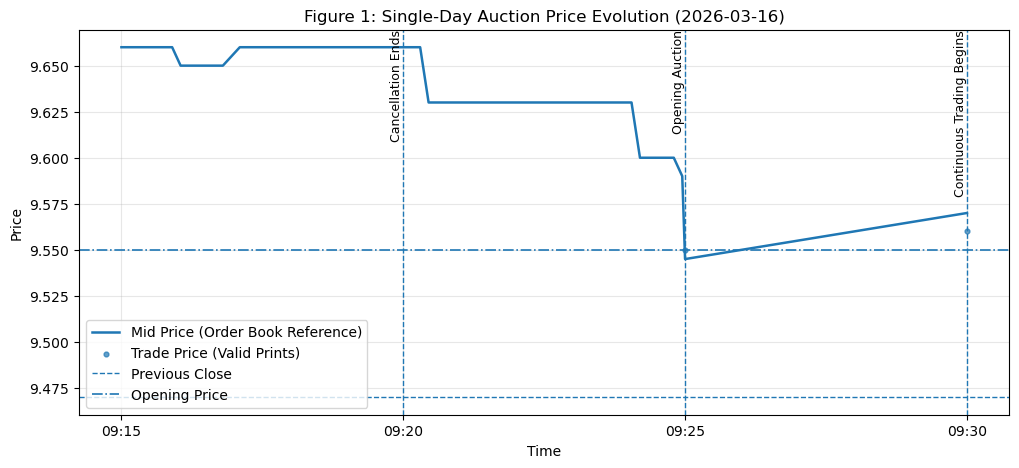

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    one_day["datetime"],
    one_day["mid_price"],
    label="Mid Price (Order Book Reference)",
    linewidth=1.8
)

ax.scatter(
    one_day["datetime"],
    one_day["trade_price"],
    s=12,
    alpha=0.7,
    label="Trade Price (Valid Prints)"
)

# 昨收与开盘价
prev_close = one_day["pre_close"].dropna().iloc[0] if one_day["pre_close"].notna().any() else None
open_price = one_day["open"].dropna().iloc[-1] if "open" in one_day.columns and one_day["open"].notna().any() else None

if prev_close is not None:
    ax.axhline(prev_close, linestyle="--", linewidth=1, label="Previous Close")

if open_price is not None and open_price > 0:
    ax.axhline(open_price, linestyle="-.", linewidth=1.2, label="Opening Price")

# 关键时间节点
for t, label in [
    ("09:20:00", "Cancellation Ends"),
    ("09:25:00", "Opening Auction"),
    ("09:30:00", "Continuous Trading Begins")
]:
    x = pd.Timestamp.combine(example_day.date(), pd.to_datetime(t).time())
    ax.axvline(x, linestyle="--", linewidth=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title(f"Figure 1: Single-Day Auction Price Evolution ({example_day.date()})")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

- 9：15-9：20：价格在9.65，9.66附近震荡，说明买卖双已经有共识，价格并没有乱跳
- 9：20-9：25：价格开始下降，从9.63到9.60到9.59，说明市场真是卖压出现，因为不能撤单
- 9：25时：价格突然掉到9.545，且opening price ≈ previous close，可暂时说明前面的盘口价格可能偏乐观，在真正order成交后, equilibrium price lower.

#### 3.1.1.2 一个月平均路径Average Price Path

In [14]:
# 把每天对齐到统一 10 秒时间网格
def align_one_day(g, freq="10s"):
    current_date = g["date"].iloc[0]
    
    start = pd.Timestamp.combine(current_date.date(), pd.to_datetime("09:15:00").time())
    end = pd.Timestamp.combine(current_date.date(), pd.to_datetime("09:30:00").time())
    grid = pd.date_range(start=start, end=end, freq=freq)
    
    temp = g.sort_values("datetime").set_index("datetime")
    
    aligned = temp[["auction_ret"]].reindex(grid, method="ffill")
    aligned["auction_ret"] = aligned["auction_ret"].bfill()
    
    aligned["date"] = current_date
    aligned["clock_time"] = aligned.index.strftime("%H:%M:%S")
    
    return aligned.reset_index(drop=True)

aligned_list = []

for d, g in auction.groupby("date"):
    if g["auction_ret"].notna().sum() >= 5:
        aligned_list.append(align_one_day(g, freq="10s"))

aligned = pd.concat(aligned_list, ignore_index=True)

ret_matrix = aligned.pivot(
    index="clock_time",
    columns="date",
    values="auction_ret"
).sort_index()

mean_path = ret_matrix.mean(axis=1)
std_path = ret_matrix.std(axis=1)

plot_times = pd.to_datetime(ret_matrix.index, format="%H:%M:%S")

print("Aligned days:", ret_matrix.shape[1])
print("Time points:", ret_matrix.shape[0])

Aligned days: 22
Time points: 91


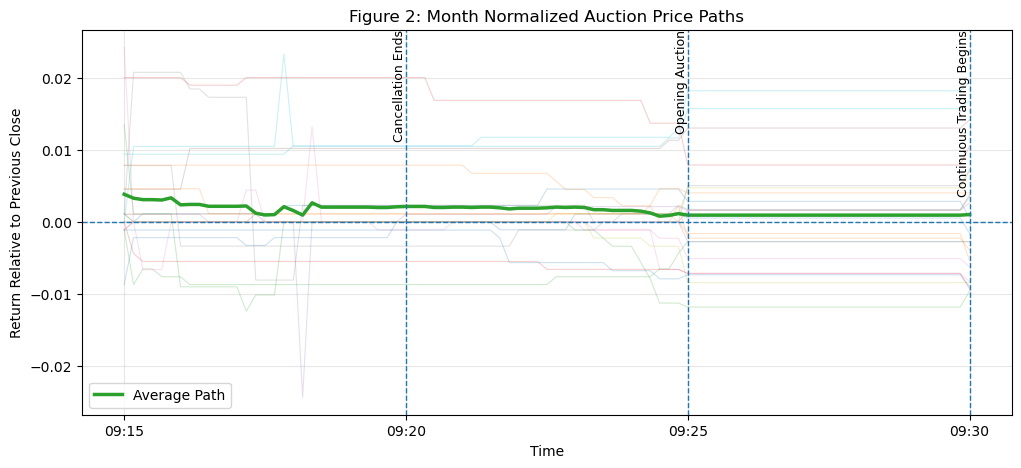

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

# 每天一条浅线
for col in ret_matrix.columns:
    ax.plot(
        plot_times,
        ret_matrix[col],
        alpha=0.22,
        linewidth=0.8
    )

# 平均路径
ax.plot(
    plot_times,
    mean_path,
    linewidth=2.5,
    label="Average Path"
)

ax.axhline(0, linestyle="--", linewidth=1)

for t, label in [
    ("09:20:00", "Cancellation Ends"),
    ("09:25:00", "Opening Auction"),
    ("09:30:00", "Continuous Trading Begins")
]:
    x = pd.to_datetime(t, format="%H:%M:%S")
    ax.axvline(x, linestyle="--", linewidth=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title("Figure 2: Month Normalized Auction Price Paths")
ax.set_xlabel("Time")
ax.set_ylabel("Return Relative to Previous Close")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

这张表将一个月交易日的数据整合在一起并平均路径，发现仍是竞价初期偏乐观后市场逐渐修正，符合case抽样的价格变化趋势。

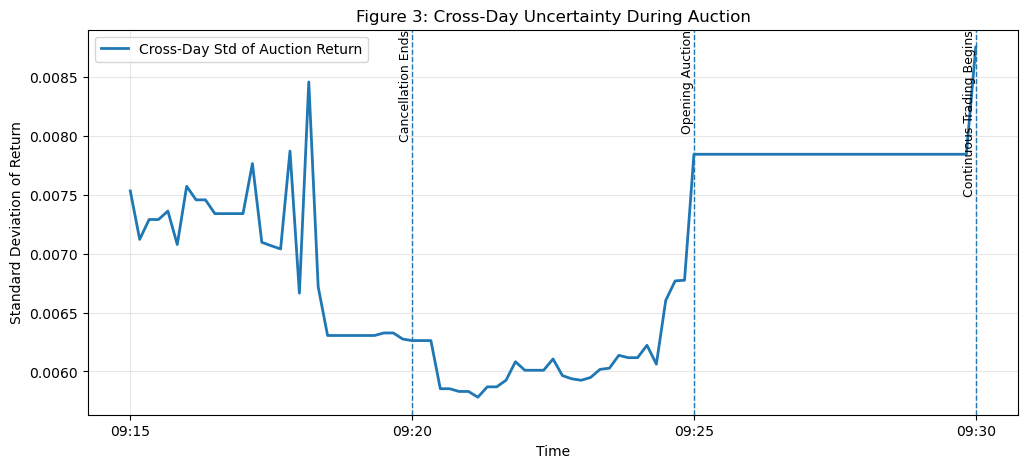

In [16]:
# 每个时刻的跨天标准差
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_times,
    std_path,
    linewidth=2,
    label="Cross-Day Std of Auction Return"
)

for t, label in [
    ("09:20:00", "Cancellation Ends"),
    ("09:25:00", "Opening Auction"),
    ("09:30:00", "Continuous Trading Begins")
]:
    x = pd.to_datetime(t, format="%H:%M:%S")
    ax.axvline(x, linestyle="--", linewidth=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title("Figure 3: Cross-Day Uncertainty During Auction")
ax.set_xlabel("Time")
ax.set_ylabel("Standard Deviation of Return")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

为了比较不同交易日集合竞价阶段价格信号的稳定程度，首先对所有交易日进行了时间对齐和价格标准化。
1. 价格标准化：对于每个交易日，定义 auction_return = mid_price/pre_close-1. 将盘口参考价格转换为相对昨收的涨跌幅，这样不同价格水平的股票可以放到同一尺度进行比较。
2. 时间对齐：由于qtick不是严格固定时间间隔产生，因此每天的快照时间点不同且有些时间点存在缺失。因此，我将所有交易日时间统一10s一取样
3. 计算标准差：通过计算standard deviation, 了解同一时刻，不同交易日之间价格信号的离散程度

第一阶段9：15-9：20：std比较高，再0.0072到0.0085附近摆动，说明不同交易日价格路径差距较大，市场预期尚未稳定，且价格信号具有较强noise
第二阶段9：20-9：25：std明显下降到0.0058附近，说明由于不能cancel order，市场价格开始收敛，不同交易日之间的价格分歧减弱且信息质量提高
第三阶段9：25后：std重新上升，可能原因有：开盘价存在跨日差异，高开于低开导致收益率std扩大，也有数据对齐方法带来的影响

#### 3.1.1.3 委托量变化图
通过000009.SZ 20260311-20260410的qorder数据看委托量变化图

In [17]:
qorder = s.run("""
select *
from loadTable("dfs://quota","qorder")
where code = "000009.SZ"
and date >= 2026.03.11
and date <= 2026.04.10
""")

In [18]:
# 1. Basic Cleaning

order = qorder.copy()

order["date"] = pd.to_datetime(order["date"], errors="coerce")
order["time"] = pd.to_datetime(order["time"], errors="coerce")

order = order.dropna(subset=["date", "time"])

order["datetime"] = order.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

order = order.sort_values(["date", "datetime"]).reset_index(drop=True)

# opening auction window
order = order[
    (order["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (order["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

order["order_volume"] = pd.to_numeric(order["order_volume"], errors="coerce").fillna(0)

# classify buy/sell
# 根据你打印结果：bs_flag = 1 是 buy, 2 是 sell
order["side"] = np.where(
    order["bs_flag"] == 1,
    "buy",
    np.where(order["bs_flag"] == 2, "sell", "unknown")
)

order = order[order["side"].isin(["buy", "sell"])].copy()

print("Trading days:", order["date"].nunique())
print("Rows:", len(order))
print(order["side"].value_counts())
print(order[["bs_flag", "side", "order_type"]].drop_duplicates())

Trading days: 22
Rows: 20839
side
sell    14130
buy      6709
Name: count, dtype: int64
   bs_flag  side  order_type
0        2  sell           0
2        1   buy           0


In [19]:
# 2. Aggregate to 10-second grid
order["clock_time"] = order["datetime"].dt.floor("10s").dt.strftime("%H:%M:%S")

agg = (
    order
    .groupby(["date", "clock_time", "side"])["order_volume"]
    .sum()
    .reset_index()
)

pivot = agg.pivot_table(
    index=["date", "clock_time"],
    columns="side",
    values="order_volume",
    fill_value=0
).reset_index()

if "buy" not in pivot.columns:
    pivot["buy"] = 0

if "sell" not in pivot.columns:
    pivot["sell"] = 0

pivot["total_order_volume"] = pivot["buy"] + pivot["sell"]

pivot["order_imbalance"] = np.where(
    pivot["total_order_volume"] > 0,
    (pivot["buy"] - pivot["sell"]) / pivot["total_order_volume"],
    np.nan
)

# average across all trading days
month_avg = (
    pivot
    .groupby("clock_time")[["buy", "sell", "total_order_volume", "order_imbalance"]]
    .mean()
    .reset_index()
)

plot_times = pd.to_datetime(month_avg["clock_time"], format="%H:%M:%S")

print("Valid clock points:", len(month_avg))

Valid clock points: 61


In [20]:
def add_auction_markers(ax):
    for t, label in [
        ("09:20:00", "Cancellation Ends"),
        ("09:25:00", "Opening Auction"),
        ("09:30:00", "Continuous Trading Begins")
    ]:
        x = pd.to_datetime(t, format="%H:%M:%S")
        ax.axvline(x, linestyle="--", linewidth=1)
        ax.text(
            x,
            ax.get_ylim()[1],
            label,
            rotation=90,
            va="top",
            ha="right",
            fontsize=9
        )

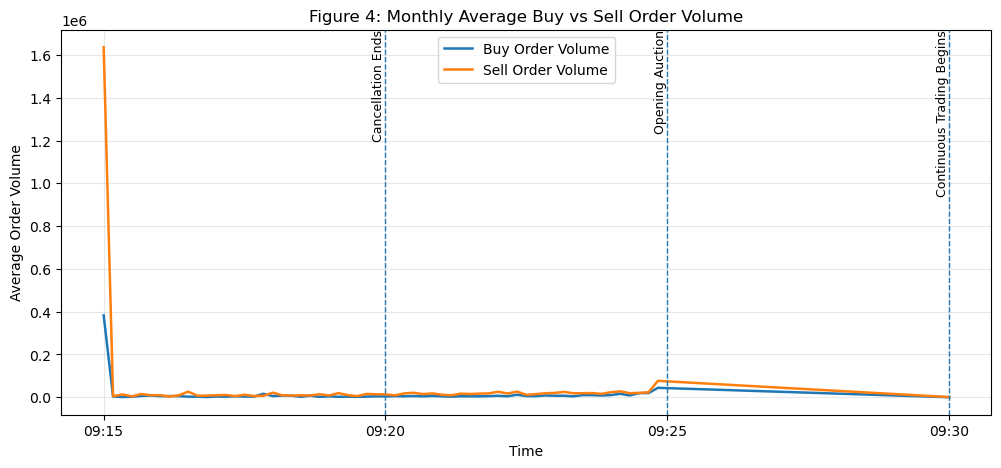

In [21]:
# Figure 4: Monthly Average Buy vs Sell Order Volume
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_times,
    month_avg["buy"],
    label="Buy Order Volume",
    linewidth=1.8
)

ax.plot(
    plot_times,
    month_avg["sell"],
    label="Sell Order Volume",
    linewidth=1.8
)

add_auction_markers(ax)

ax.set_title("Figure 4: Monthly Average Buy vs Sell Order Volume")
ax.set_xlabel("Time")
ax.set_ylabel("Average Order Volume")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

9：15：出现巨大峰值，可能因为集合竞价开始，大量隔夜订单进入，卖单一次性释放且整体股票偏空
9：15后：买卖量都很小，因为是逐笔委托，真正的新增订单没盘口那么连续
9：25-9：25：出现了第二次放量，说明临近开盘，投资者重新调整

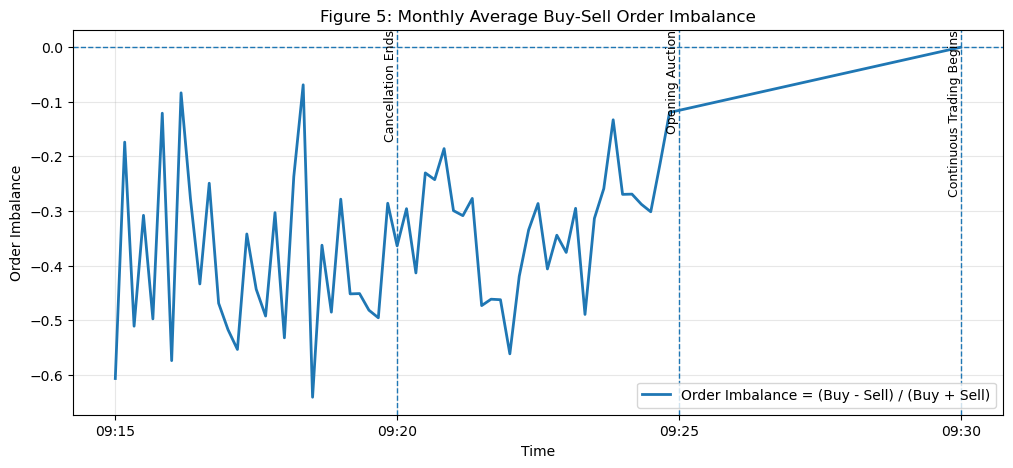

In [22]:
# Figure 5: Monthly Average Buy-Sell Order Imbalance

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_times,
    month_avg["order_imbalance"],
    label="Order Imbalance = (Buy - Sell) / (Buy + Sell)",
    linewidth=2
)

ax.axhline(0, linestyle="--", linewidth=1)

add_auction_markers(ax)

ax.set_title("Figure 5: Monthly Average Buy-Sell Order Imbalance")
ax.set_xlabel("Time")
ax.set_ylabel("Order Imbalance")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

因为全部小于0，说明整个月卖方持续占优。且从9：15-9：20的-0.4到9：24的-0.1，这说明卖压在减弱，买卖开始趋于平衡，与qtick的验证匹配。

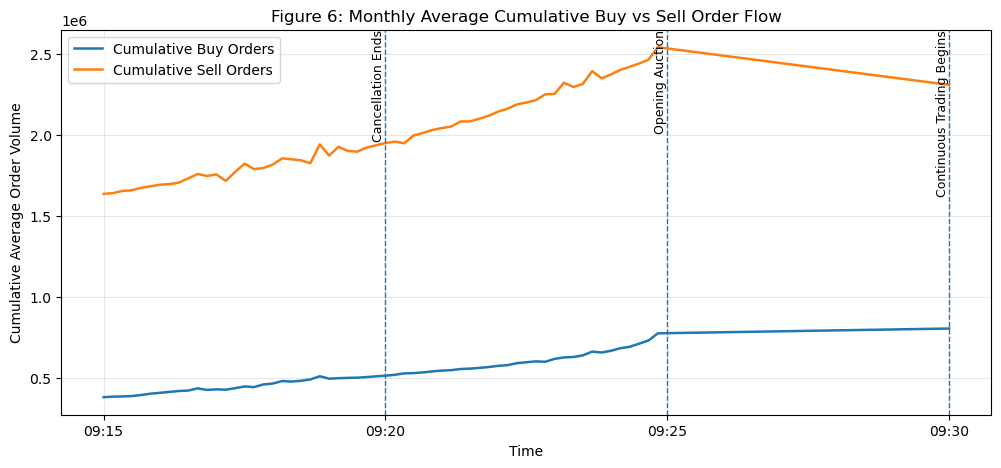

In [23]:
# Figure 6: Monthly Average Cumulative Buy vs Sell Order Flow
pivot = pivot.sort_values(["date", "clock_time"]).copy()

pivot["cum_buy"] = pivot.groupby("date")["buy"].cumsum()
pivot["cum_sell"] = pivot.groupby("date")["sell"].cumsum()
pivot["cum_net"] = pivot["cum_buy"] - pivot["cum_sell"]

cum_avg = (
    pivot
    .groupby("clock_time")[["cum_buy", "cum_sell", "cum_net"]]
    .mean()
    .reset_index()
)

cum_times = pd.to_datetime(cum_avg["clock_time"], format="%H:%M:%S")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    cum_times,
    cum_avg["cum_buy"],
    label="Cumulative Buy Orders",
    linewidth=1.8
)

ax.plot(
    cum_times,
    cum_avg["cum_sell"],
    label="Cumulative Sell Orders",
    linewidth=1.8
)

add_auction_markers(ax)

ax.set_title("Figure 6: Monthly Average Cumulative Buy vs Sell Order Flow")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Average Order Volume")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

这是累计的买卖单，说明整个竞价期间，卖方意愿要明显高于买方。9：25之前，卖单快速增加，这也说明了价格从9.66降到开盘价9.55原因。

Case study展示了一只股票的特征，但这些观察不足以让我们对市场有一定了解。所以，接下来我将基于多只股票分析。

Case study reveals the dynamics of one stock, but it remains unclear whether these observations generalize across the market. Therefore, we extend the analysis to multiple stocks.

### 3.1.2 Cross-Sectional Analysis: Multi-Stock Comparison

#### 3.1.2.1 Auction Return Distribution

由于qtick在9：15-9：25提供信息的只有深交所的股票，这里先运用深交所的股票。

深交所内部大致可以这样分：
- 000 / 001 / 002 / 003 开头：深市主板 main_board
- 300 / 301 开头：创业板 chinext
- 200 开头：深市 B 股，一般先不要分析 exclude

eg. 000001.SZ 平安银行     深市主板
000858.SZ 五粮液       深市主板
002594.SZ 比亚迪       深市主板/原中小板
300750.SZ 宁德时代     创业板
300760.SZ 迈瑞医疗     创业板

In [24]:
import pandas as pd
from src.ddb_client import connect_ddb

s = connect_ddb()

In [25]:
sql = """
select distinct code
from loadTable("dfs://quota","qtick")
where date = 2026.03.11
"""

codes = s.run(sql)

codes.head()

,code
0,000001.SH
1,000015.SH
2,000017.SZ
3,000018.SH
4,000020.SZ


In [26]:
sz_codes = codes[
    codes["code"].str.endswith(".SZ")
].copy()

print(len(sz_codes))

22710


In [27]:
# 股票池如何
def board(code):

    if code.startswith(("000","001","002","003")):
        return "main"

    elif code.startswith(("300","301")):
        return "chinext"

    else:
        return "other"

sz_codes["board"] = sz_codes["code"].apply(board)

sz_codes["board"].value_counts()

board
other      19827
main        1491
chinext     1392
Name: count, dtype: int64

In [28]:
main_pool = sz_codes[sz_codes["board"] == "main"]
chinext_pool = sz_codes[sz_codes["board"] == "chinext"]

main_sample = main_pool.sample(
    n=min(30, len(main_pool)),
    random_state=42
)

chinext_sample = chinext_pool.sample(
    n=min(20, len(chinext_pool)),
    random_state=42
)

stock_pool = pd.concat(
    [main_sample, chinext_sample],
    ignore_index=True
)

sample_codes = stock_pool["code"].tolist()

print("Selected stocks:", len(sample_codes))
print(stock_pool["board"].value_counts())
print(sample_codes[:10])

Selected stocks: 50
board
main       30
chinext    20
Name: count, dtype: int64
['000950.SZ', '000155.SZ', '002713.SZ', '000010.SZ', '002708.SZ', '002015.SZ', '002777.SZ', '001288.SZ', '002292.SZ', '002655.SZ']


In [29]:
codes_str = ",".join(
    [f'"{c}"' for c in sample_codes]
)

sql = f"""
select *
from loadTable("dfs://quota","qtick")
where date >= 2026.03.11
  and date <= 2026.04.10
  and code in ({codes_str})
  and time >= 09:15:00.000
  and time <= 09:30:00.000  
"""

qtick_50 = s.run(sql)

qtick_50.head()

,code,date,time,src,state,bp0,bp1,bp2,bp3,bp4,...,create_date,list_date,expire_date,start_settle_date,end_settle_date,exercise_date,exercise_price,cp_flag,underlying_code,trading_date
0,300768.SZ,2026-03-11,1970-01-01 09:15:00,0,0,18.55,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
1,300768.SZ,2026-03-11,1970-01-01 09:15:09,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
2,300768.SZ,2026-03-11,1970-01-01 09:16:12,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
3,300768.SZ,2026-03-11,1970-01-01 09:17:06,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
4,300768.SZ,2026-03-11,1970-01-01 09:18:09,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0


In [30]:
qtick_50=qtick_50.merge(
    stock_pool[["code", "board"]],
    on="code",
    how="left"
)

In [31]:
qtick_50 = qtick_50.copy()

qtick_50["datetime"] = pd.to_datetime(
    qtick_50["date"].astype(str) + " " + qtick_50["time"].astype(str)
)

qtick_50 = qtick_50.sort_values(["code", "date", "datetime"])

C:\Users\work\AppData\Local\Temp\ipykernel_26584\2587534310.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  qtick_50["datetime"] = pd.to_datetime(


In [32]:
qtick_50_filtered = qtick_50[qtick_50["new_price"] > 0].copy()

price_col = "new_price"
features = []

for (code, date), g in qtick_50_filtered.groupby(["code", "date"]):
    g = g.sort_values("time").copy()
    prices = g[price_col].dropna()
    
    if len(prices) < 2:
        continue

    first_price = prices.iloc[0]
    last_price = prices.iloc[-1]

    feature = {
        "code": code,
        "date": date,
        "n_ticks": len(g),
        "first_price": first_price,
        "last_price": last_price,
        "auction_return": (last_price - first_price) / first_price,
        "price_range": prices.max() - prices.min(),
        "price_volatility": prices.std(),
        "n_price_changes": prices.diff().ne(0).sum(),
        "max_price": prices.max(),
        "min_price": prices.min(),
    }

    if "volume" in g.columns:
        feature["total_volume"] = g["volume"].sum()

    if "amount" in g.columns:
        feature["total_amount"] = g["amount"].sum()

    features.append(feature)

feature_df = pd.DataFrame(features)

feature_df.head()

,code,date,n_ticks,first_price,last_price,auction_return,price_range,price_volatility,n_price_changes,max_price,min_price
0,000010.SZ,2026-03-11,2,4.33,4.35,0.004619,0.02,0.014142,2,4.35,4.33
1,000010.SZ,2026-03-12,2,4.29,4.28,-0.002331,0.01,0.007071,2,4.29,4.28
2,000010.SZ,2026-03-13,2,4.10,4.12,0.004878,0.02,0.014142,2,4.12,4.10
3,000010.SZ,2026-03-16,2,4.49,4.45,-0.008909,0.04,0.028284,2,4.49,4.45
4,000010.SZ,2026-03-17,2,4.75,4.77,0.004211,0.02,0.014142,2,4.77,4.75


In [33]:
def classify_stock(code):
    if code.startswith(("000", "001", "002", "003")):
        return "main_board"
    elif code.startswith(("300", "301")):
        return "chinext"
    else:
        return "other"

feature_df["board"] = feature_df["code"].apply(classify_stock)

feature_df.head()

,code,date,n_ticks,first_price,last_price,auction_return,price_range,price_volatility,n_price_changes,max_price,min_price,board
0,000010.SZ,2026-03-11,2,4.33,4.35,0.004619,0.02,0.014142,2,4.35,4.33,main_board
1,000010.SZ,2026-03-12,2,4.29,4.28,-0.002331,0.01,0.007071,2,4.29,4.28,main_board
2,000010.SZ,2026-03-13,2,4.10,4.12,0.004878,0.02,0.014142,2,4.12,4.10,main_board
3,000010.SZ,2026-03-16,2,4.49,4.45,-0.008909,0.04,0.028284,2,4.49,4.45,main_board
4,000010.SZ,2026-03-17,2,4.75,4.77,0.004211,0.02,0.014142,2,4.77,4.75,main_board


In [34]:
summary = feature_df.groupby("board")[
    ["auction_return", "price_range", "price_volatility", "n_price_changes", "n_ticks"]
].describe()

summary

auction_return                                              \
                    count     mean       std       min       25%  50%   
board                                                                   
chinext             426.0  0.00070  0.006866 -0.033227 -0.000859  0.0   
main_board          658.0  0.00001  0.002997 -0.012903 -0.001300  0.0   

                               price_range            ... n_price_changes  \
                 75%       max       count      mean  ...             75%   
board                                                 ...                   
chinext     0.001894  0.085714       426.0  0.074765  ...             2.0   
main_board  0.001566  0.019791       658.0  0.038678  ...             2.0   

                n_ticks                                     
            max   count mean  std  min  25%  50%  75%  max  
board                                                       
chinext     2.0   426.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0  
main_board  2.0   658.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0  

[2 rows x 40 columns]

In [35]:
stock_summary = feature_df.groupby(["code", "board"]).agg(
    avg_return=("auction_return", "mean"),
    avg_abs_return=("auction_return", lambda x: x.abs().mean()),
    avg_range=("price_range", "mean"),
    avg_volatility=("price_volatility", "mean"),
    avg_price_changes=("n_price_changes", "mean"),
    avg_ticks=("n_ticks", "mean"),
    n_days=("date", "nunique")
).reset_index()

stock_summary = stock_summary.sort_values("avg_volatility", ascending=False)

stock_summary.head(20)

,code,board,avg_return,avg_abs_return,avg_range,avg_volatility,avg_price_changes,avg_ticks,n_days
46,301169.SZ,chinext,0.003499,0.006983,0.361364,0.255523,1.681818,2.0,22
28,002821.SZ,main_board,0.000367,0.001790,0.195000,0.137886,1.954545,2.0,22
12,001225.SZ,main_board,-0.000552,0.002671,0.131364,0.092888,1.818182,2.0,22
45,301080.SZ,chinext,-0.001239,0.002874,0.130000,0.091924,1.863636,2.0,22
43,300878.SZ,chinext,-0.000480,0.004612,0.130000,0.091924,1.666667,2.0,21
39,300606.SZ,chinext,-0.000089,0.003133,0.114091,0.080674,1.909091,2.0,22
49,301508.SZ,chinext,0.000433,0.003385,0.100909,0.071354,1.909091,2.0,22
48,301269.SZ,chinext,0.000351,0.001111,0.095000,0.067175,1.909091,2.0,22
41,300660.SZ,chinext,0.001449,0.001916,0.082273,0.058176,1.863636,2.0,22
44,300923.SZ,chinext,-0.000904,0.002896,0.079091,0.055926,1.909091,2.0,22


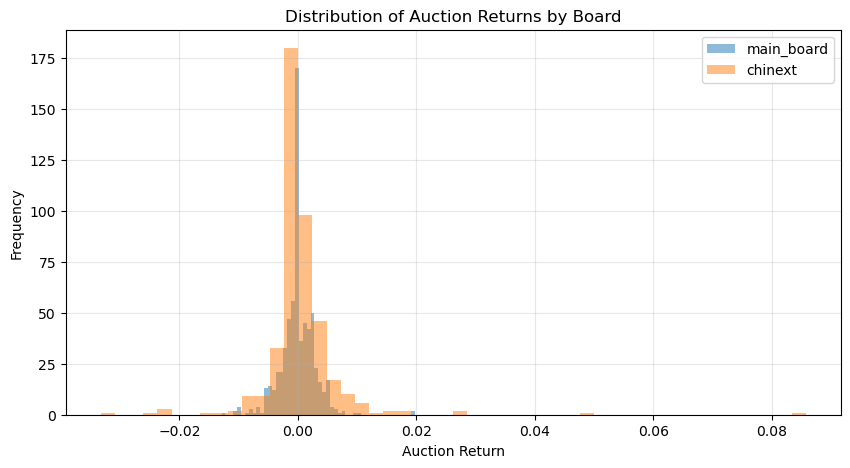

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for board in feature_df["board"].unique():
    data = feature_df.loc[feature_df["board"] == board, "auction_return"].dropna()
    plt.hist(data, bins=50, alpha=0.5, label=board)

plt.title("Distribution of Auction Returns by Board")
plt.xlabel("Auction Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

发现：创业板收益分布更分散，主板更集中。这意味着在集合竞价阶段，创业板的定价效率可能更低，提供了更大alpha挖掘空间，同时伴随更高风险

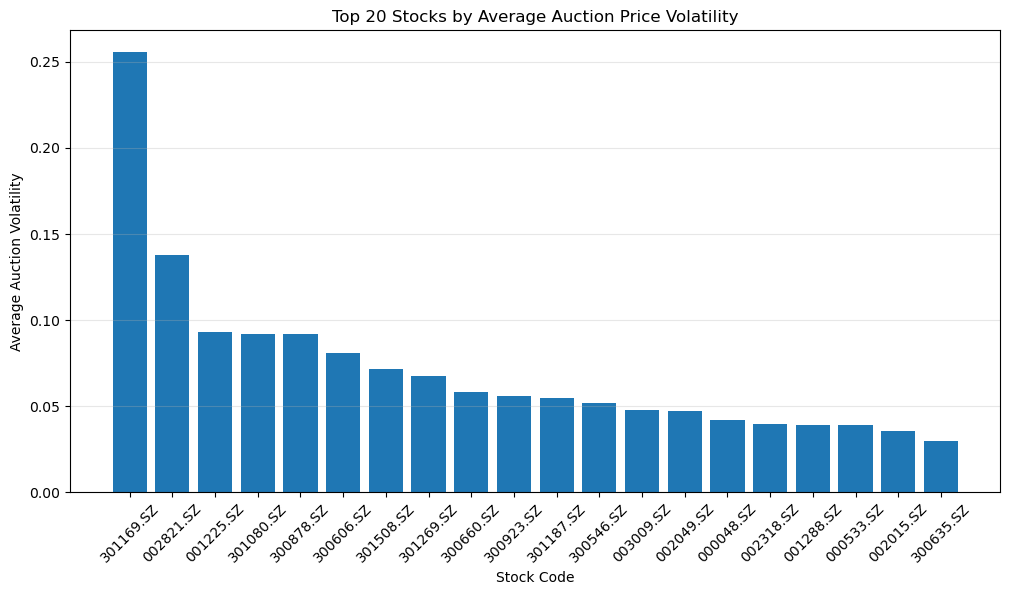

In [37]:
top20 = stock_summary.head(20).copy()

plt.figure(figsize=(12, 6))
plt.bar(top20["code"], top20["avg_volatility"])

plt.title("Top 20 Stocks by Average Auction Price Volatility")
plt.xlabel("Stock Code")
plt.ylabel("Average Auction Volatility")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

#### 3.1.2.2 Price Discovery Characteristics

In [38]:
corr_cols = [
    "auction_return",
    "price_range",
    "price_volatility",
    "n_price_changes",
    "n_ticks"
]

if "total_volume" in feature_df.columns:
    corr_cols.append("total_volume")

corr_matrix = feature_df[corr_cols].corr()

corr_matrix

,auction_return,price_range,price_volatility,n_price_changes,n_ticks
auction_return,1.000000,0.148759,0.148759,0.031553,NaN
price_range,0.148759,1.000000,1.000000,0.238438,NaN
price_volatility,0.148759,1.000000,1.000000,0.238438,NaN
n_price_changes,0.031553,0.238438,0.238438,1.000000,NaN
n_ticks,NaN,NaN,NaN,NaN,NaN


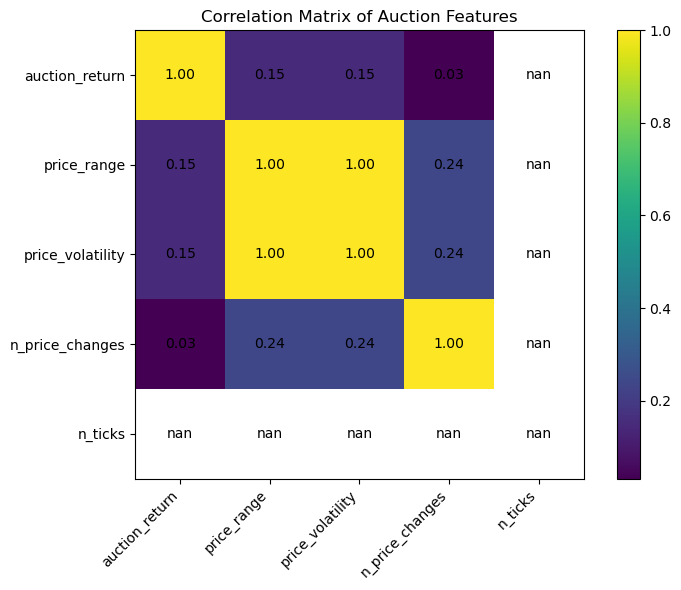

In [39]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Correlation Matrix of Auction Features")

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

价格区间（price_range）与价格波动率（price_volatility）完全相关（ρ = 1.00）
→ 两者度量同一维度，后续分析中可以选择其中一个使用，避免多重共线性。

价格变动次数（n_price_changes）与价格波动幅度呈弱正相关（ρ = 0.24）
→ 价格"动得多"不等于"动得大"，这两个指标提供了互补信息。

集合竞价收益率（auction_return）与所有波动类特征均无显著相关性（|ρ| ≤ 0.15）
→ 核心启示：集合竞价的方向（涨/跌）与价格发现的"激烈程度"是独立的市场信号。前者反映订单流的净方向，后者反映多空分歧程度。这一发现支持将"方向信号"和"分歧信号"作为两个独立的因子用于开盘策略构建。

n_ticks 因样本中所有交易日均为 2 个价格点而无法计算相关性
→ 当前数据粒度下，该指标不提供增量信息，建议在后续分析中排除

In [40]:
# =========================
# 1. Clean qtick_50
# =========================

df = qtick_50.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["time"] = pd.to_datetime(df["time"], errors="coerce")

df = df.dropna(subset=["date", "time"])

df["datetime"] = df.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

df = df.sort_values(["code", "date", "datetime"]).reset_index(drop=True)

# auction window
df = df[
    (df["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (df["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

# numeric columns
for col in ["bp0", "ap0", "new_price", "pre_close", "open", "volume", "amount"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# use order-book reference price, not only traded price
df["mid_price"] = (df["bp0"] + df["ap0"]) / 2
df.loc[df["mid_price"] <= 0, "mid_price"] = np.nan

# fallback: if mid_price unavailable, use bp0
df["ref_price"] = df["mid_price"]
df.loc[df["ref_price"].isna(), "ref_price"] = df["bp0"]

df = df[df["ref_price"].notna()].copy()


# =========================
# 2. Trade volume increment
# =========================
# qtick volume is often cumulative, so use diff within each stock-day

if "volume" in df.columns:
    df["volume_diff"] = (
        df.groupby(["code", "date"])["volume"]
        .diff()
    )

    # first tick of the day: use current volume only if positive
    df["volume_diff"] = df["volume_diff"].fillna(df["volume"])

    # remove abnormal negative diff
    df.loc[df["volume_diff"] < 0, "volume_diff"] = 0
else:
    df["volume_diff"] = np.nan


# =========================
# 3. Feature function
# =========================

def count_turning_points(price_series):
    """
    Count how many times the price direction changes.
    Example: up -> down or down -> up.
    This captures intraday auction '波动次数 / 来回震荡次数'.
    """
    p = price_series.dropna()

    if len(p) < 3:
        return np.nan

    diff = p.diff().dropna()
    diff = diff[diff != 0]

    if len(diff) < 2:
        return 0

    direction = np.sign(diff)
    turns = (direction != direction.shift()).sum() - 1

    return max(turns, 0)


def classify_trend(ret, turns):
    """
    Label auction trend based on overall return and number of reversals.
    """
    if pd.isna(ret):
        return "unknown"

    if abs(ret) < 0.001:
        base = "flat"
    elif ret > 0:
        base = "up"
    else:
        base = "down"

    if pd.isna(turns):
        return base

    if turns >= 4:
        return base + "_volatile"
    elif turns >= 2:
        return base + "_with_reversal"
    else:
        return base + "_smooth"


features = []

for (code, date), g in df.groupby(["code", "date"]):
    g = g.sort_values("datetime").copy()
    p = g["ref_price"].dropna()

    if len(p) < 2:
        continue

    first_price = p.iloc[0]
    last_price = p.iloc[-1]
    max_price = p.max()
    min_price = p.min()

    auction_return = last_price / first_price - 1

    up_move = max_price / first_price - 1
    down_move = min_price / first_price - 1
    price_range_pct = (max_price - min_price) / first_price

    n_price_changes = p.diff().dropna().ne(0).sum()    
    n_turns = count_turning_points(p)

    # last minute: 09:29:00 - 09:30:00
    last_minute = g[
        (g["datetime"].dt.time >= pd.to_datetime("09:29:00").time()) &
        (g["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
    ]

    total_vol = g["volume_diff"].sum()
    last_minute_vol = last_minute["volume_diff"].sum()

    last_minute_share = (
        last_minute_vol / total_vol
        if total_vol > 0
        else np.nan
    )

    feature = {
        "code": code,
        "date": date,
        "board": g["board"].iloc[0] if "board" in g.columns else None,

        "first_price": first_price,
        "last_price": last_price,
        "auction_return": auction_return,

        "up_move": up_move,
        "down_move": down_move,
        "price_range_pct": price_range_pct,

        "price_volatility": p.pct_change().std(),
        "n_price_changes": n_price_changes,
        "n_turns": n_turns,

        "total_volume": total_vol,
        "last_minute_volume": last_minute_vol,
        "last_minute_volume_share": last_minute_share,

        "n_ticks": len(g)
    }

    feature["trend_label"] = classify_trend(
        feature["auction_return"],
        feature["n_turns"]
    )

    features.append(feature)

feature_50 = pd.DataFrame(features)

feature_50.head()

C:\Users\work\AppData\Local\Temp\ipykernel_26584\2839814072.py:127: RuntimeWarning: divide by zero encountered in scalar divide
  auction_return = last_price / first_price - 1
C:\Users\work\AppData\Local\Temp\ipykernel_26584\2839814072.py:129: RuntimeWarning: divide by zero encountered in scalar divide
  up_move = max_price / first_price - 1
C:\Users\work\AppData\Local\Temp\ipykernel_26584\2839814072.py:130: RuntimeWarning: invalid value encountered in scalar divide
  down_move = min_price / first_price - 1
C:\Users\work\AppData\Local\Temp\ipykernel_26584\2839814072.py:131: RuntimeWarning: divide by zero encountered in scalar divide
  price_range_pct = (max_price - min_price) / first_price


,code,date,board,first_price,last_price,auction_return,up_move,down_move,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume,last_minute_volume_share,n_ticks,trend_label
0,000010.SZ,2026-03-11,main,4.36,4.345,-0.003440,0.002294,-0.016055,0.018349,0.002093,7,2,0.0,0.0,NaN,61,down_with_reversal
1,000010.SZ,2026-03-12,main,4.34,4.275,-0.014977,0.000000,-0.014977,0.014977,0.001244,5,0,0.0,0.0,NaN,33,down_smooth
2,000010.SZ,2026-03-13,main,4.53,4.130,-0.088300,0.000000,-0.103753,0.103753,0.013416,14,7,0.0,0.0,NaN,51,down_volatile
3,000010.SZ,2026-03-16,main,4.98,4.435,-0.109438,0.000000,-0.109438,0.109438,0.006958,15,2,0.0,0.0,NaN,70,down_with_reversal
4,000010.SZ,2026-03-17,main,4.65,4.775,0.026882,0.026882,0.000000,0.026882,0.002274,7,4,0.0,0.0,NaN,70,up_volatile


#### 3.1.2.3 Price Formation Dynamics and Trending Activity

In [41]:
# 0. Copy data
# ============================================================

df = qtick_50.copy()


# ============================================================
# 1. Basic cleaning
# ============================================================

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["time"] = pd.to_datetime(df["time"], errors="coerce")

df = df.dropna(subset=["date", "time"])

df["datetime"] = df.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

df = df.sort_values(["code", "date", "datetime"]).reset_index(drop=True)

# auction window
df = df[
    (df["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (df["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

# numeric columns
num_cols = [
    "bp0", "ap0", "new_price", "pre_close", "open",
    "new_volume", "sum_volume", "new_amount", "sum_amount",
    "new_bid_volume", "new_ask_volume"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# ============================================================
# 2. Build valid reference price
# ============================================================

for col in ["bp0", "ap0", "new_price"]:
    if col in df.columns:
        df.loc[df[col] <= 0, col] = np.nan

# mid price only valid when both bid and ask exist
df["mid_price"] = (df["bp0"] + df["ap0"]) / 2

# preferred price source:
# 1. mid_price
# 2. bp0
# 3. ap0
# 4. new_price
df["ref_price"] = (
    df["mid_price"]
    .fillna(df["bp0"])
    .fillna(df["ap0"])
    .fillna(df["new_price"])
)

df = df[df["ref_price"].notna()].copy()
df = df[df["ref_price"] > 0].copy()


# ============================================================
# 3. Volume cleaning
# ============================================================

for col in ["new_volume", "sum_volume", "new_bid_volume", "new_ask_volume"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        df.loc[df[col] < 0, col] = 0
    else:
        df[col] = 0

# order-flow volume
df["new_orderflow_volume"] = df["new_bid_volume"] + df["new_ask_volume"]

df["tick_imbalance"] = np.where(
    df["new_orderflow_volume"] > 0,
    (df["new_bid_volume"] - df["new_ask_volume"]) / df["new_orderflow_volume"],
    np.nan
)


# ============================================================
# 4. Helper functions
# ============================================================

def count_turning_points(price_series):
    p = price_series.dropna()
    p = p[p > 0]

    if len(p) < 3:
        return np.nan

    diff = p.diff().dropna()
    diff = diff[diff != 0]

    if len(diff) < 2:
        return 0

    direction = np.sign(diff)
    turns = (direction != direction.shift()).sum() - 1

    return max(turns, 0)


def classify_trend(ret, turns):
    if pd.isna(ret):
        return "unknown"

    if abs(ret) < 0.001:
        base = "flat"
    elif ret > 0:
        base = "up"
    else:
        base = "down"

    if pd.isna(turns):
        return base

    if turns >= 4:
        return base + "_volatile"
    elif turns >= 2:
        return base + "_with_reversal"
    else:
        return base + "_smooth"


# ============================================================
# 5. Create stock-day features
# ============================================================

features = []

for (code, date), g in df.groupby(["code", "date"]):
    g = g.sort_values("datetime").copy()

    p = g["ref_price"].dropna()
    p = p[p > 0]

    if len(p) < 2:
        continue

    first_price = p.iloc[0]
    last_price = p.iloc[-1]
    max_price = p.max()
    min_price = p.min()

    if first_price <= 0:
        continue

    auction_return = last_price / first_price - 1
    up_move = max_price / first_price - 1
    down_move = min_price / first_price - 1
    price_range_pct = (max_price - min_price) / first_price

    n_price_changes = p.diff().dropna().ne(0).sum()
    n_turns = count_turning_points(p)

    last_minute = g[
        (g["datetime"].dt.time >= pd.to_datetime("09:29:00").time()) &
        (g["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
    ].copy()

    # =========================
    # Volume features
    # =========================

    total_volume = g["new_volume"].sum()
    last_minute_volume = last_minute["new_volume"].sum()

    last_minute_volume_share = (
        last_minute_volume / total_volume
        if total_volume > 0
        else np.nan
    )

    max_sum_volume = g["sum_volume"].max()

    total_bid_volume = g["new_bid_volume"].sum()
    total_ask_volume = g["new_ask_volume"].sum()
    total_orderflow_volume = total_bid_volume + total_ask_volume

    orderflow_imbalance = (
        (total_bid_volume - total_ask_volume) / total_orderflow_volume
        if total_orderflow_volume > 0
        else np.nan
    )

    bid_volume_ratio = (
        total_bid_volume / total_orderflow_volume
        if total_orderflow_volume > 0
        else np.nan
    )

    ask_volume_ratio = (
        total_ask_volume / total_orderflow_volume
        if total_orderflow_volume > 0
        else np.nan
    )

    last_minute_bid_volume = last_minute["new_bid_volume"].sum()
    last_minute_ask_volume = last_minute["new_ask_volume"].sum()
    last_minute_orderflow = last_minute_bid_volume + last_minute_ask_volume

    last_minute_imbalance = (
        (last_minute_bid_volume - last_minute_ask_volume) / last_minute_orderflow
        if last_minute_orderflow > 0
        else np.nan
    )

    # =========================
    # Price-volume relation
    # =========================

    if total_volume > 0:
        volume_weighted_price = (
            (g["ref_price"] * g["new_volume"]).sum() / total_volume
        )
    else:
        volume_weighted_price = np.nan

    feature = {
        "code": code,
        "date": date,
        "board": g["board"].iloc[0] if "board" in g.columns else None,

        # price path
        "first_price": first_price,
        "last_price": last_price,
        "max_price": max_price,
        "min_price": min_price,

        "auction_return": auction_return,
        "up_move": up_move,
        "down_move": down_move,
        "price_range_pct": price_range_pct,
        "price_volatility": p.pct_change().std(),

        "n_price_changes": n_price_changes,
        "n_turns": n_turns,

        # volume
        "total_volume": total_volume,
        "max_sum_volume": max_sum_volume,
        "last_minute_volume": last_minute_volume,
        "last_minute_volume_share": last_minute_volume_share,

        # order flow
        "total_bid_volume": total_bid_volume,
        "total_ask_volume": total_ask_volume,
        "total_orderflow_volume": total_orderflow_volume,
        "bid_volume_ratio": bid_volume_ratio,
        "ask_volume_ratio": ask_volume_ratio,
        "orderflow_imbalance": orderflow_imbalance,

        # last minute order flow
        "last_minute_bid_volume": last_minute_bid_volume,
        "last_minute_ask_volume": last_minute_ask_volume,
        "last_minute_imbalance": last_minute_imbalance,

        # price-volume
        "volume_weighted_price": volume_weighted_price,

        # misc
        "n_ticks": len(g)
    }

    feature["trend_label"] = classify_trend(
        feature["auction_return"],
        feature["n_turns"]
    )

    features.append(feature)

feature_50 = pd.DataFrame(features)
feature_50 = feature_50.replace([np.inf, -np.inf], np.nan)

feature_50.nlargest(
    10,
    "auction_return"
)[[
    "code",
    "date",
    "auction_return"
]]

print("\nCore feature summary:")
display(
    feature_50[
        [
            "auction_return",
            "up_move",
            "down_move",
            "price_range_pct",
            "price_volatility",
            "n_price_changes",
            "n_turns",
            "total_volume",
            "last_minute_volume_share",
            "orderflow_imbalance",
            "last_minute_imbalance"
        ]
    ].describe()
)


Core feature summary:


,auction_return,up_move,down_move,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume_share,orderflow_imbalance,last_minute_imbalance
count,1093.000000,1093.000000,1093.000000,1093.000000,1082.000000,1093.000000,1082.000000,1.093000e+03,1092.000000,0.0,0.0
mean,0.003391,0.015599,-0.016224,0.031824,0.005054,11.092406,4.323475,6.635465e+05,0.336597,NaN,NaN
std,0.032067,0.028566,0.027573,0.036331,0.007809,6.833959,3.361476,2.591205e+06,0.197601,NaN,NaN
min,-0.155996,0.000000,-0.219161,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,NaN,NaN
25%,-0.008257,0.000000,-0.018527,0.010890,0.001604,6.000000,2.000000,2.700000e+04,0.186505,NaN,NaN
50%,0.000657,0.006119,-0.006865,0.019608,0.002858,10.000000,4.000000,8.804100e+04,0.314160,NaN,NaN
75%,0.010928,0.018225,0.000000,0.036488,0.005566,15.000000,6.000000,3.684350e+05,0.460520,NaN,NaN
max,0.300000,0.300000,0.000000,0.333333,0.125362,40.000000,20.000000,5.198899e+07,1.000000,NaN,NaN


In [42]:
feature_50_clean = feature_50.drop(
    columns=[
        "total_bid_volume",
        "total_ask_volume",
        "total_orderflow_volume",
        "bid_volume_ratio",
        "ask_volume_ratio",
        "orderflow_imbalance",
        "last_minute_bid_volume",
        "last_minute_ask_volume",
        "last_minute_imbalance"
    ],
    errors="ignore"
)

display(feature_50_clean.head())

print(feature_50_clean.shape)

display(
    feature_50_clean[
        [
            "auction_return",
            "up_move",
            "down_move",
            "price_range_pct",
            "price_volatility",
            "n_price_changes",
            "n_turns",
            "total_volume",
            "last_minute_volume",
            "last_minute_volume_share",
            "volume_weighted_price"
        ]
    ].describe()
)

,code,date,board,first_price,last_price,max_price,min_price,auction_return,up_move,down_move,...,price_volatility,n_price_changes,n_turns,total_volume,max_sum_volume,last_minute_volume,last_minute_volume_share,volume_weighted_price,n_ticks,trend_label
0,000010.SZ,2026-03-11,main,4.36,4.345,4.370,4.290,-0.003440,0.002294,-0.016055,...,0.002093,7,2.0,768600,768600,15200,0.019776,4.340099,61,down_with_reversal
1,000010.SZ,2026-03-12,main,4.34,4.275,4.340,4.275,-0.014977,0.000000,-0.014977,...,0.001244,5,0.0,270500,270500,56500,0.208872,4.282911,33,down_smooth
2,000010.SZ,2026-03-13,main,4.53,4.130,4.530,4.060,-0.088300,0.000000,-0.103753,...,0.013416,14,7.0,316800,316800,196500,0.620265,4.116709,51,down_volatile
3,000010.SZ,2026-03-16,main,4.98,4.435,4.980,4.435,-0.109438,0.000000,-0.109438,...,0.006958,15,2.0,2906100,2906100,314500,0.108221,4.479589,70,down_with_reversal
4,000010.SZ,2026-03-17,main,4.65,4.775,4.775,4.650,0.026882,0.026882,0.000000,...,0.002274,7,4.0,2680200,2680200,467800,0.174539,4.758491,70,up_volatile


(1093, 21)


,auction_return,up_move,down_move,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume,last_minute_volume_share,volume_weighted_price
count,1093.000000,1093.000000,1093.000000,1093.000000,1082.000000,1093.000000,1082.000000,1.093000e+03,1.093000e+03,1092.000000,1092.000000
mean,0.003391,0.015599,-0.016224,0.031824,0.005054,11.092406,4.323475,6.635465e+05,2.108175e+05,0.336597,23.195246
std,0.032067,0.028566,0.027573,0.036331,0.007809,6.833959,3.361476,2.591205e+06,1.036808e+06,0.197601,21.512179
min,-0.155996,0.000000,-0.219161,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.185000
25%,-0.008257,0.000000,-0.018527,0.010890,0.001604,6.000000,2.000000,2.700000e+04,7.000000e+03,0.186505,9.716571
50%,0.000657,0.006119,-0.006865,0.019608,0.002858,10.000000,4.000000,8.804100e+04,2.300000e+04,0.314160,16.539280
75%,0.010928,0.018225,0.000000,0.036488,0.005566,15.000000,6.000000,3.684350e+05,1.074000e+05,0.460520,28.556492
max,0.300000,0.300000,0.000000,0.333333,0.125362,40.000000,20.000000,5.198899e+07,2.561699e+07,1.000000,124.962778


In [43]:
stock_compare = (
    feature_50_clean
    .groupby(["code", "board"])
    .agg(
        n_days=("date", "nunique"),

        avg_return=("auction_return", "mean"),
        avg_abs_return=("auction_return", lambda x: x.abs().mean()),

        avg_up_move=("up_move", "mean"),
        avg_down_move=("down_move", "mean"),
        avg_range_pct=("price_range_pct", "mean"),
        avg_volatility=("price_volatility", "mean"),

        avg_price_changes=("n_price_changes", "mean"),
        avg_turns=("n_turns", "mean"),

        avg_total_volume=("total_volume", "mean"),
        avg_last_minute_volume=("last_minute_volume", "mean"),
        avg_last_minute_share=("last_minute_volume_share", "mean"),

        avg_vwap=("volume_weighted_price", "mean")
    )
    .reset_index()
)

display(stock_compare.head())

,code,board,n_days,avg_return,avg_abs_return,avg_up_move,avg_down_move,avg_range_pct,avg_volatility,avg_price_changes,avg_turns,avg_total_volume,avg_last_minute_volume,avg_last_minute_share,avg_vwap
0,000010.SZ,main,22,0.000524,0.034804,0.020710,-0.020556,0.041266,0.005584,9.545455,4.409091,5.745182e+05,108504.545455,0.212028,4.232345
1,000048.SZ,main,22,0.002399,0.028046,0.033051,-0.032291,0.065342,0.008973,16.136364,6.363636,4.600023e+05,103904.545455,0.226342,19.629423
2,000155.SZ,main,22,-0.001298,0.029736,0.029001,-0.019751,0.048751,0.004625,17.727273,6.045455,1.341628e+06,252318.636364,0.185281,15.182929
3,000533.SZ,main,22,0.031271,0.055415,0.045977,-0.015548,0.061525,0.003753,15.954545,4.000000,3.432760e+06,725765.681818,0.219198,16.340207
4,000708.SZ,main,22,-0.004499,0.008461,0.004322,-0.009640,0.013962,0.002117,9.454545,4.136364,9.255705e+04,21058.636364,0.173454,16.571206


#### 上下幅度比较

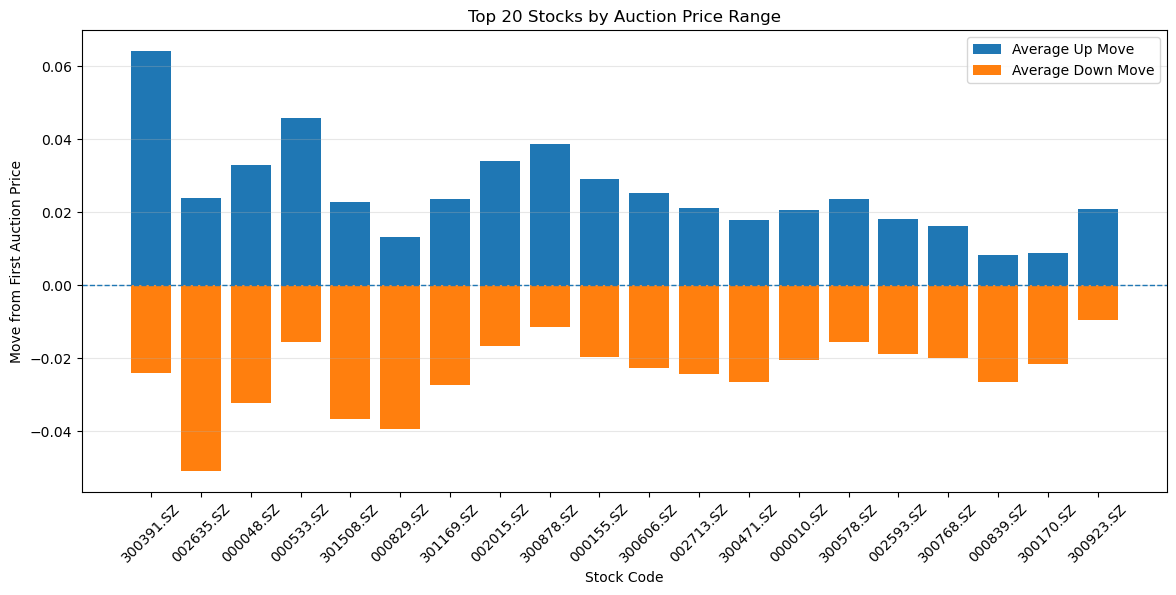

In [44]:
top20 = stock_compare.sort_values("avg_range_pct", ascending=False).head(20)

plt.figure(figsize=(14, 6))

plt.bar(top20["code"], top20["avg_up_move"], label="Average Up Move")
plt.bar(top20["code"], top20["avg_down_move"], label="Average Down Move")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Top 20 Stocks by Auction Price Range")
plt.xlabel("Stock Code")
plt.ylabel("Move from First Auction Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

统计结果显示：

平均向上波动（up_move）约为 1.56%
平均向下波动（down_move）约为 -1.62%
平均价格波动区间（price_range）约为 3.18%

不同股票之间存在明显差异，部分股票在集合竞价阶段价格波动幅度明显高于其他股票
集合竞价期间，大量买卖委托不断进入，系统不断重新计算虚拟成交价（Indicative Match Price）。价格不断上下调整，本质上是在寻找能够最大化成交量的均衡价格。因此，波动区间越大，说明市场买卖双方分歧越大；价格调整越剧烈，说明价格发现过程更加复杂；波动区间较小，则说明市场预期较一致，均衡价格能够较快形成。
价格波动区间可以作为衡量**集合竞价不确定性（Auction Uncertainty）**的重要指标

#### Price Reversals 波动次数比较

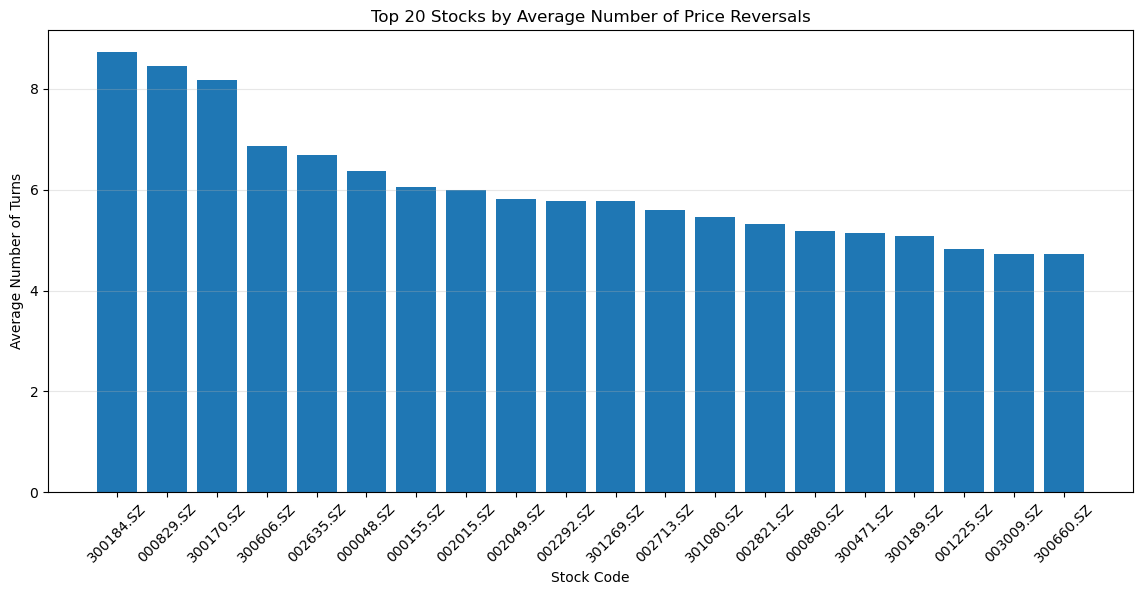

In [45]:
top20_turns = stock_compare.sort_values("avg_turns", ascending=False).head(20)

plt.figure(figsize=(14, 6))

plt.bar(top20_turns["code"], top20_turns["avg_turns"])

plt.title("Top 20 Stocks by Average Number of Price Reversals")
plt.xlabel("Stock Code")
plt.ylabel("Average Number of Turns")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

统计结果显示：

平均价格方向反转次数约为 4.3 次
部分股票平均反转次数超过 8 次

说明不同股票在集合竞价过程中存在明显不同的价格形成路径。因此，该指标能够反映：买卖双方是否持续博弈；市场是否不断修正对均衡价格的预期；价格形成过程是否稳定。相比普通波动率，价格反转次数更加关注价格形成路径（Price Formation Path），具有更强的微观结构含义。

#### last minute成交量

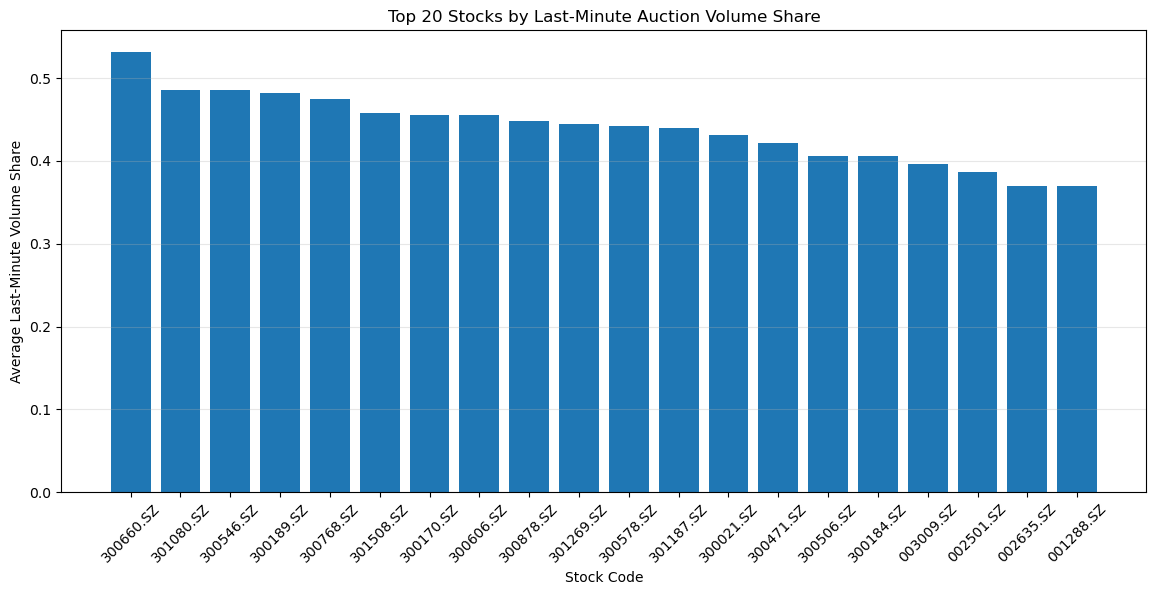

In [46]:
top20_last_min = (
    stock_compare
    .dropna(subset=["avg_last_minute_share"])
    .sort_values("avg_last_minute_share", ascending=False)
    .head(20)
)

plt.figure(figsize=(14, 6))

plt.bar(
    top20_last_min["code"],
    top20_last_min["avg_last_minute_share"]
)

plt.title("Top 20 Stocks by Last-Minute Auction Volume Share")
plt.xlabel("Stock Code")
plt.ylabel("Average Last-Minute Volume Share")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

统计结果显示：

平均约 33.7% 的成交量发生在集合竞价最后一分钟；
部分股票最后一分钟成交占比超过 50%。

说明大量成交集中发生在集合竞价结束前。随着集合竞价接近结束，投资者能够观察到更加稳定的虚拟成交价格，因此许多交易者会选择等待更多市场信息后，再于最后阶段提交委托。最后一分钟成交比例越高，说明：市场参与者倾向于延迟交易决策；大量订单集中于最后阶段进入市场；最终均衡价格主要在最后阶段完成，反映了信息到达速度以及交易的紧迫程度。

#### 趋势类型分布

In [47]:
trend_count = (
    feature_50
    .groupby(["board", "trend_label"])
    .size()
    .reset_index(name="count")
)

trend_count

,board,trend_label,count
0,chinext,down,4
1,chinext,down_smooth,52
2,chinext,down_volatile,79
3,chinext,down_with_reversal,48
4,chinext,flat,2
5,chinext,flat_smooth,2
6,chinext,flat_volatile,9
7,chinext,flat_with_reversal,5
8,chinext,up,2
9,chinext,up_smooth,39


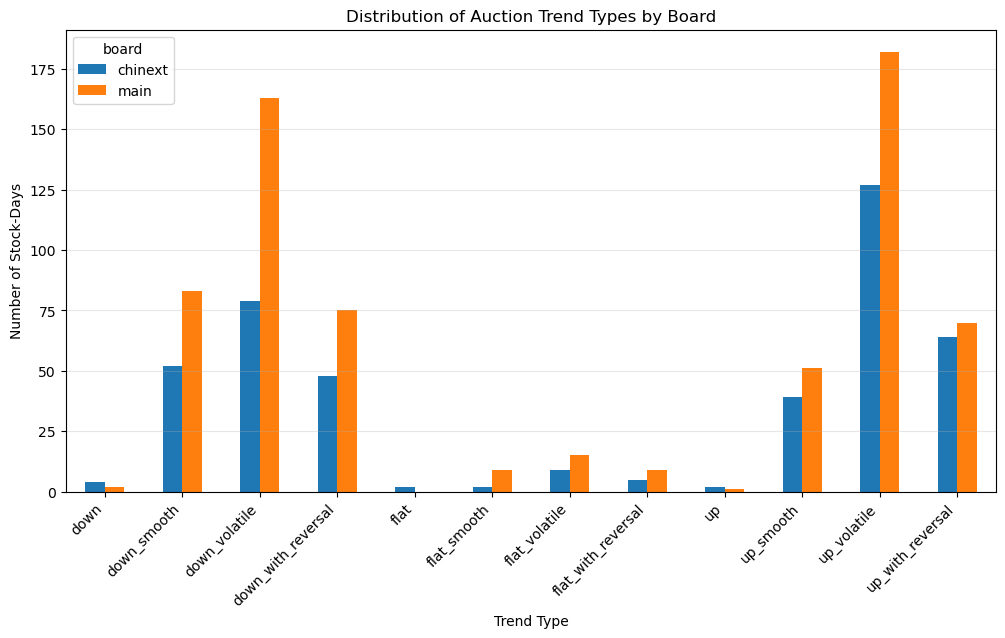

In [48]:
pivot_trend = trend_count.pivot(
    index="trend_label",
    columns="board",
    values="count"
).fillna(0)

pivot_trend.plot(kind="bar", figsize=(12, 6))

plt.title("Distribution of Auction Trend Types by Board")
plt.xlabel("Trend Type")
plt.ylabel("Number of Stock-Days")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

大多数股票属于：

up_volatile
down_volatile

说明集合竞价价格形成过程并不是简单的单边上涨或下跌，而是在不断调整中逐渐收敛至最终开盘价。市场不断吸收新增委托信息，价格持续修正，最终形成市场认可的均衡价格。

### 3.1.3 Longitudinal Analysis

#### 0. Select 15 stocks: 10 Main Board + 5 ChiNext

In [49]:
main_pool = sz_codes[sz_codes["board"] == "main"].copy()
chinext_pool = sz_codes[sz_codes["board"] == "chinext"].copy()

main_sample = main_pool.sample(
    n=min(10, len(main_pool)),
    random_state=42
)

chinext_sample = chinext_pool.sample(
    n=min(5, len(chinext_pool)),
    random_state=42
)

stock_pool_15 = pd.concat(
    [main_sample, chinext_sample],
    ignore_index=True
)

sample_codes_15 = stock_pool_15["code"].tolist()

print("Selected stocks:", len(sample_codes_15))
display(stock_pool_15)

Selected stocks: 15


,code,board
0,000950.SZ,main
1,000155.SZ,main
2,002713.SZ,main
3,000010.SZ,main
4,002708.SZ,main
5,002015.SZ,main
6,002777.SZ,main
7,001288.SZ,main
8,002292.SZ,main
9,002655.SZ,main


#### 1. Query 3-month Qtick Data for Selected Stocks

In [50]:
# ============================================================
# 1. Query 3-month qtick data for 15 stocks
# ============================================================

start_date = "2026.02.01"
end_date = "2026.04.30"

codes_str = ",".join([f'"{c}"' for c in sample_codes_15])

sql_qtick_long = f"""
select *
from loadTable("dfs://quota","qtick")
where code in ({codes_str})
  and date >= {start_date}
  and date <= {end_date}
"""

qtick_long = s.run(sql_qtick_long)

print("qtick_long shape:", qtick_long.shape)
print("stocks:", qtick_long["code"].nunique())
print("dates:", qtick_long["date"].nunique())

display(qtick_long.head())


qtick_long shape: (3602207, 78)
stocks: 15
dates: 57


,code,date,time,src,state,bp0,bp1,bp2,bp3,bp4,...,create_date,list_date,expire_date,start_settle_date,end_settle_date,exercise_date,exercise_price,cp_flag,underlying_code,trading_date
0,002292.SZ,2026-02-02,1970-01-01 08:00:00,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
1,002292.SZ,2026-02-02,1970-01-01 08:16:36,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
2,002292.SZ,2026-02-02,1970-01-01 08:16:45,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
3,002292.SZ,2026-02-02,1970-01-01 09:15:00,0,0,9.26,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
4,002292.SZ,2026-02-02,1970-01-01 09:15:09,0,0,9.37,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0


In [51]:
qtick_long = qtick_long.merge(
    stock_pool_15[["code","board"]],
    on="code",
    how="left"
)

In [52]:
qtick_long["date"] = pd.to_datetime(qtick_long["date"], errors="coerce")

print("date min:", qtick_long["date"].min())
print("date max:", qtick_long["date"].max())

display(
    qtick_long
    .assign(month=qtick_long["date"].dt.to_period("M").astype(str))
    .groupby("month")
    .agg(
        n_rows=("code", "count"),
        n_stocks=("code", "nunique"),
        n_days=("date", "nunique")
    )
    .reset_index()
)

date min: 2026-02-02 00:00:00
date max: 2026-04-30 00:00:00


,month,n_rows,n_stocks,n_days
0,2026-02,888445,15,14
1,2026-03,1384854,15,22
2,2026-04,1328908,15,21


#### 2. Feature construction function


In [53]:
def build_auction_features(qtick_data):
    df = qtick_data.copy()

    # -------------------------
    # Basic cleaning
    # -------------------------
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")

    df = df.dropna(subset=["date", "time"])

    df["datetime"] = df.apply(
        lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
        axis=1
    )

    df = df.sort_values(["code", "date", "datetime"]).reset_index(drop=True)

    # Opening call auction window
    df = df[
        (df["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
        (df["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
    ].copy()

    # -------------------------
    # Numeric columns
    # -------------------------
    num_cols = [
        "bp0", "ap0", "new_price", "pre_close", "open",
        "new_volume", "sum_volume", "new_amount", "sum_amount"
    ]

    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        else:
            df[col] = np.nan

    # -------------------------
    # Valid reference price
    # -------------------------
    for col in ["bp0", "ap0", "new_price"]:
        df.loc[df[col] <= 0, col] = np.nan

    df["mid_price"] = (df["bp0"] + df["ap0"]) / 2

    df["ref_price"] = (
        df["mid_price"]
        .fillna(df["bp0"])
        .fillna(df["ap0"])
        .fillna(df["new_price"])
    )

    df = df[df["ref_price"].notna()].copy()
    df = df[df["ref_price"] > 0].copy()

    # -------------------------
    # Volume cleaning
    # -------------------------
    for col in ["new_volume", "sum_volume", "new_amount", "sum_amount"]:
        df[col] = df[col].fillna(0)
        df.loc[df[col] < 0, col] = 0

    # -------------------------
    # Helper functions
    # -------------------------
    def count_turning_points(price_series):
        p = price_series.dropna()
        p = p[p > 0]

        if len(p) < 3:
            return np.nan

        diff = p.diff().dropna()
        diff = diff[diff != 0]

        if len(diff) < 2:
            return 0

        direction = np.sign(diff)
        turns = (direction != direction.shift()).sum() - 1

        return max(turns, 0)

    def classify_trend(ret, turns):
        if pd.isna(ret):
            return "unknown"

        if abs(ret) < 0.001:
            base = "flat"
        elif ret > 0:
            base = "up"
        else:
            base = "down"

        if pd.isna(turns):
            return base

        if turns >= 4:
            return base + "_volatile"
        elif turns >= 2:
            return base + "_with_reversal"
        else:
            return base + "_smooth"

    # -------------------------
    # Stock-day features
    # -------------------------
    features = []

    for (code, date), g in df.groupby(["code", "date"]):
        g = g.sort_values("datetime").copy()

        p = g["ref_price"].dropna()
        p = p[p > 0]

        if len(p) < 2:
            continue

        first_price = p.iloc[0]
        last_price = p.iloc[-1]
        max_price = p.max()
        min_price = p.min()

        if first_price <= 0:
            continue

        auction_return = last_price / first_price - 1
        up_move = max_price / first_price - 1
        down_move = min_price / first_price - 1
        price_range_pct = (max_price - min_price) / first_price

        n_price_changes = p.diff().dropna().ne(0).sum()
        n_turns = count_turning_points(p)

        last_minute = g[
            (g["datetime"].dt.time >= pd.to_datetime("09:29:00").time()) &
            (g["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
        ]

        total_volume = g["new_volume"].sum()
        last_minute_volume = last_minute["new_volume"].sum()

        last_minute_volume_share = (
            last_minute_volume / total_volume
            if total_volume > 0
            else np.nan
        )

        if total_volume > 0:
            volume_weighted_price = (
                (g["ref_price"] * g["new_volume"]).sum() / total_volume
            )
        else:
            volume_weighted_price = np.nan

        feature = {
            "code": code,
            "date": date,
            "month": pd.to_datetime(date).to_period("M").strftime("%Y-%m"),
            "board": g["board"].iloc[0] if "board" in g.columns else None,

            # price path
            "first_price": first_price,
            "last_price": last_price,
            "max_price": max_price,
            "min_price": min_price,

            "auction_return": auction_return,
            "up_move": up_move,
            "down_move": down_move,
            "price_range_pct": price_range_pct,
            "price_volatility": p.pct_change().std(),

            # path complexity
            "n_price_changes": n_price_changes,
            "n_turns": n_turns,

            # volume
            "total_volume": total_volume,
            "last_minute_volume": last_minute_volume,
            "last_minute_volume_share": last_minute_volume_share,

            # execution
            "volume_weighted_price": volume_weighted_price,

            # misc
            "n_ticks": len(g)
        }

        feature["trend_label"] = classify_trend(
            feature["auction_return"],
            feature["n_turns"]
        )

        features.append(feature)

    feature_df = pd.DataFrame(features)
    feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

    return feature_df

In [54]:
feature_long = build_auction_features(qtick_long)

print("feature_long shape:", feature_long.shape)
print("stocks:", feature_long["code"].nunique())
print("dates:", feature_long["date"].nunique())
print("months:", feature_long["month"].unique())

display(feature_long.head())

display(
    feature_long
    .groupby("month")
    .agg(
        n_stock_days=("code", "count"),
        n_stocks=("code", "nunique"),
        n_days=("date", "nunique")
    )
    .reset_index()
)

feature_long shape: (854, 21)
stocks: 15
dates: 57
months: ['2026-02' '2026-03' '2026-04']


,code,date,month,board,first_price,last_price,max_price,min_price,auction_return,up_move,...,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume,last_minute_volume_share,volume_weighted_price,n_ticks,trend_label
0,000010.SZ,2026-02-02,2026-02,main,3.39,3.405,3.420,3.39,0.004425,0.008850,...,0.008850,0.002343,3,1.0,97100,11200,0.115345,3.405000,18,up_smooth
1,000010.SZ,2026-02-03,2026-02,main,3.40,3.415,3.420,3.40,0.004412,0.005882,...,0.005882,0.001409,2,1.0,92900,1700,0.018299,3.415000,20,up_smooth
2,000010.SZ,2026-02-04,2026-02,main,3.51,3.525,3.525,3.46,0.004274,0.004274,...,0.018519,0.003629,7,2.0,321000,23300,0.072586,3.525000,24,up_with_reversal
3,000010.SZ,2026-02-05,2026-02,main,3.58,3.575,3.580,3.57,-0.001397,0.000000,...,0.002793,0.000777,2,1.0,47900,19000,0.396660,3.571983,18,down_smooth
4,000010.SZ,2026-02-06,2026-02,main,3.73,3.770,3.785,3.71,0.010724,0.014745,...,0.020107,0.002951,8,5.0,1176000,496000,0.421769,3.778673,46,up_volatile


,month,n_stock_days,n_stocks,n_days
0,2026-02,210,15,14
1,2026-03,330,15,22
2,2026-04,314,15,21


#### 3.1.3.1 Monthly Evolution of Auction Characteristics

In [55]:
monthly_summary = (
    feature_long
    .groupby("month")
    .agg(
        n_stock_days=("code", "count"),
        n_stocks=("code", "nunique"),
        n_days=("date", "nunique"),

        avg_return=("auction_return", "mean"),
        avg_abs_return=("auction_return", lambda x: x.abs().mean()),

        avg_range_pct=("price_range_pct", "mean"),
        avg_volatility=("price_volatility", "mean"),
        avg_turns=("n_turns", "mean"),
        avg_price_changes=("n_price_changes", "mean"),

        avg_total_volume=("total_volume", "mean"),
        avg_last_minute_share=("last_minute_volume_share", "mean")
    )
    .reset_index()
)

display(monthly_summary)

,month,n_stock_days,n_stocks,n_days,avg_return,avg_abs_return,avg_range_pct,avg_volatility,avg_turns,avg_price_changes,avg_total_volume,avg_last_minute_share
0,2026-02,210,15,14,-0.003779,0.016332,0.023518,0.003045,3.695238,10.280952,501683.438095,0.326594
1,2026-03,330,15,22,-0.001185,0.017200,0.027832,0.003809,4.409231,11.436364,704995.609091,0.330183
2,2026-04,314,15,21,-0.002868,0.016979,0.028565,0.004072,4.375000,11.464968,790519.621019,0.327896


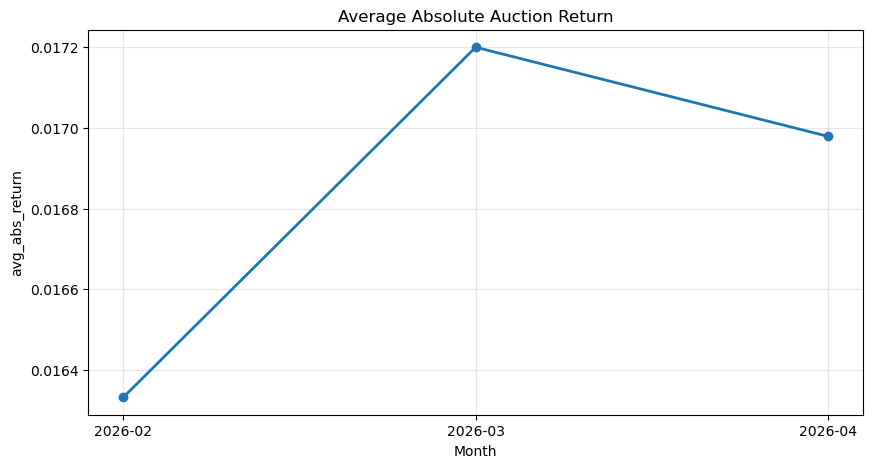

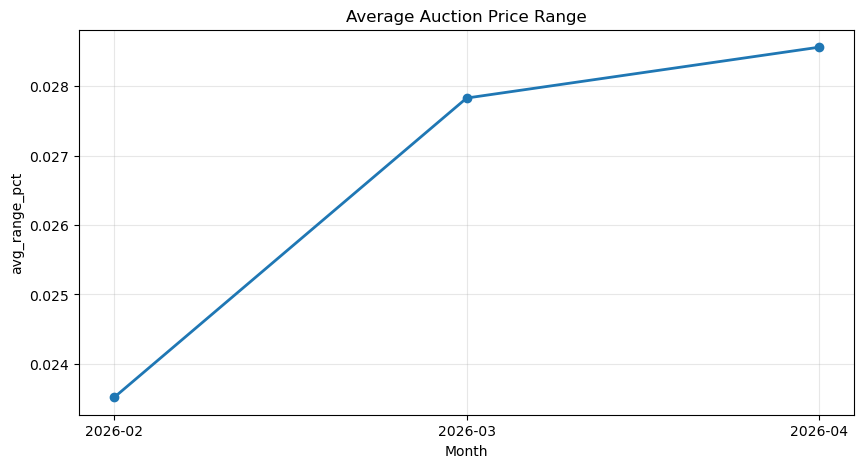

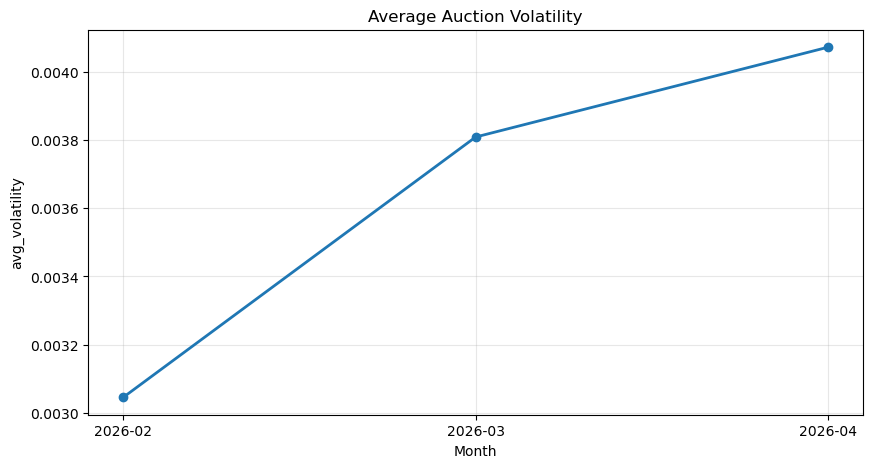

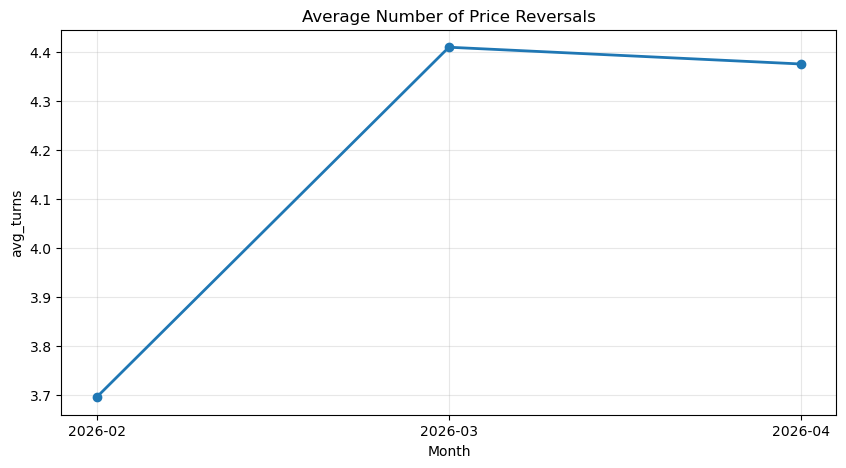

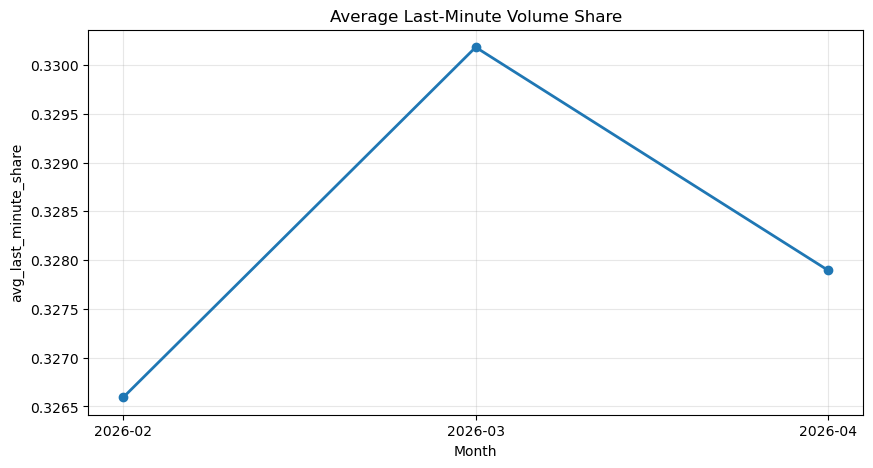

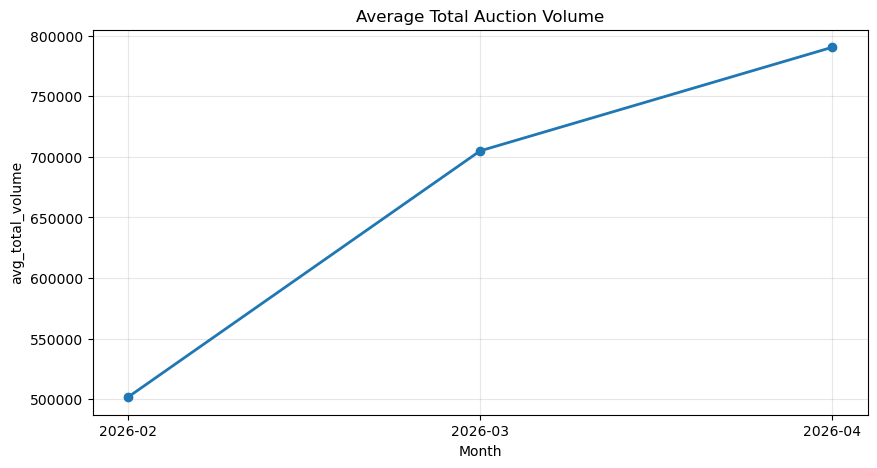

In [56]:
monthly_metrics = {
    "avg_abs_return": "Average Absolute Auction Return",
    "avg_range_pct": "Average Auction Price Range",
    "avg_volatility": "Average Auction Volatility",
    "avg_turns": "Average Number of Price Reversals",
    "avg_last_minute_share": "Average Last-Minute Volume Share",
    "avg_total_volume": "Average Total Auction Volume"
}

for metric, title in monthly_metrics.items():
    plt.figure(figsize=(10, 5))

    plt.plot(
        monthly_summary["month"],
        monthly_summary[metric],
        marker="o",
        linewidth=2
    )

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel(metric)
    plt.grid(alpha=0.3)
    plt.show()

##### Figure 1. Average Absolute Auction Return
三个月内，平均绝对收益率（Average Absolute Auction Return）整体保持稳定，仅在 3 月略有上升，4 月略有回落，整体波动幅度较小。

尽管不同月份市场成交活跃程度有所变化，但集合竞价最终形成的价格偏离幅度并未出现明显变化。

这一结果说明，集合竞价最终形成的开盘价格具有较好的稳定性。

随着市场交易活跃程度提升，价格发现过程可能更加复杂，但最终形成的均衡价格并不会因此产生更大的偏离。

因此，Auction Return 更像是价格发现结果（Outcome），而不是价格发现过程（Process）的体现。

##### Figure 2. Average Auction Price Range
平均价格波动区间（Price Range）呈现持续上升趋势：

2 月约为 2.35%
3 月约为 2.78%
4 月约为 2.86%

说明价格探索范围逐渐扩大。

价格波动区间反映的是集合竞价期间市场寻找均衡价格所经历的调整范围。随着时间推移，市场参与度不断提高，买卖双方报价更加积极，使得虚拟成交价格经历了更大的上下调整。

因此，可以认为：市场越活跃，价格发现过程越充分，均衡价格需要经历更大的搜索空间才能形成。
Price Range 可以作为衡量 Auction Uncertainty（集合竞价不确定性）的重要指标。

##### Figure 3. Average Auction Volatility
Auction Volatility 在三个月内持续上升，与 Price Range 呈现一致趋势。

说明集合竞价期间价格变化越来越频繁，短时间内价格波动幅度有所增加。

Volatility 描述的是价格变化速度，而 Price Range 描述的是价格探索空间。

二者同步增加说明：

价格不仅探索范围更大，而且探索过程更加活跃。因此，随着市场成交更加活跃，价格发现过程逐渐由相对平稳演变为更加动态的调整过程。

##### Figure 4. Average Number of Price Reversals
Observation

平均价格反转次数（Price Reversals）由 2 月约 3.7 次 上升至 3 月 4.4 次，4 月保持在相近水平。

说明价格方向变化更加频繁。

Analysis

价格反转次数衡量的是价格形成过程中方向切换的频率，而不是价格波动大小。

反转次数增加意味着：

买卖双方对于合理价格存在更大分歧；
新进入订单不断修正市场预期；
价格形成过程更加复杂。

相比传统波动率，Price Reversal 更能够体现集合竞价中的市场博弈程度（Market Interaction）。

##### Figure 5. Average Last-Minute Volume Share
Observation

三个月中，最后一分钟成交占比始终保持在 约 33% 左右，几乎没有明显变化。

即使整体成交量增加，该比例依然十分稳定。

Analysis

这一结果说明：

最后一分钟成交集中现象并非由市场环境决定，而更可能来源于集合竞价机制本身。

随着集合竞价接近结束，市场能够观察到更加稳定的虚拟成交价格，因此大量投资者倾向于在最后阶段提交委托。

因此：

Last-Minute Volume Share 更像是一种制度特征（Structural Characteristic），而不是市场情绪特征。

##### Figure 6. Average Total Auction Volume
Observation

平均成交量呈持续增长趋势：

2 月约 50 万股
3 月约 70 万股
4 月约 79 万股

说明市场交易活跃程度不断提高。

Analysis

成交量增加意味着更多投资者参与集合竞价。

与此同时：

Price Range 上升；
Volatility 上升；
Price Reversal 上升。

说明成交量增加不仅带来了更多交易，也使价格发现过程更加充分。

因此，本研究初步认为：

更高的市场流动性对应更加活跃的价格发现过程。

### 3.1.3.2 Board Comparison

In [57]:
qtick_long = qtick_long.drop(
    columns=["board", "board_x", "board_y"],
    errors="ignore"
)

# Merge clean board info from stock_pool_15
qtick_long = qtick_long.merge(
    stock_pool_15[["code", "board"]],
    on="code",
    how="left"
)

print(qtick_long["board"].value_counts(dropna=False))
display(qtick_long[["code", "board"]].drop_duplicates().sort_values("code"))

board
main       2533733
chinext    1068474
Name: count, dtype: int64


,code,board
31518,000010.SZ,main
10726,000155.SZ,main
26912,000950.SZ,main
53128,001288.SZ,main
35459,002015.SZ,main
0,002292.SZ,main
40151,002655.SZ,main
15528,002708.SZ,main
4816,002713.SZ,main
19961,002777.SZ,main


In [58]:
feature_long = build_auction_features(qtick_long)

print(feature_long["board"].value_counts(dropna=False))
display(feature_long.head())

board
main       569
chinext    285
Name: count, dtype: int64


,code,date,month,board,first_price,last_price,max_price,min_price,auction_return,up_move,...,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume,last_minute_volume_share,volume_weighted_price,n_ticks,trend_label
0,000010.SZ,2026-02-02,2026-02,main,3.39,3.405,3.420,3.39,0.004425,0.008850,...,0.008850,0.002343,3,1.0,97100,11200,0.115345,3.405000,18,up_smooth
1,000010.SZ,2026-02-03,2026-02,main,3.40,3.415,3.420,3.40,0.004412,0.005882,...,0.005882,0.001409,2,1.0,92900,1700,0.018299,3.415000,20,up_smooth
2,000010.SZ,2026-02-04,2026-02,main,3.51,3.525,3.525,3.46,0.004274,0.004274,...,0.018519,0.003629,7,2.0,321000,23300,0.072586,3.525000,24,up_with_reversal
3,000010.SZ,2026-02-05,2026-02,main,3.58,3.575,3.580,3.57,-0.001397,0.000000,...,0.002793,0.000777,2,1.0,47900,19000,0.396660,3.571983,18,down_smooth
4,000010.SZ,2026-02-06,2026-02,main,3.73,3.770,3.785,3.71,0.010724,0.014745,...,0.020107,0.002951,8,5.0,1176000,496000,0.421769,3.778673,46,up_volatile


In [59]:
monthly_board_summary = (
    feature_long
    .groupby(["month", "board"])
    .agg(
        n_stock_days=("code", "count"),
        n_stocks=("code", "nunique"),
        n_days=("date", "nunique"),

        avg_abs_return=("auction_return", lambda x: x.abs().mean()),
        avg_range_pct=("price_range_pct", "mean"),
        avg_volatility=("price_volatility", "mean"),
        avg_turns=("n_turns", "mean"),
        avg_last_minute_share=("last_minute_volume_share", "mean"),
        avg_total_volume=("total_volume", "mean")
    )
    .reset_index()
)

display(monthly_board_summary)

,month,board,n_stock_days,n_stocks,n_days,avg_abs_return,avg_range_pct,avg_volatility,avg_turns,avg_last_minute_share,avg_total_volume
0,2026-02,chinext,70,5,14,0.012393,0.016440,0.002872,3.771429,0.441255,169553.114286
1,2026-02,main,140,10,14,0.018302,0.027057,0.003132,3.657143,0.269264,667748.600000
2,2026-03,chinext,110,5,22,0.010456,0.020241,0.003646,4.240741,0.421171,211232.100000
3,2026-03,main,220,10,22,0.020571,0.031627,0.003890,4.493088,0.284689,951877.363636
4,2026-04,chinext,105,5,21,0.015425,0.027255,0.004828,4.349515,0.434638,487363.504762
5,2026-04,main,209,10,21,0.017759,0.029223,0.003700,4.387560,0.274781,942822.933014


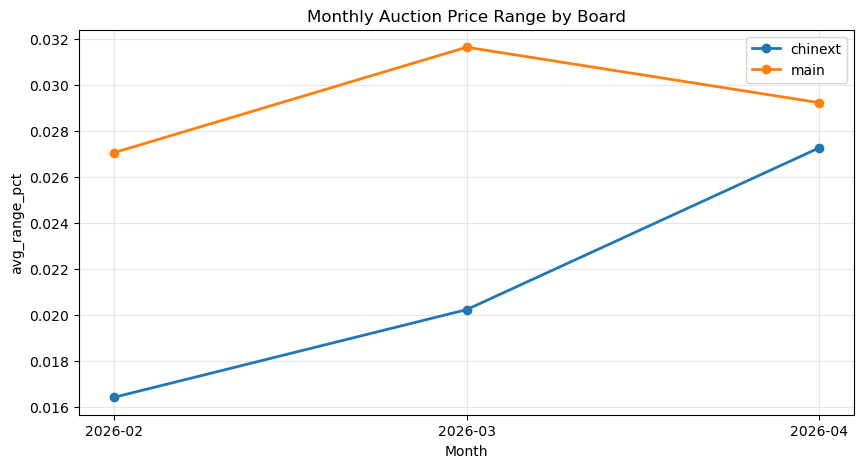

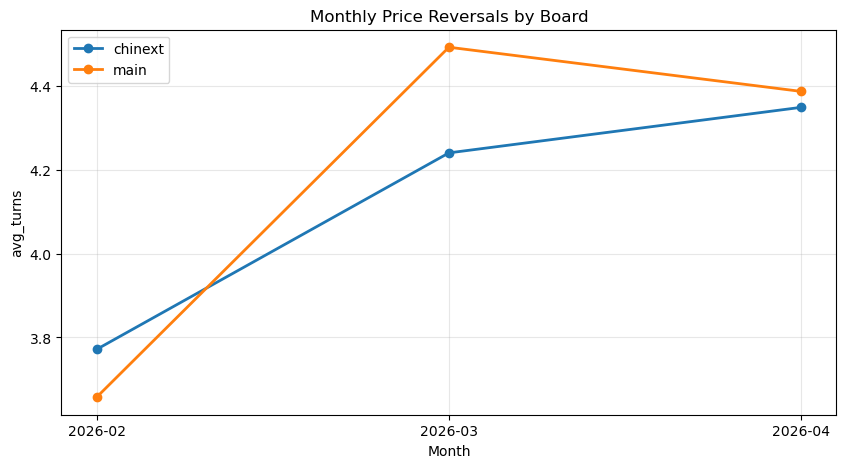

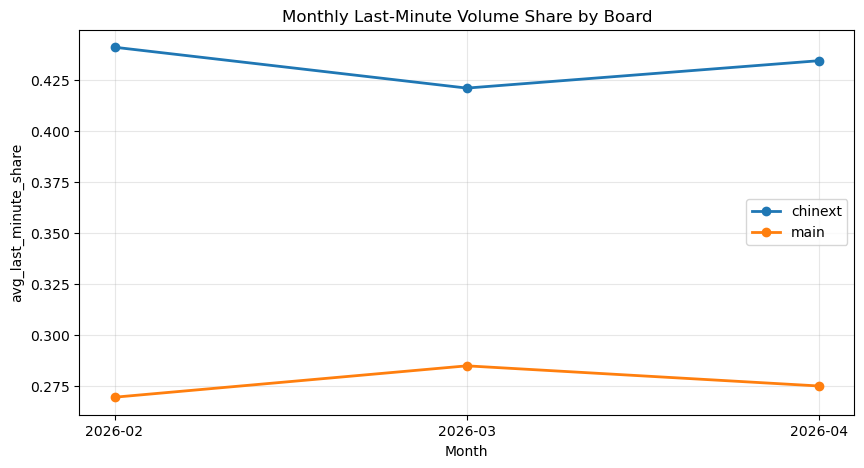

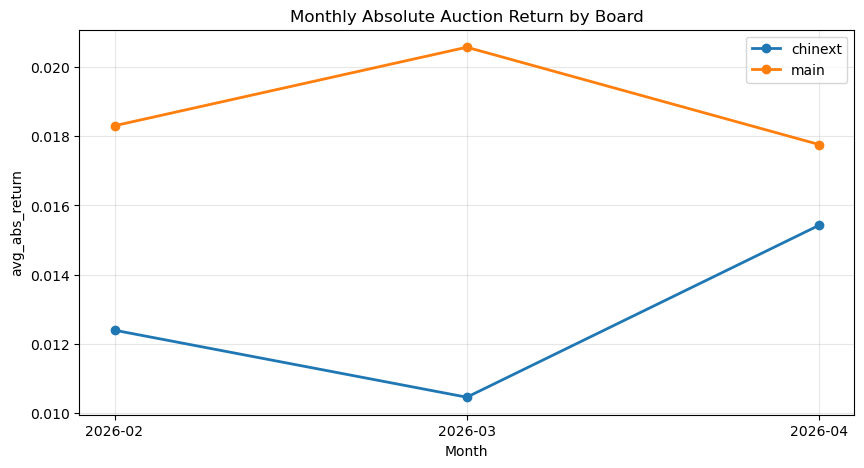

In [60]:
board_metrics = {
    "avg_range_pct": "Monthly Auction Price Range by Board",
    "avg_turns": "Monthly Price Reversals by Board",
    "avg_last_minute_share": "Monthly Last-Minute Volume Share by Board",
    "avg_abs_return": "Monthly Absolute Auction Return by Board"
}

for metric, title in board_metrics.items():
    plt.figure(figsize=(10, 5))

    for board in monthly_board_summary["board"].dropna().unique():
        temp = monthly_board_summary[
            monthly_board_summary["board"] == board
        ].sort_values("month")

        plt.plot(
            temp["month"],
            temp[metric],
            marker="o",
            linewidth=2,
            label=board
        )

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

在本样本中，
##### Figure 7. Monthly Auction Price Range by Board
主板股票在三个月内始终表现出更大的价格波动区间，但创业板 Price Range 增长速度更快，两者之间的差距逐渐缩小。

主板股票整体价格发现空间较大，说明其集合竞价期间价格调整更加充分。然而，创业板在市场活跃时期价格波动区间增长更快，表明成长型股票对于市场环境变化具有更高敏感性。

##### Figure 8. Monthly Price Reversals by Board
两类股票价格反转次数均随时间增加。主板整体略高于创业板，但两者逐渐趋于接近。

这一结果说明：
无论板块如何，随着市场活跃程度提升，价格形成路径都会变得更加复杂。
创业板价格发现复杂度提升速度更快，而主板则始终保持较高水平。

##### Figure 9. Monthly Last-Minute Volume Share by Board
创业板最后一分钟成交占比始终维持在 约 42%，明显高于主板约 27%。
两者在三个月内均保持稳定。

说明：创业板投资者更倾向于等待更多市场信息，在集合竞价最后阶段集中提交订单。相比之下，主板投资者委托时间分布更加均匀。

因此：
创业板具有更明显的“最后一分钟交易”特征，体现出更强的信息等待行为。

##### Figure 10. Monthly Absolute Auction Return by Board
主板股票平均绝对收益率整体高于创业板。创业板在 4 月有所上升，但整体仍低于主板。

说明主板股票最终形成的开盘价格偏离程度略高。然而，两类股票变化趋势整体较为平稳，并未随着市场活跃程度增加而出现明显扩大。因此，最终价格结果相对稳定，而真正发生变化的是价格发现过程本身。

这说明,
1. 集合竞价最终形成的价格结果相对稳定。
无论市场活跃程度如何变化，Auction Return 并未出现明显变化，说明集合竞价能够较稳定地形成均衡开盘价。
2. 价格发现过程随着市场活跃度提升而更加复杂。
Price Range、Volatility、Price Reversal 以及 Total Volume 均呈现上升趋势，说明价格发现过程更加充分，市场参与者之间的博弈更加激烈。
3. 最后一分钟成交集中度具有明显制度特征。
Last-Minute Volume Share 在不同月份保持稳定，表明成交时间分布主要由集合竞价规则决定，而非市场情绪驱动。
4. 创业板与主板表现出不同的市场微观结构特征。
创业板具有更高的最后一分钟成交占比，说明投资者更加倾向于延迟决策；而主板整体价格波动区间更大，但创业板对市场环境变化的响应速度更快。

## 3.2 Exchange Extension: SSE Order Flow Analysis
In the previous sections, the analysis mainly relies on SZSE `qtick` snapshots to study the evolution of the indicative auction price and trading volume.

However, for SSE stocks, the available `qtick` snapshots do not provide sufficient pre-9:25 auction price paths. Therefore, instead of forcing the same snapshot-based framework, this section uses `qorder` data to study the order flow dynamics during the opening call auction.

This shifts the analysis from a **state-based view** to a **flow-based view**:
- `qtick`: observes the state of the order book at each snapshot.
- `qorder`: observes individual order submissions and cancellations.

### 3.2.1 Data Processing

#### Load SSE Qorder

In [7]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

from src.ddb_client import connect_ddb

s = connect_ddb()

script = """
select distinct code
from loadTable("dfs://quota","qorder")
where date >= 2026.02.01
  and date <= 2026.04.30
  and code like "%.SH"
limit 1000
"""

sh_codes = s.run(script)

print("Total SH stocks:", len(sh_codes))

display(sh_codes.head())

Total SH stocks: 1000


,code
0,600151.SH
1,600650.SH
2,603086.SH
3,603001.SH
4,603856.SH


#### Randomly Sample 15 Shanghai Stocks

In [8]:
sh_sample = sh_codes.sample(
    n=15,
    random_state=42
).reset_index(drop=True)

sample_codes_sh = sh_sample["code"].tolist()

print("Selected stocks:", len(sample_codes_sh))

display(sh_sample)

Selected stocks: 15


,code
0,600801.SH
1,560060.SH
2,184816.SH
3,600851.SH
4,019681.SH
5,508080.SH
6,688617.SH
7,511070.SH
8,019639.SH
9,516360.SH


#### Load qorder

In [9]:
start_date = "2026.02.01"
end_date = "2026.04.30"

codes_str = ",".join(
    [f'"{c}"' for c in sample_codes_sh]
)

script = f"""
select *
from loadTable("dfs://quota","qorder")
where code in ({codes_str})
and date >= {start_date}
and date <= {end_date}
"""

qorder_sh = s.run(script)

print("qorder_sh shape:", qorder_sh.shape)
print("Stocks:", qorder_sh["code"].nunique())
print("Trading Days:", qorder_sh["date"].nunique())

display(qorder_sh.head())

qorder_sh shape: (24338930, 8)
Stocks: 15
Trading Days: 57


,code,date,time,order_no,bs_flag,order_type,order_price,order_volume
0,688779.SH,2026-02-02,1970-01-01 09:15:00.330,1512,2,0,117900.0,200
1,688779.SH,2026-02-02,1970-01-01 09:15:00.460,2374,2,0,118700.0,1000
2,688779.SH,2026-02-02,1970-01-01 09:15:01.260,4935,2,0,119600.0,2000
3,688779.SH,2026-02-02,1970-01-01 09:15:01.690,7052,2,0,103500.0,9900
4,688779.SH,2026-02-02,1970-01-01 14:27:40.360,7052,2,3,0.0,9900


#### Basic Cleaning

In [10]:
qorder_sh["date"] = pd.to_datetime(
    qorder_sh["date"],
    errors="coerce"
)

qorder_sh["time"] = pd.to_datetime(
    qorder_sh["time"],
    errors="coerce"
)

qorder_sh = qorder_sh.dropna(
    subset=["date", "time"]
)

qorder_sh["datetime"] = qorder_sh.apply(
    lambda x: pd.Timestamp.combine(
        x["date"].date(),
        x["time"].time()
    ),
    axis=1
)

qorder_sh = qorder_sh.sort_values(
    ["code", "date", "datetime"]
).reset_index(drop=True)

display(qorder_sh.head())

,code,date,time,order_no,bs_flag,order_type,order_price,order_volume,datetime
0,019639.SH,2026-02-02,1970-01-01 09:15:00.852,29756,1,0,1055440.0,1000,2026-02-02 09:15:00.852
1,019639.SH,2026-02-02,1970-01-01 09:30:01.811,187421,1,0,1039290.0,1000,2026-02-02 09:30:01.811
2,019639.SH,2026-02-02,1970-01-01 09:30:03.653,208108,1,0,1055450.0,12000,2026-02-02 09:30:03.653
3,019639.SH,2026-02-02,1970-01-01 09:31:35.539,800520,1,0,1045740.0,10000,2026-02-02 09:31:35.539
4,019639.SH,2026-02-02,1970-01-01 09:31:47.523,187421,1,3,0.0,1000,2026-02-02 09:31:47.523


#### Auction Period

In [11]:
qorder_sh = qorder_sh[
    (qorder_sh["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (qorder_sh["datetime"].dt.time <= pd.to_datetime("09:25:00").time())
].copy()

print("Rows:", len(qorder_sh))
print("Stocks:", qorder_sh["code"].nunique())
print("Trading Days:", qorder_sh["date"].nunique())

display(qorder_sh.head())

Rows: 131386
Stocks: 15
Trading Days: 57


,code,date,time,order_no,bs_flag,order_type,order_price,order_volume,datetime
0,019639.SH,2026-02-02,1970-01-01 09:15:00.852,29756,1,0,1055440.0,1000,2026-02-02 09:15:00.852
102,019639.SH,2026-02-06,1970-01-01 09:15:00.660,21486,1,0,1056390.0,1000,2026-02-06 09:15:00.660
111,019639.SH,2026-02-09,1970-01-01 09:15:04.410,44174,1,0,1056570.0,1000,2026-02-09 09:15:04.410
157,019639.SH,2026-02-11,1970-01-01 09:15:00.578,18356,1,0,1057200.0,1000,2026-02-11 09:15:00.578
171,019639.SH,2026-02-13,1970-01-01 09:15:00.531,18619,1,0,1058000.0,1000,2026-02-13 09:15:00.531


#### Numeric Conversion and Decode Fields

In [12]:
numeric_cols = [
    "bs_flag",
    "order_type",
    "order_price",
    "order_volume",
    "order_no"
]

for col in numeric_cols:

    qorder_sh[col] = (
        qorder_sh[col]
        .astype(str)
        .str.replace("\\", "", regex=False)
    )

    qorder_sh[col] = pd.to_numeric(
        qorder_sh[col],
        errors="coerce"
    )

display(
    qorder_sh[
        [
            "bs_flag",
            "order_type",
            "order_price",
            "order_volume"
        ]
    ].head()
)

,bs_flag,order_type,order_price,order_volume
0,1,0,1055440.0,1000
102,1,0,1056390.0,1000
111,1,0,1056570.0,1000
157,1,0,1057200.0,1000
171,1,0,1058000.0,1000


In [13]:
qorder_sh["side"] = qorder_sh["bs_flag"].map({
    1: "buy",
    2: "sell"
})

qorder_sh["action"] = qorder_sh["order_type"].map({
    0: "submit",
    3: "cancel"
})

display(
    qorder_sh[
        [
            "bs_flag",
            "side",
            "order_type",
            "action"
        ]
    ].head(20)
)

,bs_flag,side,order_type,action
0,1,buy,0,submit
102,1,buy,0,submit
111,1,buy,0,submit
157,1,buy,0,submit
171,1,buy,0,submit
381,1,buy,0,submit
425,1,buy,0,submit
764,1,buy,0,submit
854,1,buy,0,submit
861,1,buy,0,submit


### 3.2.2 Data Overview

In [ ]:
print("=" * 60)

print("Rows:", len(qorder_sh))

print("Stocks:", qorder_sh["code"].nunique())

print("Trading Days:", qorder_sh["date"].nunique())

print()

print("Buy / Sell")

display(
    qorder_sh["side"].value_counts()
)

print()

print("Submit / Cancel")

display(
    qorder_sh["action"].value_counts()
)

print()

print("Average Orders per Day")

display(

    qorder_sh.groupby(
        ["code", "date"]
    ).size().describe()

)

Rows: 131386
Stocks: 15
Trading Days: 57

Buy / Sell


side
sell    82202
buy     49184
Name: count, dtype: int64


Submit / Cancel


action
submit    128057
cancel      3329
Name: count, dtype: int64


Average Orders per Day


count     791.000000
mean      166.101138
std       228.501707
min         1.000000
25%        27.000000
50%        42.000000
75%       252.000000
max      1703.000000
dtype: float64

Observation

The number of submitted order events during the opening auction varies substantially across stock-days.

The median number of orders is only 42, while the most active stock-day contains 1,703 order events.

The large gap between the median and maximum, together with a standard deviation larger than the mean, indicates a highly right-skewed distribution.

Analysis

This suggests that opening auction participation is highly heterogeneous across stocks.

Most stocks experience relatively limited order activity, while a small subset attracts intense order submissions and cancellations during the auction period.

Such heterogeneity is consistent with financial market microstructure, where liquidity tends to concentrate in actively traded securities rather than being evenly distributed across the market.

The strong dispersion also implies that order intensity itself may contain useful information and should be considered as a potential explanatory feature in subsequent analysis.

#### Distribution of Orders per Stock-day

In [16]:
orders_per_day = (
    qorder_sh
    .groupby(["code", "date"])
    .size()
)


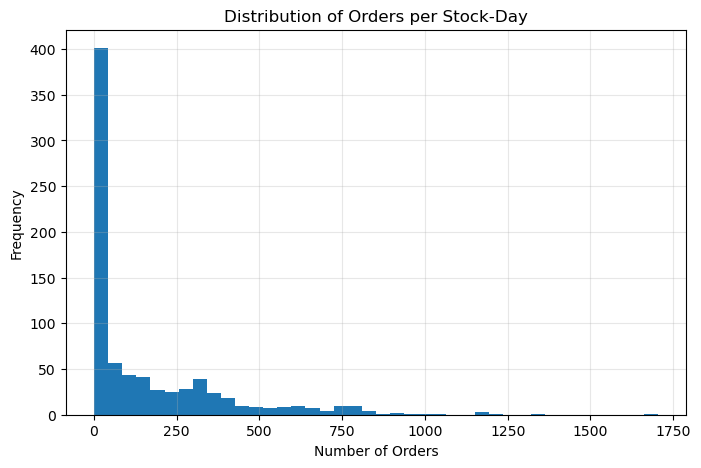

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    orders_per_day,
    bins=40
)

plt.title("Distribution of Orders per Stock-Day")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

The distribution of daily order counts is strongly right-skewed.

Most stock-days contain fewer than one hundred auction orders, whereas only a limited number of observations exhibit extremely intensive order activity.

The distribution displays a pronounced long right tail extending to more than 1,500 orders.

The skewed distribution demonstrates considerable heterogeneity in auction participation across stocks.

Such a distribution is typical for financial market activity, where liquidity is concentrated in a relatively small number of actively traded securities.

Because of this skewness, subsequent quantitative analysis should consider robust statistics or transformed variables (e.g., logarithmic order counts) when using order activity as predictive features.

#### Order Activity Distribution

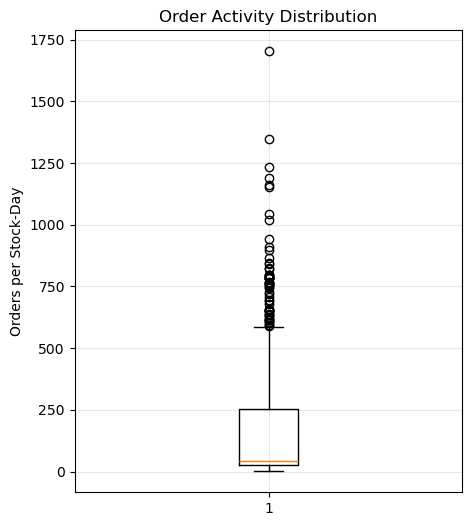

In [18]:
plt.figure(figsize=(5,6))

plt.boxplot(
    orders_per_day,
    vert=True
)

plt.ylabel("Orders per Stock-Day")
plt.title("Order Activity Distribution")

plt.grid(alpha=0.3)

plt.show()

Daily order activity exhibits substantial dispersion across stock-days.

Although the median number of orders remains relatively low, numerous observations lie far above the upper quartile, with the most active stock-day exceeding 1,700 orders.

The large number of upper-tail outliers indicates that auction activity is highly concentrated in a subset of actively traded securities.

These observations likely reflect genuine differences in market liquidity rather than data anomalies.

Highly liquid securities naturally attract more order submissions and cancellations during the opening auction. Consequently, order activity itself may serve as a useful proxy for market attention and liquidity.

Rather than removing these outliers, they should be retained as representative examples of highly active trading behavior.

#### Order Volume

(array([4.0000e+00, 3.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+01,
        1.0000e+00, 8.0000e+00, 1.0000e+00, 0.0000e+00, 7.0000e+00,
        1.7000e+01, 1.3000e+01, 1.1000e+01, 2.6000e+01, 2.3053e+04,
        2.6000e+01, 2.7000e+01, 1.8940e+04, 4.3500e+02, 7.8450e+03,
        4.8000e+03, 1.3658e+04, 4.7800e+03, 1.4525e+04, 3.2260e+03,
        3.0320e+03, 8.1950e+03, 5.3580e+03, 2.9420e+03, 4.6400e+03,
        1.6700e+03, 1.3580e+03, 6.1220e+03, 1.5080e+03, 7.1600e+02,
        1.3840e+03, 7.6200e+02, 3.4600e+02, 5.3800e+02, 3.4500e+02,
        1.2200e+02, 2.1800e+02, 2.0500e+02, 1.8600e+02, 1.3300e+02,
        3.1000e+01, 1.5000e+01, 1.1000e+02, 4.0000e+00, 2.8000e+01]),
 array([ 0.69314718,  0.95559447,  1.21804176,  1.48048904,  1.74293633,
         2.00538362,  2.26783091,  2.53027819,  2.79272548,  3.05517277,
         3.31762006,  3.58006734,  3.84251463,  4.10496192,  4.36740921,
         4.62985649,  4.89230378,  5.15475107,  5.41719836,  5.67964564,
         5.94209293,  6.20

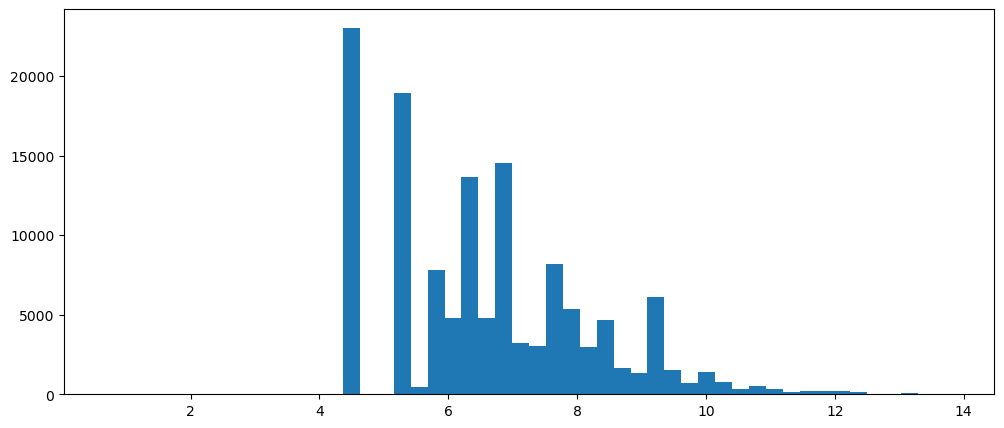

In [19]:
plt.hist(np.log1p(qorder_sh["order_volume"]), bins=50)

The logarithm of order volume exhibits a multi-modal distribution rather than a single symmetric peak.

Most submitted orders are concentrated within a relatively narrow range of order sizes, while a smaller number of large orders form a long right tail.

This suggests that investors tend to submit orders with several preferred size levels instead of continuously varying order sizes.

### 3.2.3 Order Activity

#### 3.2.3.1 Buy vs Sell Submitted Volume

,side,order_count,order_volume
0,buy,49184,301051914
1,sell,82202,263589435


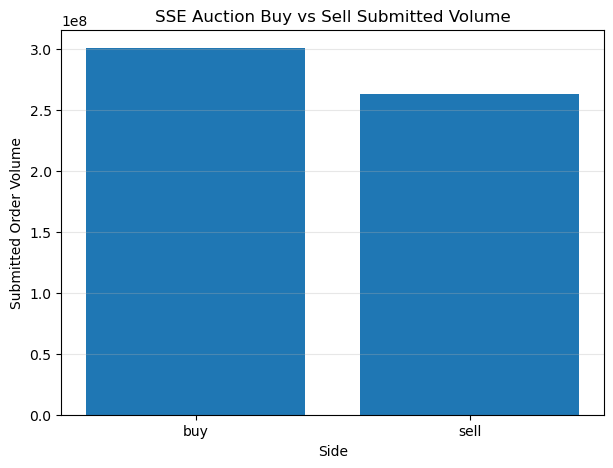

In [20]:
buy_sell_summary = (
    qorder_sh
    .groupby(["side"])
    .agg(
        order_count=("order_no", "count"),
        order_volume=("order_volume", "sum")
    )
    .reset_index()
)

display(buy_sell_summary)

plt.figure(figsize=(7, 5))

plt.bar(
    buy_sell_summary["side"],
    buy_sell_summary["order_volume"]
)

plt.title("SSE Auction Buy vs Sell Submitted Volume")
plt.xlabel("Side")
plt.ylabel("Submitted Order Volume")
plt.grid(axis="y", alpha=0.3)

plt.show()

#### 3.2.3.2 Submit vs Cancel Volume

,action,order_count,order_volume
0,cancel,3329,28516549
1,submit,128057,536124800


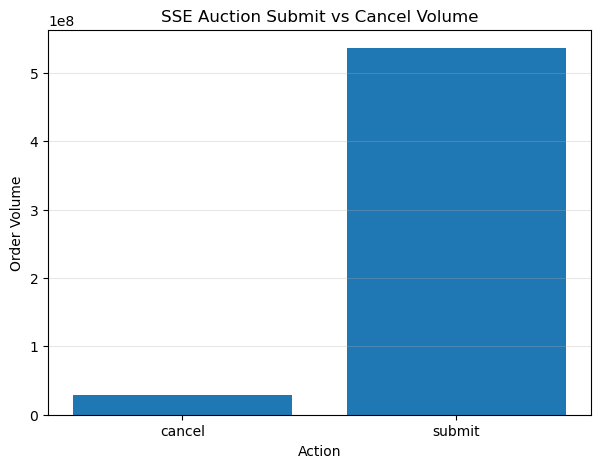

Cancel Volume Ratio: 0.05319013222294511


In [21]:
submit_cancel_summary = (
    qorder_sh
    .groupby(["action"])
    .agg(
        order_count=("order_no", "count"),
        order_volume=("order_volume", "sum")
    )
    .reset_index()
)

display(submit_cancel_summary)

plt.figure(figsize=(7, 5))

plt.bar(
    submit_cancel_summary["action"],
    submit_cancel_summary["order_volume"]
)

plt.title("SSE Auction Submit vs Cancel Volume")
plt.xlabel("Action")
plt.ylabel("Order Volume")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Cancellation ratios
total_submit_volume = submit_cancel_summary.loc[
    submit_cancel_summary["action"] == "submit",
    "order_volume"
].sum()

total_cancel_volume = submit_cancel_summary.loc[
    submit_cancel_summary["action"] == "cancel",
    "order_volume"
].sum()

cancel_volume_ratio = (
    total_cancel_volume / total_submit_volume
    if total_submit_volume > 0
    else np.nan
)

print("Cancel Volume Ratio:", cancel_volume_ratio)

Cancellation behavior reflects how actively traders revise their orders before the opening price is determined.

### 3.2.4 Intraday Auction Dynamics

#### 3.2.4.1 Average Minute Arrival Profile

,clock_minute,side,avg_order_count,avg_order_volume
0,09:15,buy,30.626156,150106.103038
1,09:15,sell,62.646438,185566.172823
2,09:16,buy,2.907950,93502.571130
3,09:16,sell,4.654618,31398.176707
4,09:17,buy,3.307317,33643.419512


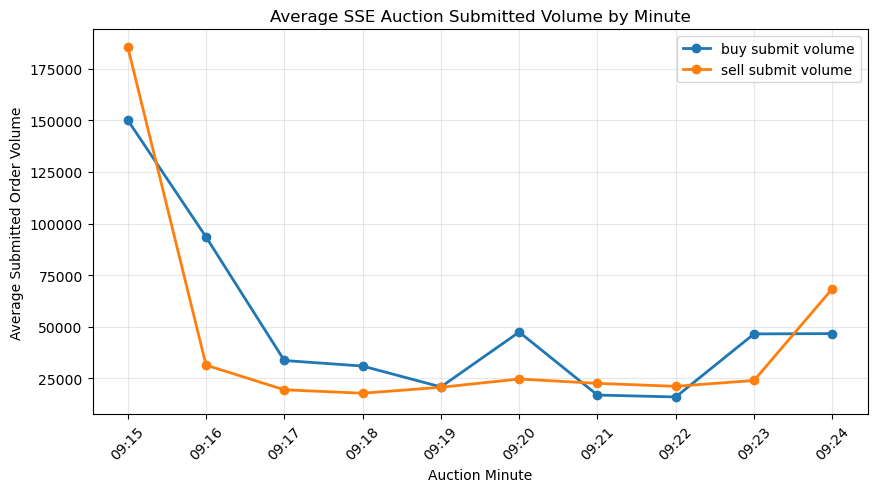

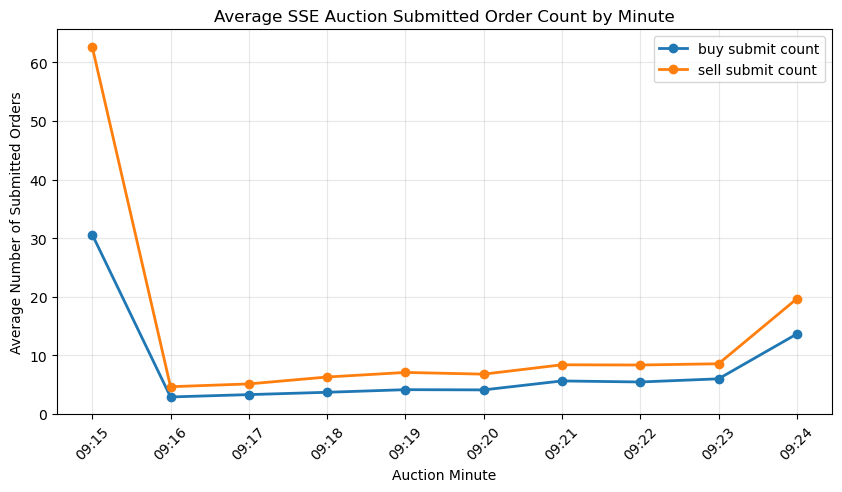

side,buy,sell,submit_imbalance
clock_minute,,,
09:15,150106.103038,185566.172823,-0.105639
09:16,93502.571130,31398.176707,0.497230
09:17,33643.419512,19447.448198,0.267390
09:18,30951.745902,17790.241546,0.270024
09:19,20837.228814,20668.022901,0.004077
09:20,47430.295276,24674.615721,0.315591
09:21,16902.873596,22559.372283,-0.143340
09:22,15981.481572,21131.049763,-0.138756
09:23,46523.686200,23960.188641,0.320123


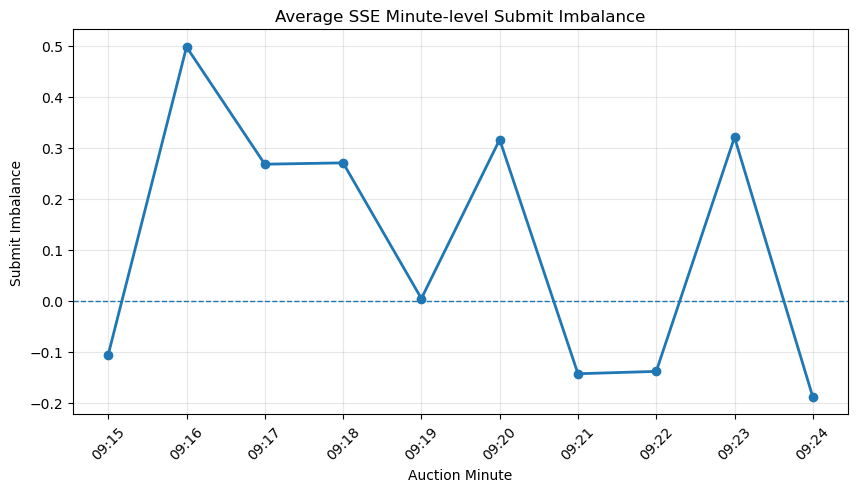

In [28]:
qorder_sh = qorder_sh.copy()

# Keep only submit orders
submit_orders = qorder_sh[qorder_sh["action"] == "submit"].copy()

# Extract intraday minute only, instead of full calendar datetime
submit_orders["clock_minute"] = submit_orders["datetime"].dt.strftime("%H:%M")

minute_profile = (
    submit_orders
    .groupby(["date", "code", "clock_minute", "side"])
    .agg(
        order_count=("order_no", "count"),
        order_volume=("order_volume", "sum")
    )
    .reset_index()
)

# Average across stock-days
avg_minute_profile = (
    minute_profile
    .groupby(["clock_minute", "side"])
    .agg(
        avg_order_count=("order_count", "mean"),
        avg_order_volume=("order_volume", "mean")
    )
    .reset_index()
)

display(avg_minute_profile.head())

# Plot average submitted volume by intraday minute
plt.figure(figsize=(10, 5))

for side in ["buy", "sell"]:
    temp = avg_minute_profile[
        avg_minute_profile["side"] == side
    ].sort_values("clock_minute")

    plt.plot(
        temp["clock_minute"],
        temp["avg_order_volume"],
        marker="o",
        linewidth=2,
        label=f"{side} submit volume"
    )

plt.title("Average SSE Auction Submitted Volume by Minute")
plt.xlabel("Auction Minute")
plt.ylabel("Average Submitted Order Volume")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))

for side in ["buy", "sell"]:
    temp = avg_minute_profile[
        avg_minute_profile["side"] == side
    ].sort_values("clock_minute")

    plt.plot(
        temp["clock_minute"],
        temp["avg_order_count"],
        marker="o",
        linewidth=2,
        label=f"{side} submit count"
    )

plt.title("Average SSE Auction Submitted Order Count by Minute")
plt.xlabel("Auction Minute")
plt.ylabel("Average Number of Submitted Orders")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

minute_side = avg_minute_profile.pivot(
    index="clock_minute",
    columns="side",
    values="avg_order_volume"
).fillna(0)

if "buy" not in minute_side.columns:
    minute_side["buy"] = 0

if "sell" not in minute_side.columns:
    minute_side["sell"] = 0

minute_side["submit_imbalance"] = np.where(
    (minute_side["buy"] + minute_side["sell"]) > 0,
    (minute_side["buy"] - minute_side["sell"]) /
    (minute_side["buy"] + minute_side["sell"]),
    np.nan
)

display(minute_side)

plt.figure(figsize=(10, 5))

plt.plot(
    minute_side.index,
    minute_side["submit_imbalance"],
    marker="o",
    linewidth=2
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Average SSE Minute-level Submit Imbalance")
plt.xlabel("Auction Minute")
plt.ylabel("Submit Imbalance")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

根据figure 1，
##### Observation
在整个集合竞价过程中，买卖双方的委托量均呈现明显的时间聚集现象。
09:15 开盘后的第一个分钟（09:15-09:16）出现了全天最高的委托量，其中卖方平均委托量约为 18.6 万股，买方约为 15.0 万股。随后委托量迅速下降，并在 09:17 至 09:22 之间保持较低水平。
进入竞价结束前两分钟（09:23-09:24），买卖双方委托量再次出现明显回升，其中卖方在 09:24 再次达到约 6.8 万股，买方约为 4.7 万股。
##### Analysis
这一现象表明，上交所集合竞价存在明显的“两阶段委托”特征。
第一阶段发生在集合竞价开始时，大量投资者会第一时间提交初始委托，形成早期订单簿。
第二阶段发生在集合竞价结束前，投资者根据市场已有委托信息调整自己的报价和委托数量，从而导致最后几分钟再次出现订单集中提交。
因此，订单流并不是均匀到达市场，而是呈现明显的时间聚集（time clustering）特征。
##### Inference
这一结果说明，订单到达时间可能包含关于开盘价格形成的重要信息。
因此，最后一分钟（或最后几分钟）的订单占比（Last-minute Order Concentration）可以作为衡量市场最终价格发现过程的重要特征，并将在后续 Feature Engineering 中进一步构建和验证。

根据figure 2，
##### Observation
订单数量的变化趋势与委托量基本一致。
09:15 的平均订单数量最高，其中卖方约为 63 笔，买方约为 31 笔；随后订单数量迅速下降，在竞价中段维持较低水平。
临近集合竞价结束时，订单数量再次增加，尤其是卖方订单数量增长更加明显。
##### Analysis
订单数量与订单规模共同描述了订单流特征。
相比于成交量，订单数量更能反映市场参与者的活跃程度。从结果来看，卖方始终保持更高的订单数量，而买方虽然订单数量较少，但整体委托量并未明显落后。
这说明卖方倾向于采用更多、更小的订单进行报价，而买方则可能采用较少但规模更大的订单完成委托。
##### Inference
订单数量与委托量提供了不同维度的信息。
因此，在后续特征构建过程中，同时保留 Order Count 与 Order Volume 两类变量，可以分别刻画市场参与度（Participation）与资金规模（Capital Intensity），二者可能对开盘价格具有不同的解释能力。

根据figure3，
##### Observation
买卖委托不平衡指标（Submit Imbalance）在整个集合竞价过程中围绕零轴上下波动。
09:15 时卖方略占优势（Imbalance≈-0.11），随后 09:16 至 09:20 大部分时间买方占据主导，其中 09:16 的买方优势最为明显（Imbalance≈0.50）。
进入最后几分钟后，买卖力量再次交替变化，09:23 买方重新占优，而 09:24 卖方再次超过买方。
##### Analysis
整体来看，买卖双方不存在持续单边主导市场的现象，而是在集合竞价过程中不断进行动态调整。
这种频繁切换反映了集合竞价价格发现机制的特点：市场参与者持续根据已有订单簿信息修改自己的报价与委托方向，从而使买卖力量不断趋于平衡。
值得注意的是，最后一分钟再次出现明显的不平衡变化，说明临近开盘时订单调整最为活跃，也是价格形成最关键的阶段。
##### Inference
Submit Imbalance 能够直接刻画集合竞价期间买卖力量的相对强弱，是一种典型的订单流微观结构特征。
后续可以进一步构造：
- 日均 Submit Imbalance；
- 最后一分钟 Submit Imbalance；
- 最大 Submit Imbalance；
- Imbalance 波动率等指标，
并检验这些订单流特征是否能够解释集合竞价收益率或预测最终开盘价。

#### 3.2.4.2 Minute-level Submit vs Cancel

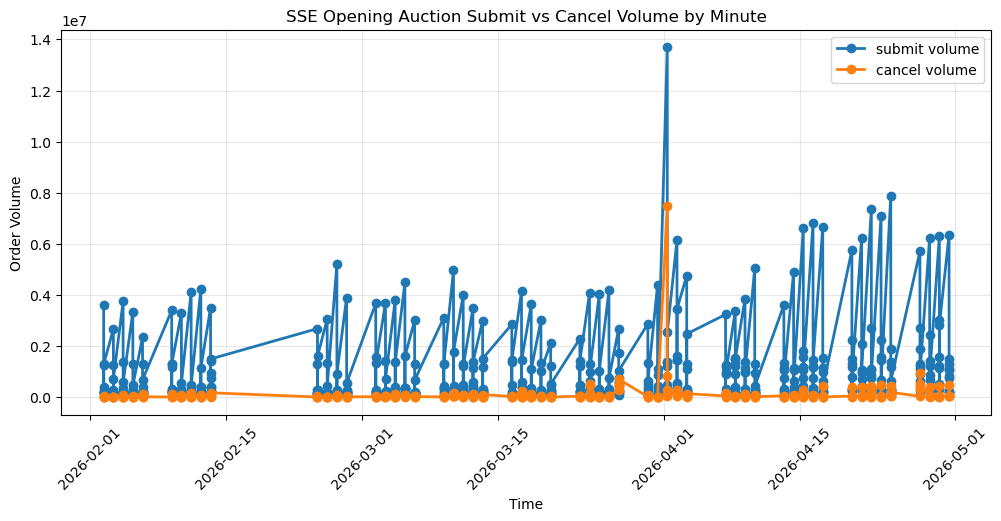

In [23]:
minute_action_flow = (
    qorder_sh
    .groupby(["minute", "action"])
    .agg(
        order_count=("order_no", "count"),
        order_volume=("order_volume", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(12, 5))

for action in ["submit", "cancel"]:
    temp = minute_action_flow[
        minute_action_flow["action"] == action
    ].sort_values("minute")

    plt.plot(
        temp["minute"],
        temp["order_volume"],
        marker="o",
        linewidth=2,
        label=f"{action} volume"
    )

plt.title("SSE Opening Auction Submit vs Cancel Volume by Minute")
plt.xlabel("Time")
plt.ylabel("Order Volume")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### 3.2.4.3 Average Minute Cancel Profile

,clock_minute,action,avg_order_count,avg_order_volume
0,09:15,cancel,2.531365,39258.302583
1,09:15,submit,91.304910,328539.378553
2,09:16,cancel,3.305699,34218.844560
3,09:16,submit,6.252951,101737.809444
4,09:17,cancel,3.163158,19123.110526


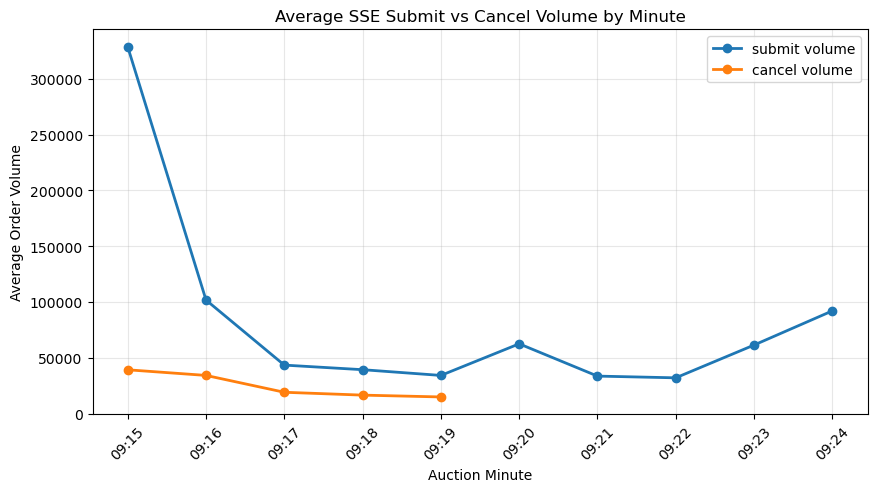

action,cancel,submit,cancel_rate
clock_minute,,,
09:15,39258.302583,328539.378553,0.119493
09:16,34218.844560,101737.809444,0.336343
09:17,19123.110526,43466.025194,0.439955
09:18,16570.429952,39354.734737,0.421053
09:19,14928.517730,34213.933775,0.436329
09:20,0.000000,62536.332155,0.000000
09:21,0.000000,33613.314554,0.000000
09:22,0.000000,32061.883576,0.000000
09:23,0.000000,61422.264755,0.000000


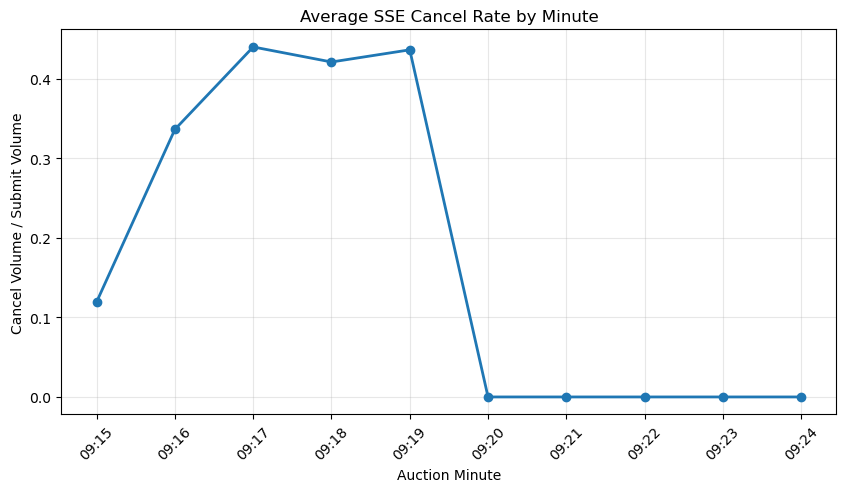

In [30]:
qorder_sh = qorder_sh.copy()

# Extract intraday minute only
qorder_sh["clock_minute"] = qorder_sh["datetime"].dt.strftime("%H:%M")

# Aggregate submit/cancel volume and count for each stock-day-minute
minute_action_profile = (
    qorder_sh
    .groupby(["date", "code", "clock_minute", "action"])
    .agg(
        order_count=("order_no", "count"),
        order_volume=("order_volume", "sum")
    )
    .reset_index()
)

# Average across stock-days
avg_minute_action_profile = (
    minute_action_profile
    .groupby(["clock_minute", "action"])
    .agg(
        avg_order_count=("order_count", "mean"),
        avg_order_volume=("order_volume", "mean")
    )
    .reset_index()
)

display(avg_minute_action_profile.head())

# Plot average submit vs cancel volume by minute
plt.figure(figsize=(10, 5))

for action in ["submit", "cancel"]:
    temp = avg_minute_action_profile[
        avg_minute_action_profile["action"] == action
    ].sort_values("clock_minute")

    plt.plot(
        temp["clock_minute"],
        temp["avg_order_volume"],
        marker="o",
        linewidth=2,
        label=f"{action} volume"
    )

plt.title("Average SSE Submit vs Cancel Volume by Minute")
plt.xlabel("Auction Minute")
plt.ylabel("Average Order Volume")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


minute_action_pivot = avg_minute_action_profile.pivot(
    index="clock_minute",
    columns="action",
    values="avg_order_volume"
).fillna(0)

if "submit" not in minute_action_pivot.columns:
    minute_action_pivot["submit"] = 0

if "cancel" not in minute_action_pivot.columns:
    minute_action_pivot["cancel"] = 0

minute_action_pivot["cancel_rate"] = np.where(
    minute_action_pivot["submit"] > 0,
    minute_action_pivot["cancel"] / minute_action_pivot["submit"],
    np.nan
)

display(minute_action_pivot)

plt.figure(figsize=(10, 5))

plt.plot(
    minute_action_pivot.index,
    minute_action_pivot["cancel_rate"],
    marker="o",
    linewidth=2
)

plt.title("Average SSE Cancel Rate by Minute")
plt.xlabel("Auction Minute")
plt.ylabel("Cancel Volume / Submit Volume")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

根据figure1，
##### Observation
平均每分钟的订单流呈现明显的阶段性特征。
集合竞价开始后的第一个分钟（09:15）出现全天最高的提交委托量，平均约为 32.9 万股；与此同时，撤单量约为 3.9 万股，仅占提交委托量的一小部分。
随后，提交委托量迅速下降，在 09:17 至 09:22 之间保持相对稳定。
临近集合竞价结束时（09:23–09:24），提交委托量再次明显增加，而撤单量几乎降至零。
##### Analysis
结果表明，集合竞价期间的订单流具有明显的时间分层（Time Clustering）。
市场参与者主要在两个时间段集中提交订单：一是在竞价开始时快速建立初始订单簿；二是在竞价结束前，根据市场已有信息完成最终报价。
相比之下，撤单行为主要发生在集合竞价开始后的几分钟内，而在最后阶段几乎完全消失。
这种现象说明，市场参与者更倾向于在竞价早期修改或撤销已有委托，而在最终价格形成前，更多的是新增订单而非撤销订单。
##### Inference
订单提交与撤销在时间上的明显差异说明，两类行为承担了不同的市场功能。
Submit Volume 更能反映新增流动性的注入，而 Cancel Volume 更能反映市场参与者对于价格预期的修正过程。
因此，两类变量均具有潜在的信息含量，可以分别构造成描述流动性供给和订单修正行为的特征，用于后续开盘价格预测模型。

根据figure2，
##### Observation
撤单率（Cancel Rate）在集合竞价开始后的几分钟内快速上升。
09:15 时撤单率约为 12%，随后持续上升，并在 09:17 至 09:19 达到约 42%–44% 的峰值。
值得注意的是，自 09:20 起，平均撤单率迅速下降至接近零，并持续保持至集合竞价结束。
##### Analysis
撤单率在 09:20 后突然降为零，并不是因为市场参与者完全停止了订单调整，而更可能反映了集合竞价制度本身的交易规则。
从订单数据来看，大部分撤单行为集中发生于竞价开始后的早期阶段，而临近开盘时，市场主要表现为新增委托而非撤销委托。
这说明，在最终价格形成阶段，市场参与者更关注将最终交易意图提交至订单簿，而不是继续频繁修改已有订单。
##### Inference
撤单率体现了市场参与者调整订单策略的活跃程度，可以作为衡量市场不确定性的一个代理变量。
当撤单率较高时，通常意味着市场对于合理开盘价格尚未形成一致预期；而撤单率逐渐降低，则可能意味着市场报价趋于稳定。
因此，Early-stage Cancel Rate、Maximum Cancel Rate 以及 Average Cancel Rate 等指标，都具有进一步验证其预测能力的价值。

### 3.4.7 Last-minute Order Concentration

C:\Users\work\AppData\Local\Temp\ipykernel_19872\3471951629.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,code,date,total_submit_volume,last_minute_submit_volume,total_submit_count,last_minute_submit_count,last_minute_buy_submit_volume,last_minute_sell_submit_volume,last_minute_submit_volume_share,last_minute_submit_count_share,last_minute_submit_imbalance
0,019639.SH,2026-02-02,1000,0,1,0,0,0,0.0,0.0,NaN
1,019639.SH,2026-02-06,1000,0,1,0,0,0,0.0,0.0,NaN
2,019639.SH,2026-02-09,1000,0,1,0,0,0,0.0,0.0,NaN
3,019639.SH,2026-02-11,1000,0,1,0,0,0,0.0,0.0,NaN
4,019639.SH,2026-02-13,1000,0,1,0,0,0,0.0,0.0,NaN


,last_minute_submit_volume_share,last_minute_submit_count_share,last_minute_submit_imbalance
count,791.000000,791.000000,688.000000
mean,0.095134,0.109583,0.251732
std,0.137484,0.097514,0.722308
min,0.000000,0.000000,-1.000000
25%,0.000423,0.052632,-0.429493
50%,0.038438,0.096774,0.359637
75%,0.147371,0.150803,1.000000
max,1.000000,1.000000,1.000000


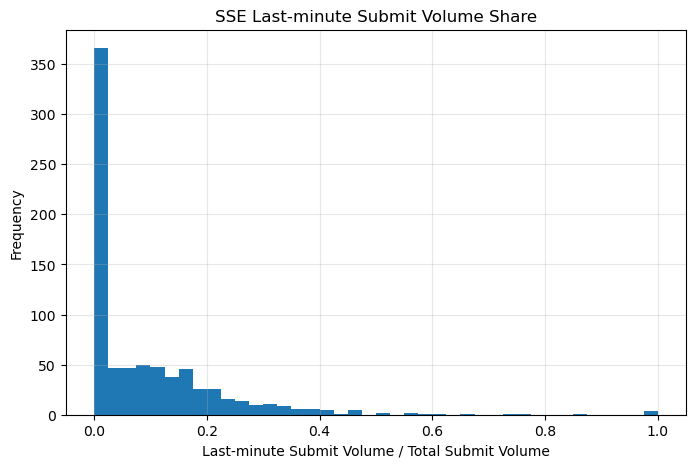

In [31]:
last_minute_start = pd.to_datetime("09:24:00").time()
auction_end = pd.to_datetime("09:25:00").time()

qorder_sh["is_last_minute"] = (
    (qorder_sh["datetime"].dt.time >= last_minute_start) &
    (qorder_sh["datetime"].dt.time <= auction_end)
)

last_minute_order_features = (
    qorder_sh
    .groupby(["code", "date"])
    .apply(
        lambda g: pd.Series({
            "total_submit_volume": g.loc[
                g["action"] == "submit", "order_volume"
            ].sum(),

            "last_minute_submit_volume": g.loc[
                (g["action"] == "submit") &
                (g["is_last_minute"]),
                "order_volume"
            ].sum(),

            "total_submit_count": (
                g["action"] == "submit"
            ).sum(),

            "last_minute_submit_count": (
                (g["action"] == "submit") &
                (g["is_last_minute"])
            ).sum(),

            "last_minute_buy_submit_volume": g.loc[
                (g["action"] == "submit") &
                (g["is_last_minute"]) &
                (g["side"] == "buy"),
                "order_volume"
            ].sum(),

            "last_minute_sell_submit_volume": g.loc[
                (g["action"] == "submit") &
                (g["is_last_minute"]) &
                (g["side"] == "sell"),
                "order_volume"
            ].sum(),
        })
    )
    .reset_index()
)

last_minute_order_features["last_minute_submit_volume_share"] = np.where(
    last_minute_order_features["total_submit_volume"] > 0,
    last_minute_order_features["last_minute_submit_volume"]
    / last_minute_order_features["total_submit_volume"],
    np.nan
)

last_minute_order_features["last_minute_submit_count_share"] = np.where(
    last_minute_order_features["total_submit_count"] > 0,
    last_minute_order_features["last_minute_submit_count"]
    / last_minute_order_features["total_submit_count"],
    np.nan
)

last_minute_order_features["last_minute_submit_imbalance"] = np.where(
    (
        last_minute_order_features["last_minute_buy_submit_volume"]
        + last_minute_order_features["last_minute_sell_submit_volume"]
    ) > 0,
    (
        last_minute_order_features["last_minute_buy_submit_volume"]
        - last_minute_order_features["last_minute_sell_submit_volume"]
    )
    /
    (
        last_minute_order_features["last_minute_buy_submit_volume"]
        + last_minute_order_features["last_minute_sell_submit_volume"]
    ),
    np.nan
)

display(last_minute_order_features.head())

display(
    last_minute_order_features[
        [
            "last_minute_submit_volume_share",
            "last_minute_submit_count_share",
            "last_minute_submit_imbalance"
        ]
    ].describe()
)

plt.figure(figsize=(8, 5))
plt.hist(
    last_minute_order_features["last_minute_submit_volume_share"].dropna(),
    bins=40
)
plt.title("SSE Last-minute Submit Volume Share")
plt.xlabel("Last-minute Submit Volume / Total Submit Volume")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

##### Observation
最后一分钟委托量占比（Last-minute Submit Volume Share）呈现明显的右偏分布（right-skewed distribution）。
样本中大部分股票交易日的最后一分钟委托量占比集中在较低区间，中位数仅为约 3.8%，说明对于大多数交易日而言，最后一分钟并非主要的委托发生阶段。
然而，分布存在明显的长尾现象。约 25% 的样本最后一分钟委托量占比超过 14.7%，部分交易日甚至达到 100%，即全部委托均发生在最后一分钟。
##### Inference
最后一分钟委托占比能够反映订单流在时间维度上的集中程度（Temporal Concentration）。
相比于总成交量或总订单数量，这一指标更直接描述了投资者是否倾向于将订单延迟至竞价结束前提交，因此能够捕捉集合竞价阶段价格发现过程中的行为特征。
因此，Last-minute Submit Volume Share 可以作为一个重要的微观结构特征，在后续 Feature Validation 中进一步检验其与集合竞价收益率及开盘价格之间的关系。

由于均值（9.5%）明显高于中位数（3.8%），说明最后一分钟订单集中现象主要由少数高集中度交易日驱动，而不是所有交易日普遍存在的行为。

### 3.2.5 Effective Order Lifetime

,code,date,order_no,submit_time,side,submit_price,submit_volume,cancel_time,cancel_volume,is_cancelled,lifetime_seconds,auction_end_datetime,effective_end_time,effective_lifetime_seconds
0,019639.SH,2026-02-02,29756,2026-02-02 09:15:00.852,buy,1055440.0,1000,NaT,NaN,False,NaN,2026-02-02 09:25:00,2026-02-02 09:25:00,599.148
1,019639.SH,2026-02-06,21486,2026-02-06 09:15:00.660,buy,1056390.0,1000,NaT,NaN,False,NaN,2026-02-06 09:25:00,2026-02-06 09:25:00,599.340
2,019639.SH,2026-02-09,44174,2026-02-09 09:15:04.410,buy,1056570.0,1000,NaT,NaN,False,NaN,2026-02-09 09:25:00,2026-02-09 09:25:00,595.590
3,019639.SH,2026-02-11,18356,2026-02-11 09:15:00.578,buy,1057200.0,1000,NaT,NaN,False,NaN,2026-02-11 09:25:00,2026-02-11 09:25:00,599.422
4,019639.SH,2026-02-13,18619,2026-02-13 09:15:00.531,buy,1058000.0,1000,NaT,NaN,False,NaN,2026-02-13 09:25:00,2026-02-13 09:25:00,599.469


,lifetime_seconds,effective_lifetime_seconds,submit_volume
count,3329.000000,128057.000000,128057.000000
mean,67.176193,397.563393,4186.610650
std,80.066723,232.388160,24877.396325
min,0.000000,0.000000,1.000000
25%,4.520000,154.730000,200.000000
50%,29.640000,575.940000,500.000000
75%,108.520000,590.350000,2000.000000
max,295.990000,600.000000,1000000.000000


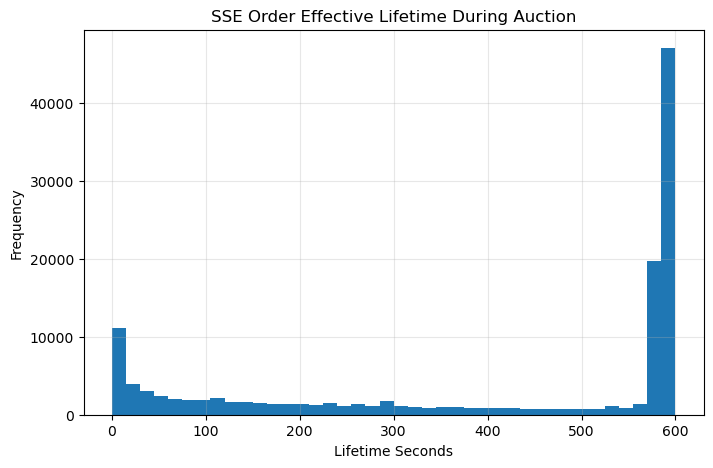

,code,date,avg_order_lifetime_seconds,median_order_lifetime_seconds,cancel_rate_by_order,avg_cancelled_lifetime_seconds
0,019639.SH,2026-02-02,599.148,599.148,0.0,NaN
1,019639.SH,2026-02-06,599.340,599.340,0.0,NaN
2,019639.SH,2026-02-09,595.590,595.590,0.0,NaN
3,019639.SH,2026-02-11,599.422,599.422,0.0,NaN
4,019639.SH,2026-02-13,599.469,599.469,0.0,NaN


In [39]:
submit_orders = qorder_sh[
    qorder_sh["action"] == "submit"
][
    ["code", "date", "order_no", "datetime", "side", "order_price", "order_volume"]
].copy()

submit_orders = submit_orders.rename(
    columns={
        "datetime": "submit_time",
        "order_price": "submit_price",
        "order_volume": "submit_volume"
    }
)

# Cancel records
cancel_orders = qorder_sh[
    qorder_sh["action"] == "cancel"
][
    ["code", "date", "order_no", "datetime", "order_volume"]
].copy()

cancel_orders = cancel_orders.rename(
    columns={
        "datetime": "cancel_time",
        "order_volume": "cancel_volume"
    }
)

# Match submit and cancel by order_no
order_life = submit_orders.merge(
    cancel_orders,
    on=["code", "date", "order_no"],
    how="left"
)

order_life["is_cancelled"] = order_life["cancel_time"].notna()

order_life["lifetime_seconds"] = (
    order_life["cancel_time"] - order_life["submit_time"]
).dt.total_seconds()

# If an order is not cancelled, treat it as surviving until auction end
auction_end_time = pd.to_datetime("09:25:00").time()

order_life["auction_end_datetime"] = order_life["date"].apply(
    lambda d: pd.Timestamp.combine(
        pd.to_datetime(d).date(),
        auction_end_time
    )
)

order_life["effective_end_time"] = order_life["cancel_time"].fillna(
    order_life["auction_end_datetime"]
)

order_life["effective_lifetime_seconds"] = (
    order_life["effective_end_time"] - order_life["submit_time"]
).dt.total_seconds()

# Remove impossible values
order_life.loc[
    order_life["effective_lifetime_seconds"] < 0,
    "effective_lifetime_seconds"
] = np.nan

display(order_life.head())

display(
    order_life[
        [
            "is_cancelled",
            "lifetime_seconds",
            "effective_lifetime_seconds",
            "submit_volume"
        ]
    ].describe()
)

plt.figure(figsize=(8, 5))
plt.hist(
    order_life["effective_lifetime_seconds"].dropna(),
    bins=40
)
plt.title("SSE Order Effective Lifetime During Auction")
plt.xlabel("Lifetime Seconds")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# Daily lifetime features
lifetime_features = (
    order_life
    .groupby(["code", "date"])
    .agg(
        avg_order_lifetime_seconds=("effective_lifetime_seconds", "mean"),
        median_order_lifetime_seconds=("effective_lifetime_seconds", "median"),
        cancel_rate_by_order=("is_cancelled", "mean"),
        avg_cancelled_lifetime_seconds=("lifetime_seconds", "mean")
    )
    .reset_index()
)

display(lifetime_features.head())

##### Observation
订单有效存续时间（Effective Lifetime）呈现明显的双峰分布（Bimodal Distribution）。
大量订单的有效生命周期集中在约590–600秒附近，即订单在集合竞价开始后不久便提交，并一直保留至开盘撮合.
与此同时，在0秒附近也存在另一明显峰值，说明另一部分订单是在集合竞价结束前才被提交，仅在订单簿中停留极短时间。
相比之下，中间生命周期的订单数量相对较少。
##### Analysis
双峰结构说明市场参与者主要采用两种不同的委托策略。
第一类投资者倾向于在集合竞价开始时尽早提交订单，并持续保留至开盘，以确保参与最终撮合。
另一类投资者则倾向于等待更多市场信息，在集合竞价即将结束时才提交最终订单，以降低报价信息暴露（Information Leakage）的风险，并根据市场变化调整最终报价。
相比之下，在集合竞价中途持续新增订单的行为相对较少，因此形成了生命周期中段较低的频率。
##### Inference
订单有效生命周期反映了投资者的下单时机选择（Order Timing Preference）。
较长的有效生命周期意味着投资者更倾向于尽早提供流动性，而较短的生命周期则反映了延迟下单策略。
因此，Average Effective Lifetime、Median Effective Lifetime 以及 Long-Lifetime Order Ratio 等指标均可以作为描述订单时间分布的重要微观结构特征，并进一步检验其是否具有预测开盘价格形成过程的能力。

The bimodal distribution suggests that traders generally follow either an early-submission strategy or a last-minute submission strategy, rather than continuously submitting orders throughout the auction period.

### 3.2.6 Daily Feature Construction

In [33]:
daily_orderflow_base = (
    qorder_sh
    .groupby(["code", "date"])
    .apply(
        lambda g: pd.Series({
            # order count
            "n_orders": len(g),
            "n_submit_orders": (g["action"] == "submit").sum(),
            "n_cancel_orders": (g["action"] == "cancel").sum(),

            # submit volume
            "buy_submit_volume": g.loc[
                (g["action"] == "submit") &
                (g["side"] == "buy"),
                "order_volume"
            ].sum(),

            "sell_submit_volume": g.loc[
                (g["action"] == "submit") &
                (g["side"] == "sell"),
                "order_volume"
            ].sum(),

            # cancel volume
            "buy_cancel_volume": g.loc[
                (g["action"] == "cancel") &
                (g["side"] == "buy"),
                "order_volume"
            ].sum(),

            "sell_cancel_volume": g.loc[
                (g["action"] == "cancel") &
                (g["side"] == "sell"),
                "order_volume"
            ].sum(),

            # order size
            "avg_submit_size": g.loc[
                g["action"] == "submit",
                "order_volume"
            ].mean(),

            "median_submit_size": g.loc[
                g["action"] == "submit",
                "order_volume"
            ].median(),

            "max_submit_size": g.loc[
                g["action"] == "submit",
                "order_volume"
            ].max(),

            # price
            "avg_submit_price": g.loc[
                g["action"] == "submit",
                "order_price"
            ].mean(),

            "buy_avg_submit_price": g.loc[
                (g["action"] == "submit") &
                (g["side"] == "buy"),
                "order_price"
            ].mean(),

            "sell_avg_submit_price": g.loc[
                (g["action"] == "submit") &
                (g["side"] == "sell"),
                "order_price"
            ].mean(),
        })
    )
    .reset_index()
)

daily_orderflow_base["total_submit_volume"] = (
    daily_orderflow_base["buy_submit_volume"]
    + daily_orderflow_base["sell_submit_volume"]
)

daily_orderflow_base["total_cancel_volume"] = (
    daily_orderflow_base["buy_cancel_volume"]
    + daily_orderflow_base["sell_cancel_volume"]
)

daily_orderflow_base["submit_imbalance"] = np.where(
    daily_orderflow_base["total_submit_volume"] > 0,
    (
        daily_orderflow_base["buy_submit_volume"]
        - daily_orderflow_base["sell_submit_volume"]
    ) / daily_orderflow_base["total_submit_volume"],
    np.nan
)

daily_orderflow_base["cancel_volume_ratio"] = np.where(
    daily_orderflow_base["total_submit_volume"] > 0,
    daily_orderflow_base["total_cancel_volume"]
    / daily_orderflow_base["total_submit_volume"],
    np.nan
)

daily_orderflow_base["cancel_count_ratio"] = np.where(
    daily_orderflow_base["n_submit_orders"] > 0,
    daily_orderflow_base["n_cancel_orders"]
    / daily_orderflow_base["n_submit_orders"],
    np.nan
)

daily_orderflow_base["net_buy_volume"] = (
    daily_orderflow_base["buy_submit_volume"]
    - daily_orderflow_base["buy_cancel_volume"]
)

daily_orderflow_base["net_sell_volume"] = (
    daily_orderflow_base["sell_submit_volume"]
    - daily_orderflow_base["sell_cancel_volume"]
)

daily_orderflow_base["net_order_imbalance"] = np.where(
    (
        daily_orderflow_base["net_buy_volume"]
        + daily_orderflow_base["net_sell_volume"]
    ) > 0,
    (
        daily_orderflow_base["net_buy_volume"]
        - daily_orderflow_base["net_sell_volume"]
    )
    /
    (
        daily_orderflow_base["net_buy_volume"]
        + daily_orderflow_base["net_sell_volume"]
    ),
    np.nan
)

# Merge last-minute and lifetime features
feature_sse_orderflow = daily_orderflow_base.merge(
    last_minute_order_features[
        [
            "code",
            "date",
            "last_minute_submit_volume_share",
            "last_minute_submit_count_share",
            "last_minute_submit_imbalance"
        ]
    ],
    on=["code", "date"],
    how="left"
)

feature_sse_orderflow = feature_sse_orderflow.merge(
    lifetime_features,
    on=["code", "date"],
    how="left"
)

feature_sse_orderflow["exchange"] = "SSE"
feature_sse_orderflow["month"] = (
    feature_sse_orderflow["date"]
    .dt.to_period("M")
    .astype(str)
)

feature_sse_orderflow = feature_sse_orderflow.replace(
    [np.inf, -np.inf],
    np.nan
)

print("feature_sse_orderflow shape:", feature_sse_orderflow.shape)

display(feature_sse_orderflow.head())

display(feature_sse_orderflow.isna().sum())

feature_sse_orderflow shape: (791, 32)


C:\Users\work\AppData\Local\Temp\ipykernel_19872\1521510859.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,code,date,n_orders,n_submit_orders,n_cancel_orders,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,avg_submit_size,...,net_order_imbalance,last_minute_submit_volume_share,last_minute_submit_count_share,last_minute_submit_imbalance,avg_order_lifetime_seconds,median_order_lifetime_seconds,cancel_rate_by_order,avg_cancelled_lifetime_seconds,exchange,month
0,019639.SH,2026-02-02,1.0,1.0,0.0,1000.0,0.0,0.0,0.0,1000.0,...,1.0,0.0,0.0,NaN,599.148,599.148,0.0,NaN,SSE,2026-02
1,019639.SH,2026-02-06,1.0,1.0,0.0,1000.0,0.0,0.0,0.0,1000.0,...,1.0,0.0,0.0,NaN,599.340,599.340,0.0,NaN,SSE,2026-02
2,019639.SH,2026-02-09,1.0,1.0,0.0,1000.0,0.0,0.0,0.0,1000.0,...,1.0,0.0,0.0,NaN,595.590,595.590,0.0,NaN,SSE,2026-02
3,019639.SH,2026-02-11,1.0,1.0,0.0,1000.0,0.0,0.0,0.0,1000.0,...,1.0,0.0,0.0,NaN,599.422,599.422,0.0,NaN,SSE,2026-02
4,019639.SH,2026-02-13,1.0,1.0,0.0,1000.0,0.0,0.0,0.0,1000.0,...,1.0,0.0,0.0,NaN,599.469,599.469,0.0,NaN,SSE,2026-02


code                                 0
date                                 0
n_orders                             0
n_submit_orders                      0
n_cancel_orders                      0
buy_submit_volume                    0
sell_submit_volume                   0
buy_cancel_volume                    0
sell_cancel_volume                   0
avg_submit_size                      0
median_submit_size                   0
max_submit_size                      0
avg_submit_price                     0
buy_avg_submit_price                28
sell_avg_submit_price               15
total_submit_volume                  0
total_cancel_volume                  0
submit_imbalance                     0
cancel_volume_ratio                  0
cancel_count_ratio                   0
net_buy_volume                       0
net_sell_volume                      0
net_order_imbalance                  0
last_minute_submit_volume_share      0
last_minute_submit_count_share       0
last_minute_submit_imbala

#### Summary Statistics

,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,submit_imbalance,net_order_imbalance,cancel_volume_ratio,cancel_count_ratio,avg_submit_size,median_submit_size,max_submit_size,last_minute_submit_volume_share,last_minute_submit_count_share,last_minute_submit_imbalance,avg_order_lifetime_seconds,median_order_lifetime_seconds,cancel_rate_by_order
count,791.000000,791.000000,791.000000,7.910000e+02,7.910000e+02,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,688.000000,791.000000,791.000000,791.000000
mean,166.101138,161.892541,4.208597,6.777810e+05,3.605126e+04,-0.008366,-0.014905,0.032901,0.027157,10011.547562,2363.408976,153804.094817,0.095134,0.109583,0.251732,430.758836,522.512772,0.027157
std,228.501707,222.782234,11.781587,9.639815e+05,3.178532e+05,0.500144,0.510948,0.081124,0.058792,14008.839762,4001.988121,213263.569773,0.137484,0.097514,0.722308,84.946751,115.750699,0.058792
min,1.000000,1.000000,0.000000,1.000000e+03,0.000000e+00,-1.000000,-1.000000,0.000000,0.000000,276.387597,100.000000,1000.000000,0.000000,0.000000,-1.000000,7.694000,1.220000,0.000000
25%,27.000000,27.000000,0.000000,8.257800e+04,0.000000e+00,-0.401083,-0.426727,0.000000,0.000000,1914.624912,400.000000,12250.000000,0.000423,0.052632,-0.429493,384.802000,510.507500,0.000000
50%,42.000000,42.000000,2.000000,3.537000e+05,3.000000e+02,-0.047619,-0.047619,0.002627,0.009901,4733.178571,1000.000000,56200.000000,0.038438,0.096774,0.359637,430.202632,578.055000,0.009901
75%,252.000000,248.500000,4.000000,7.797500e+05,1.075000e+04,0.374709,0.397334,0.023160,0.033216,10000.000000,1975.000000,225250.000000,0.147371,0.150803,1.000000,469.634618,584.232500,0.033216
max,1703.000000,1583.000000,178.000000,1.323930e+07,8.595800e+06,1.000000,1.000000,0.655826,0.750000,95811.111111,62000.000000,1000000.000000,1.000000,1.000000,1.000000,599.960000,599.960000,0.750000


,month,n_stock_days,n_stocks,n_days,avg_orders,avg_submit_volume,avg_cancel_ratio,avg_submit_imbalance,avg_net_imbalance,avg_last_minute_share,avg_lifetime
0,2026-02,199,15,14,166.211055,485349.412060,0.027482,-0.045537,-0.059427,0.106607,440.484827
1,2026-03,313,15,22,154.738019,518396.031949,0.030829,-0.077821,-0.079411,0.106055,429.106487
2,2026-04,279,14,21,178.770609,993843.401434,0.039090,0.096066,0.089217,0.074698,425.675370


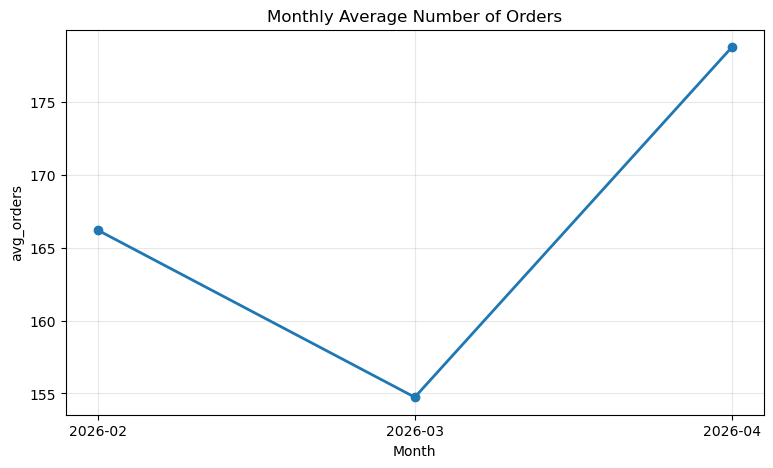

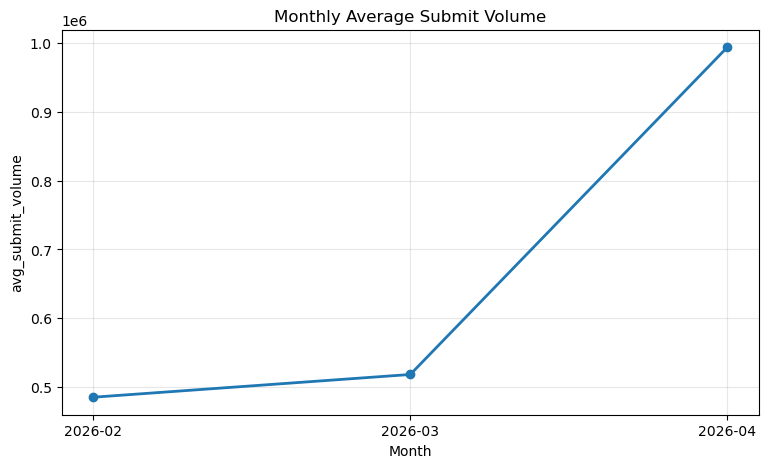

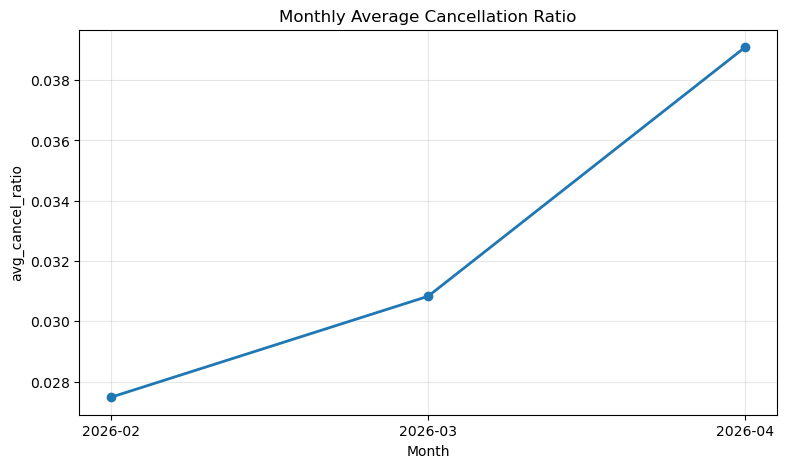

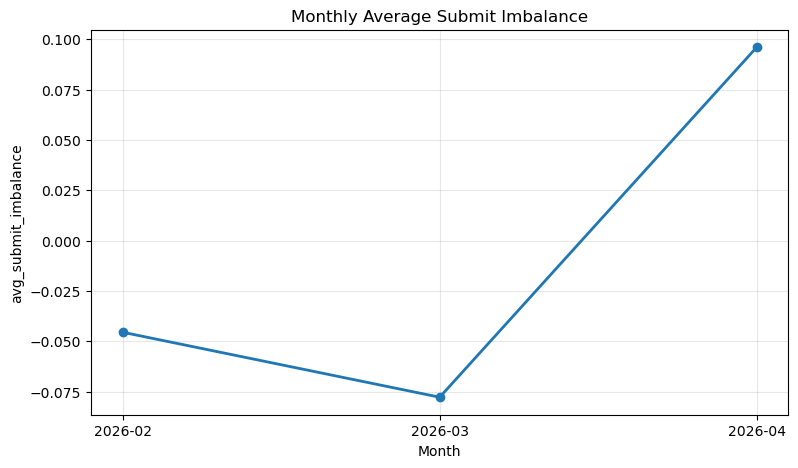

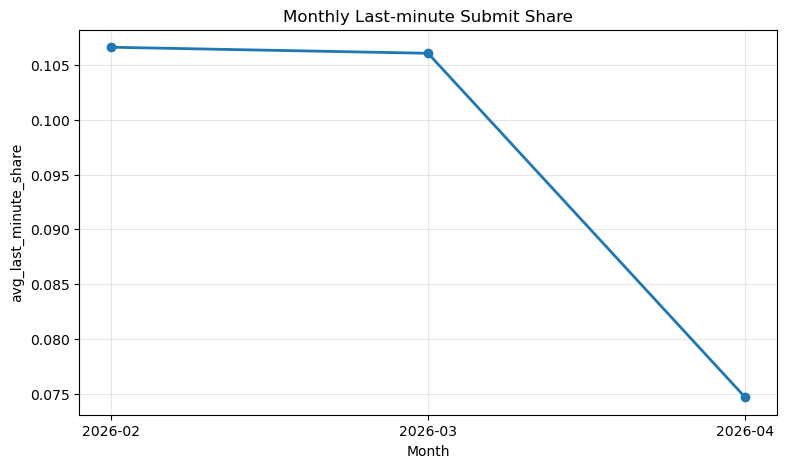

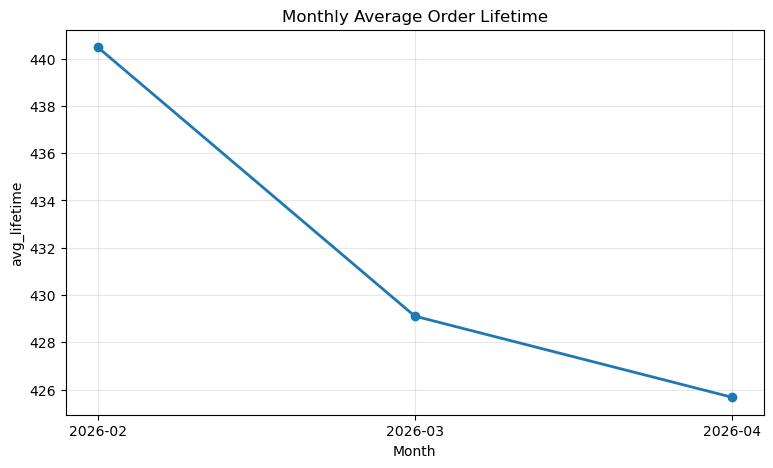

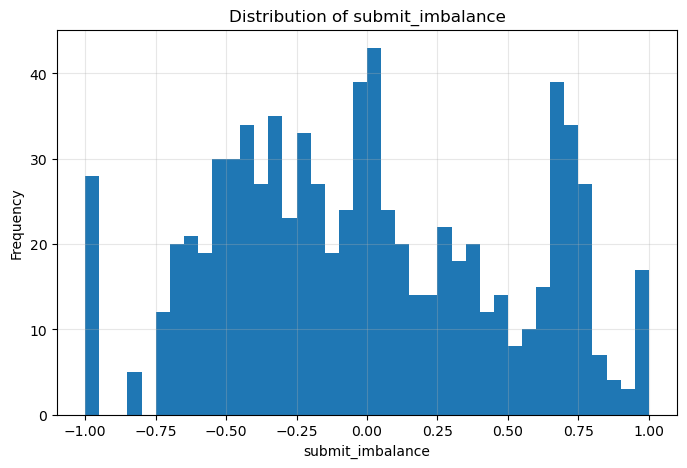

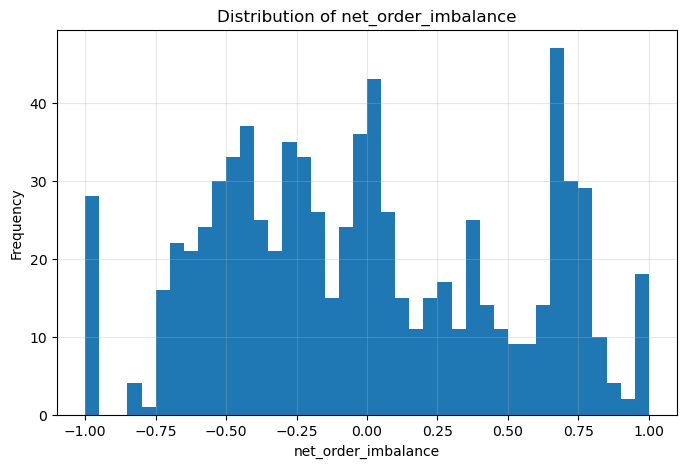

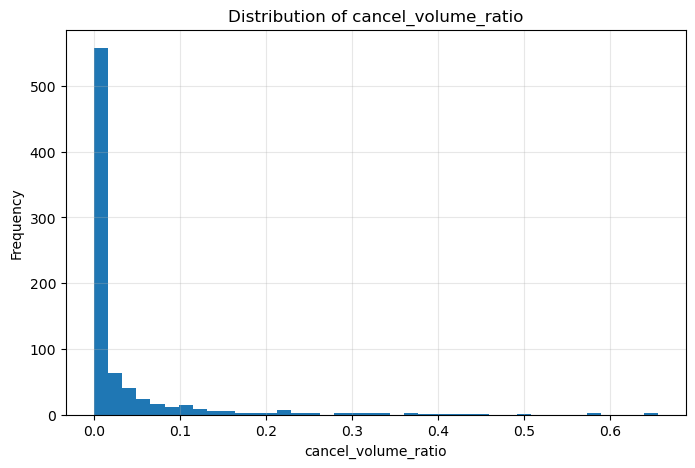

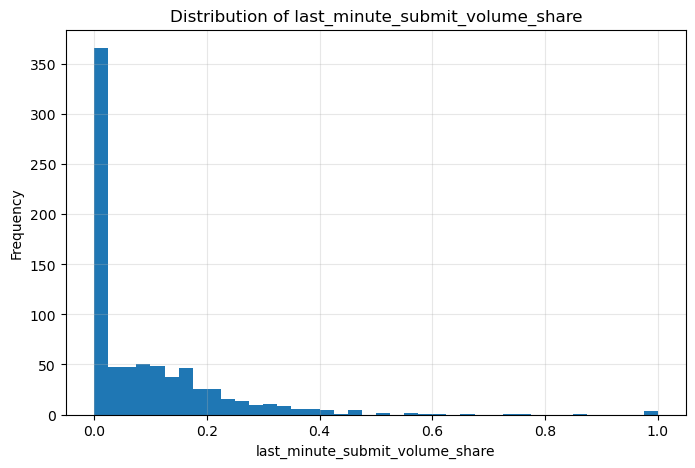

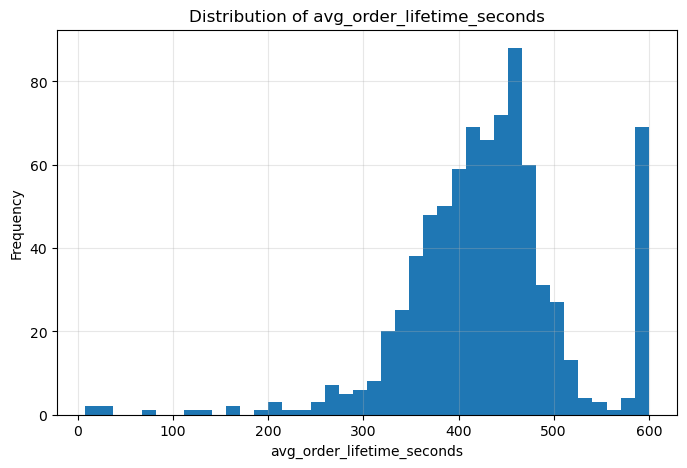

In [34]:
sse_core_features = [
    "n_orders",
    "n_submit_orders",
    "n_cancel_orders",
    "total_submit_volume",
    "total_cancel_volume",
    "submit_imbalance",
    "net_order_imbalance",
    "cancel_volume_ratio",
    "cancel_count_ratio",
    "avg_submit_size",
    "median_submit_size",
    "max_submit_size",
    "last_minute_submit_volume_share",
    "last_minute_submit_count_share",
    "last_minute_submit_imbalance",
    "avg_order_lifetime_seconds",
    "median_order_lifetime_seconds",
    "cancel_rate_by_order"
]

display(
    feature_sse_orderflow[sse_core_features].describe()
)

# Monthly summary
sse_monthly_summary = (
    feature_sse_orderflow
    .groupby("month")
    .agg(
        n_stock_days=("code", "count"),
        n_stocks=("code", "nunique"),
        n_days=("date", "nunique"),

        avg_orders=("n_orders", "mean"),
        avg_submit_volume=("total_submit_volume", "mean"),
        avg_cancel_ratio=("cancel_volume_ratio", "mean"),
        avg_submit_imbalance=("submit_imbalance", "mean"),
        avg_net_imbalance=("net_order_imbalance", "mean"),
        avg_last_minute_share=("last_minute_submit_volume_share", "mean"),
        avg_lifetime=("avg_order_lifetime_seconds", "mean")
    )
    .reset_index()
)

display(sse_monthly_summary)

# Plot monthly SSE order-flow features
sse_monthly_metrics = {
    "avg_orders": "Monthly Average Number of Orders",
    "avg_submit_volume": "Monthly Average Submit Volume",
    "avg_cancel_ratio": "Monthly Average Cancellation Ratio",
    "avg_submit_imbalance": "Monthly Average Submit Imbalance",
    "avg_last_minute_share": "Monthly Last-minute Submit Share",
    "avg_lifetime": "Monthly Average Order Lifetime"
}

for metric, title in sse_monthly_metrics.items():
    plt.figure(figsize=(9, 5))

    plt.plot(
        sse_monthly_summary["month"],
        sse_monthly_summary[metric],
        marker="o",
        linewidth=2
    )

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel(metric)
    plt.grid(alpha=0.3)
    plt.show()

# Feature distributions
distribution_features = [
    "submit_imbalance",
    "net_order_imbalance",
    "cancel_volume_ratio",
    "last_minute_submit_volume_share",
    "avg_order_lifetime_seconds"
]

for col in distribution_features:
    plt.figure(figsize=(8, 5))

    plt.hist(
        feature_sse_orderflow[col].dropna(),
        bins=40
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

##### Observation
共构建 791 个股票-交易日（stock-day）样本，每个样本包含订单活跃度（Activity）、订单规模（Size）、订单流（Order Flow）以及时间行为（Timing）等多个微观结构特征。
从描述性统计来看，不同特征呈现出明显不同的分布特征。
首先，订单活跃度存在较大的横截面差异。平均每个股票交易日产生约166笔订单，但标准差达到228笔，最大值达到1703笔，说明不同股票和不同交易日之间的订单活跃程度存在显著差异。
其次，订单规模呈现明显右偏分布。平均提交订单规模约为10012股，而中位数仅为2363股，最大订单规模达到100万股，说明少数超大订单显著拉高了整体均值。
在订单流方向上，Submit Imbalance 与 Net Order Imbalance 的均值均接近于零（分别为-0.008和-0.015），说明整体样本不存在持续性的买卖方向偏置，但标准差均约为0.5，表明不同交易日之间存在较大的方向性波动。
时间行为方面，最后一分钟委托量占比平均约为9.5%，但中位数仅为3.8%，说明订单集中提交现象主要由少数交易日驱动。与此同时，订单有效生命周期平均约431秒，中位数约523秒，大多数订单在集合竞价早期便已进入订单簿。
##### Analysis
整体来看，各类微观结构特征均具有较高的横截面离散性（Cross-sectional Dispersion），说明不同股票交易日之间的订单行为存在明显差异，这为后续预测模型提供了较丰富的信息来源。
订单数量、订单规模以及总提交量均表现出明显的长尾分布（Long-tailed Distribution），反映出市场活跃程度具有高度异质性。少数高活跃交易日贡献了大量订单和成交意愿，而多数交易日则保持相对平稳。
订单流方向指标（Submit Imbalance、Net Order Imbalance）虽然整体均值接近于零，但标准差较大，说明市场整体不存在长期单边偏向，但在具体交易日内仍可能出现明显的买卖力量失衡，这种失衡可能直接影响集合竞价价格形成。
时间维度特征同样体现出较强的信息含量。订单生命周期整体偏长，说明多数投资者倾向于较早提交订单，并持续保留至开盘；与此同时，最后一分钟订单集中度具有明显右偏特征，仅在部分交易日出现极端集中提交行为，反映出不同市场环境下存在不同的下单策略。
##### Monthly Observation
订单行为在不同月份之间存在一定变化。
2026年4月的平均提交量明显高于2月和3月，平均提交成交量接近100万股，约为2月份的两倍。同时，撤单比例也由2月份的2.7%上升至4月份的3.9%。
相比之下，订单生命周期则呈现缓慢下降趋势，由2月份约440秒下降至4月份约426秒，说明随着时间推移，市场参与者略微倾向于延后提交订单。
然而，最后一分钟提交占比变化相对有限，整体维持在7%至11%之间，表明最后一分钟集中提交虽然存在，但并不是不同月份之间最主要的变化来源。

## 3.3 Cross Exchange Comparison

### 3.3.1 Data Structure Comparison
| Aspect | Shenzhen Exchange (SZSE) | Shanghai Exchange (SSE) |
|----------|--------------------------|--------------------------|
| Dataset Used | qtick | qorder |
| Data Type | Snapshot Data | Order Event Data |
| Observation Unit | Market Snapshot | Individual Order |
| Time Resolution | Periodic snapshots | Every submitted/cancelled order |
| Available Information | Best bid/ask, latest price, cumulative volume | Order direction, order price, order volume, submit/cancel events |
| Suitable Analysis | Price formation | Order flow behavior |
| Strength | Direct observation of auction price dynamics | Rich microstructure and investor behavior |
| Limitation | Cannot observe individual orders | Cannot directly reconstruct auction price path |

##### Observation
深交所与上交所数据结构存在明显差异。
深交所 qtick 记录的是市场快照（Snapshot），能够直接观察集合竞价期间价格、盘口及成交量的动态变化，因此更适合分析价格发现（Price Discovery）过程。
相比之下，上交所 qorder 记录的是逐笔委托事件（Order Events），能够完整刻画订单提交、撤单及订单生命周期等微观结构行为，因此更适合研究订单形成（Order Formation）机制。

### 3.3.2 Feature Comparison
| Research Dimension | Shenzhen (qtick) | Shanghai (qorder) |
|--------------------|------------------|-------------------|
| Auction Return | ✓ | × |
| Price Range | ✓ | × |
| Price Volatility | ✓ | × |
| Turning Points | ✓ | × |
| Buy/Sell Imbalance | Partial | ✓ |
| Submit Volume | × | ✓ |
| Cancel Ratio | × | ✓ |
| Order Lifetime | × | ✓ |
| Last-minute Concentration | Partial | ✓ |
| Daily Feature Construction | ✓ | ✓ |

##### Analysis
两类数据提供了不同层面的市场信息。
基于 qtick，可以直接观察集合竞价价格路径，并构建价格波动、价格区间、趋势变化等价格特征，用于分析价格形成过程。
而基于 qorder，可以进一步观察订单提交、撤单、买卖方向以及订单生命周期等行为特征，从微观层面解释价格形成背后的订单流机制。
因此，两类数据并不是相互替代，而是相互补充。


### 3.3.3 Key Findings
#### Finding 1: Auction prices are formed through dynamic order interactions.
在深交所数据中，集合竞价价格普遍经历多次波动，价格路径表现出明显的上下调整和方向切换。
与此同时，上交所订单数据显示，买卖双方持续提交和调整订单，订单流方向不断变化。
两类数据共同说明，集合竞价价格并非一次形成，而是在持续订单交互过程中逐步收敛至最终开盘价格。
#### Finding 2: Order timing is an important behavioral characteristic.
订单流分析显示，大部分订单集中发生于集合竞价开始阶段和结束前阶段。
特别是在最后一分钟，部分交易日出现明显的订单集中提交现象，而订单生命周期则呈现双峰分布，反映出投资者主要采用“提前提交”与“延迟提交”两类策略。
因此，订单时间行为（Order Timing）可能是影响开盘价格形成的重要因素。
#### Finding 3: Multiple dimensions of microstructure features can be constructed.
综合两类数据，可以构建价格特征（Price Features）、订单规模特征（Order Size Features）、订单流特征（Order Flow Features）以及时间行为特征（Timing Features）。
这些特征分别从不同角度刻画集合竞价市场，为后续特征验证（Feature Validation）及开盘价格预测提供了丰富的信息来源。

# 4. Feature Validation
After constructing auction-level features and analyzing their cross-sectional and longitudinal patterns, the next step is to validate whether these features contain useful information.

This section evaluates the feature set from six perspectives:

1. Distribution Validation  
2. Correlation Analysis  
3. Board Comparison  
4. Statistical Tests  
5. Relationship with Prediction Target  
6. Feature Importance  

The purpose is to identify which auction features are meaningful, which features are redundant, and which features should be considered in the baseline prediction model.

## 4.1 Distribution Validation
The first step is to examine the distribution of the constructed auction features.


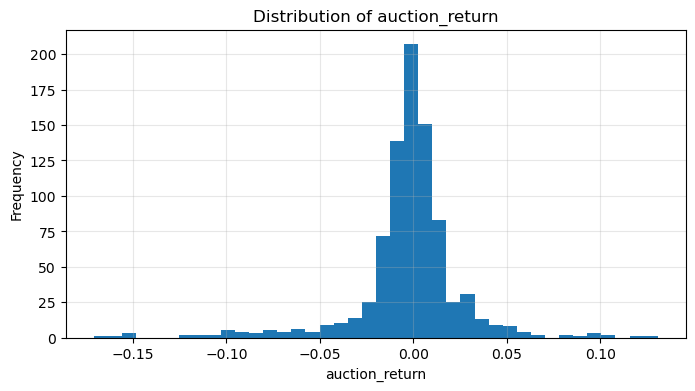

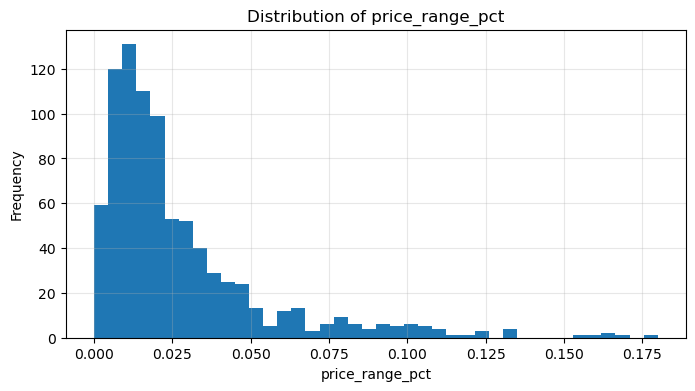

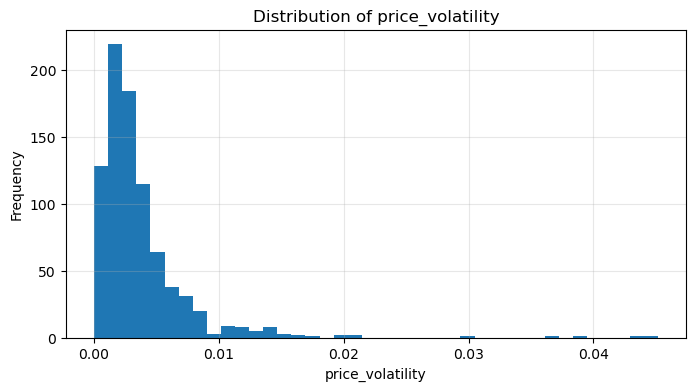

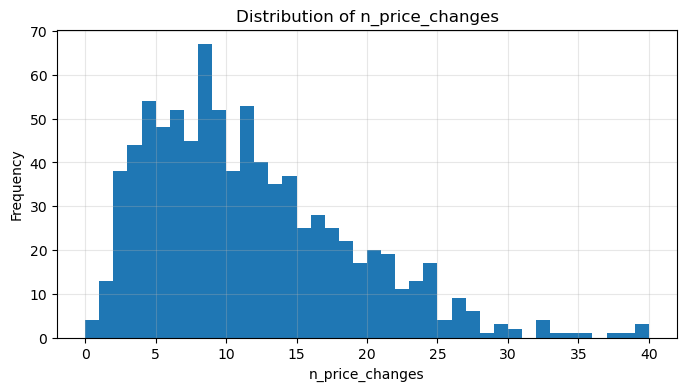

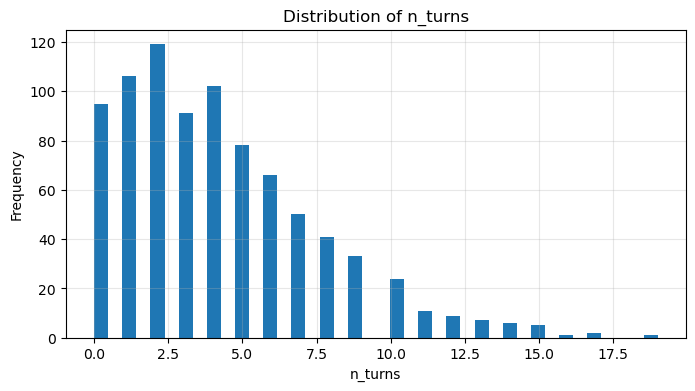

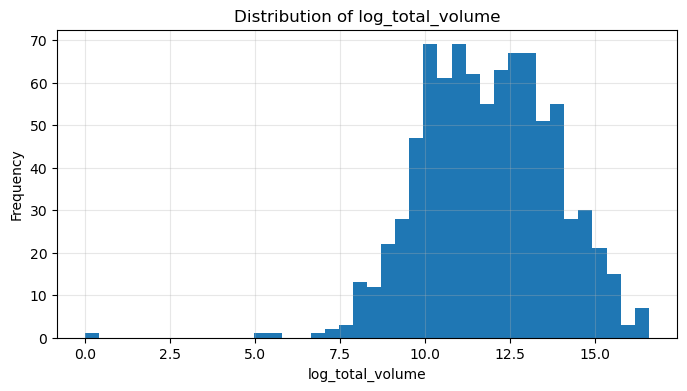

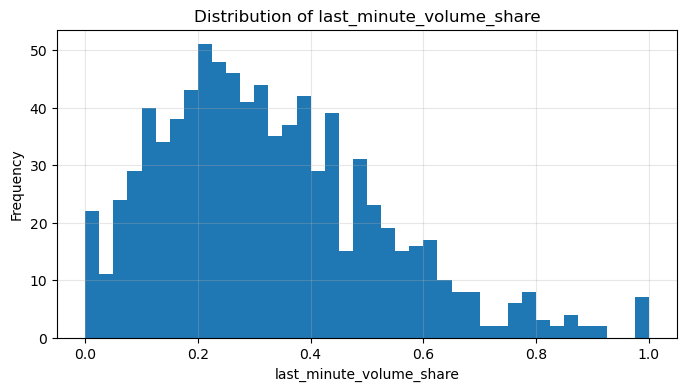

In [ ]:
validation_features = [
    "auction_return",
    "price_range_pct",
    "price_volatility",
    "n_price_changes",
    "n_turns",
    "total_volume",
    "last_minute_volume_share"
]

feature_valid = feature_long.copy()

# log volume because volume is usually highly skewed
feature_valid["log_total_volume"] = np.log1p(feature_valid["total_volume"])

dist_features = [
    "auction_return",
    "price_range_pct",
    "price_volatility",
    "n_price_changes",
    "n_turns",
    "log_total_volume",
    "last_minute_volume_share"
]

for col in dist_features:
    plt.figure(figsize=(8, 4))
    plt.hist(feature_valid[col].dropna(), bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()